In [63]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
from qutip import *
# import rydsim
from math import * 
import pandas as pd 
from tqdm import tqdm 
from scipy import integrate 
import scipy.constants 
from scipy.constants import Planck,epsilon_0,Boltzmann
from scipy.optimize import curve_fit
import matplotlib.ticker as ticker
# Define path to ARC root directory (for loading data)
import sys, os
# rootDir = 'd:\\Heidelberg\\Calculation\\Python\\arc_python27_v1_3\\arc\\' # e.g. '/Users/Username/Desktop/ARC-Alkali-Rydberg-Calculator'
# sys.path.append(rootDir)
# os.chdir(rootDir)

from arc import *                 #Import ARC (Alkali Rydberg Calculator)
atom = Rubidium85()


In [2]:
# States 2-photon, 32D5/2
[n1,l1,j1,mj1] = [5,0,0.5,0.5]  # 5S1/2, mj=1/2
[n2,l2,j2,mj2] = [5,1,1.5,0.5]  # 5P3/2, mj=1/2
[n3,l3,j3,mj3] = [32,0,0.5,0.5]  # 32S1/2, mj=1/2
[n4,l4,j4,mj4] = [32,1,1.5,0.5]  # 32P3/2, mj=1/2

# Beam power (W)
power12 = 10.e-9 # 10nW
power23 = 60.e-3 # 60mW
power34 = 10e-3 # 10mW

# Beam waist (m)
waist12 = (150.e-6)/2  
waist23 = (150.e-6)/2
waist34 = 0.02

# Transition wavelength (m)
lambda12 = atom.getTransitionWavelength(n1,l1,j1,n2,l2,j2) # 780-nm laser
lambda23 = atom.getTransitionWavelength(n2,l2,j2,n3,l3,j3) # 480-nm laser
lambda34 = atom.getTransitionWavelength(n3,l3,j3,n4,l4,j4) # RF

# Transition frequency (Hz)
freq12 = atom.getTransitionFrequency(n1,l1,j1,n2,l2,j2) # 780-nm laser
freq23 = atom.getTransitionFrequency(n2,l2,j2,n3,l3,j3) # 480-nm laser
freq34 = atom.getTransitionFrequency(n3,l3,j3,n4,l4,j4) # RF

# Dipole moment matrix element
q=0 # linear polarization
dipmat12 = atom.getDipoleMatrixElement(n1,l1,j1,mj1,n2,l2,j2,mj2,q)
dipmat23 = atom.getDipoleMatrixElement(n2,l2,j2,mj2,n3,l3,j3,mj3,q)
dipmat34 = atom.getDipoleMatrixElement(n3,l3,j3,mj3,n4,l4,j4,mj4,q)

# Transition detuning (Hz)
delta12 = 0
delta23 = 0
delta34 = 0

# Rabi Frequency (2pi is already included)
rabi12 = atom.getRabiFrequency(n1,l1,j1,mj1,n2,l2,j2,q,power12,waist12)/(2*pi)*1e-6 # unit of 2pi MHz
rabi23 = atom.getRabiFrequency(n2,l2,j2,mj2,n3,l3,j3,q,power23,waist23)/(2*pi)*1e-6 # unit of 2pi MHz
rabi34 = atom.getRabiFrequency(n3,l3,j3,mj2,n4,l4,j4,q,power34,waist34)/(2*pi)*1e-6 # unit of 2pi MHz

In [3]:
debug = 1
temperature = 300 # Room temperature: 300 Kelvin

n = [0 for i in range(4)]
l = [0 for i in range(4)]
j = [0 for i in range(4)]
mj = [0 for i in range(4)]
[n[0],l[0],j[0],mj[0]] = [5,0,0.5,0.5]  # 5S1/2, mj=1/2
[n[1],l[1],j[1],mj[1]] = [5,1,1.5,0.5]  # 5P3/2, mj=1/2
[n[2],l[2],j[2],mj[2]] = [32,0,0.5,0.5]  # 32S1/2, mj=1/2
[n[3],l[3],j[3],mj[3]] = [32,1,1.5,0.5]  # 32P3/2, mj=1/2

# Beam power (W)
power = [10.e-9,60.e-3,10e-3]

# Beam waist (m)
waist=[(150.e-6)/2,(150.e-6)/2,0.025]

# Wavelength (m)
lambda_trans = [atom.getTransitionWavelength(n[i],l[i],j[i],n[i+1],l[i+1],j[i+1]) for i in range(len(n)-1)]
if debug: print('Wavelength (m)',lambda_trans)

# Rabi Frequency (Hz)
Rabifreq = [atom.getRabiFrequency(n[i],l[i],j[i],mj[i],n[i+1],l[i+1],j[i+1],q,power[i],waist[i])/(2*pi) for i in range(len(n)-1)]
if debug: print('Rabi Frequency (Hz)',Rabifreq)

# Decay rate (Hz)
Gamma =[0]+ [1/atom.getStateLifetime(n[i],l[i],j[i],temperature=temperature,includeLevelsUpTo=n[i]+10)/(2*pi) for i in range(1,len(n))]
if debug: print('Gamma (Hz): ',Gamma)

# Different in transition frequency comparing to ground state (Hz)
def Hdiag(n,l,j):
    Estate = []
    statelist = []
    for i in range(len(n)):
        transition = atom.getTransitionFrequency(n[0],l[0],j[0],n[i],l[i],j[i])*2*pi        
        statelist.append([n[i],l[i],j[i]])
        Estate.append(transition)    
    nstate = len(Estate)
    Hstate = np.diag(Estate)
    return nstate, statelist, Hstate
if debug: print(Hdiag(n,l,j)[2])

Wavelength (m) [np.float64(7.802414762021273e-07), np.float64(4.82100139311448e-07), 0.002297133888579615]
Rabi Frequency (Hz) [np.float64(911940.821030698), np.float64(12574646.13352145), np.float64(509420590.15879244)]
Gamma (Hz):  [0, np.float64(6065897.833796889), np.float64(8520.89541325387), np.float64(5370.247723464842)]
[[0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00]
 [0.00000000e+00 2.41419051e+15 0.00000000e+00 0.00000000e+00]
 [0.00000000e+00 0.00000000e+00 6.32136957e+15 0.00000000e+00]
 [0.00000000e+00 0.00000000e+00 0.00000000e+00 6.32218957e+15]]


In [4]:
# Define the levels and atomic projection operators
one, two, three, four = [basis(4,i) for i in range(4)]

In [5]:
# Define the levels and atomic projection operators
sig_11 = one * one.dag()
sig_22 = two * two.dag()
sig_33 = three * three.dag() 
sig_44 = four * four.dag() 
sig_12 = one * two.dag()  
sig_13 = one * three.dag() 
sig_14 = one * four.dag() 
sig_23 = two * three.dag()  
sig_24 = two * four.dag()
sig_34 = three * four.dag()

In [6]:
gamma_diag = np.diag(Gamma);gamma_diag

array([[0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
       [0.00000000e+00, 6.06589783e+06, 0.00000000e+00, 0.00000000e+00],
       [0.00000000e+00, 0.00000000e+00, 8.52089541e+03, 0.00000000e+00],
       [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 5.37024772e+03]])

In [7]:
#define number of state 
n_state = int(4) 
gamma_off = [[0.5*(gamma_diag[i][i]+gamma_diag[j][j]) if i != j else 0 for j in range(n_state)] for i in range(n_state)];gamma_off

[[0,
  np.float64(3032948.9168984443),
  np.float64(4260.447706626935),
  np.float64(2685.123861732421)],
 [np.float64(3032948.9168984443),
  0,
  np.float64(3037209.364605071),
  np.float64(3035634.0407601767)],
 [np.float64(4260.447706626935),
  np.float64(3037209.364605071),
  0,
  np.float64(6945.571568359355)],
 [np.float64(2685.123861732421),
  np.float64(3035634.0407601767),
  np.float64(6945.571568359355),
  0]]

In [8]:
gamma = (gamma_diag+gamma_off)*2*pi ;gamma

array([[0.00000000e+00, 1.90565801e+07, 2.67691824e+04, 1.68711308e+04],
       [1.90565801e+07, 3.81131601e+07, 1.90833493e+07, 1.90734512e+07],
       [2.67691824e+04, 1.90833493e+07, 5.35383649e+04, 4.36403132e+04],
       [1.68711308e+04, 1.90734512e+07, 4.36403132e+04, 3.37422616e+04]])

In [9]:
#collapse operators 
c_12 = -np.sqrt(gamma[0][1])*sig_12 # 1-2 coherence decay  
#c_21 = -np.sqrt(gamma[0][1])*sig_21
c_13 = -np.sqrt(gamma[0][2])*sig_13 # 1-3 coherence decay  
#c_31 = -np.sqrt(gamma[0][2])*sig_31 # 1-3 coherence decay  
c_14 = -np.sqrt(gamma[0][3])*sig_14  # 1-4 coherence decay  
#c_41 = -np.sqrt(gamma[0][3])*sig_41  # 1-4 coherence decay   
c_23 = -np.sqrt(gamma[1][2])*sig_23 # 2-3 coherence decay 
#c_32 = -np.sqrt(gamma[1][2])*sig_32 # 2-3 coherence decay 
c_24 = -np.sqrt(gamma[1][3])*sig_24  # 2-4 coherence decay  
#c_42 = -np.sqrt(gamma[1][3])*sig_42  # 2-4 coherence decay  
c_34 = -np.sqrt(gamma[2][3])*sig_34  
#c_43 = -np.sqrt(gamma[2][3])*sig_43
#transitions decay rate  
c_11 = np.sqrt(gamma[1][1])*sig_22
c_22 = np.sqrt(gamma[2][2])*sig_33 -  np.sqrt(gamma[1][1])*sig_22
c_33 = np.sqrt(gamma[3][3])*sig_44 -  np.sqrt(gamma[2][2])*sig_33
c_44 = -np.sqrt(gamma[3][3])*sig_44 
#check define collapse operator
collapse = [c_11,c_22,c_33,c_44,c_12,c_13,c_14,c_23,c_24,c_34]

In [10]:
tlist = np.linspace(0, 50, 500)

In [11]:
debug = 1
temperature = 300 # Room temperature: 300 Kelvin
# Define bases for the n-level system
nlevel = 4
psi = [basis(nlevel,i) for i in range(nlevel)]
rho = [[psi[j]*psi[i].dag() for i in range(nlevel)] for j in range(nlevel)]
if debug: print(rho[1][2])

# Decay rate Gamma (Hz)
Gamma =[0]+ [1/atom.getStateLifetime(n[i],l[i],j[i],temperature=temperature,includeLevelsUpTo=n[i]+10)/(2*pi) for i in range(1,nlevel)]
if debug: print('Gamma (Hz): ',Gamma)

# Relaxation rate gamma (Hz)
gamma = np.array([[(Gamma[i]+Gamma[j])/2 for i in range(nlevel)] for j in range(nlevel)])
if debug: print('gamma (Hz): \n',gamma)

Quantum object: dims=[[4], [4]], shape=(4, 4), type='oper', dtype=Dense, isherm=False
Qobj data =
[[0. 0. 0. 0.]
 [0. 0. 1. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]]
Gamma (Hz):  [0, np.float64(6065897.833796889), np.float64(8520.89541325387), np.float64(5370.247723464842)]
gamma (Hz): 
 [[0.00000000e+00 3.03294892e+06 4.26044771e+03 2.68512386e+03]
 [3.03294892e+06 6.06589783e+06 3.03720936e+06 3.03563404e+06]
 [4.26044771e+03 3.03720936e+06 8.52089541e+03 6.94557157e+03]
 [2.68512386e+03 3.03563404e+06 6.94557157e+03 5.37024772e+03]]


In [12]:
# collapse operator
c_op_list = []

# Diagonal term: add square root for Gamma
for i in range(nlevel):
    if i<nlevel-1:
        c_op_list.append(np.sqrt(Gamma[i+1])*rho[i+1][i+1]-np.sqrt(Gamma[i])*rho[i][i])
    else:
        c_op_list.append(-np.sqrt(Gamma[i])*rho[i][i])
    
# Off-diagonal term: add square root for Gamma
for i in range(nlevel):
    for j in range(i,nlevel):
        if j!=i:
            c_op_list.append(-np.sqrt(gamma[i][j])*rho[i][j])
            # print(i,j,-gamma[i][j]*rho[i][j])

# if debug: print(c_op_list[1])
print(len(c_op_list))
# print(c_op_list)

10


In [13]:
debug = 1
temperature = 300 # Room temperature: 300 Kelvin

n = [0 for i in range(4)]
l = [0 for i in range(4)]
j = [0 for i in range(4)]
mj = [0 for i in range(4)]
[n[0],l[0],j[0],mj[0]] = [5,0,0.5,0.5]  # 5S1/2, mj=1/2
[n[1],l[1],j[1],mj[1]] = [5,1,1.5,0.5]  # 5P3/2, mj=1/2
[n[2],l[2],j[2],mj[2]] = [32,0,0.5,0.5]  # 32S1/2, mj=1/2
[n[3],l[3],j[3],mj[3]] = [32,1,1.5,0.5]  # 32P3/2, mj=1/2

# Beam power (W)
power = [10.e-9,60.e-3,10e-3]

# Beam waist (m)
waist=[(150.e-6)/2,(150.e-6)/2,0.025]

# Wavelength (m)
Lambda = [atom.getTransitionWavelength(n[i],l[i],j[i],n[i+1],l[i+1],j[i+1]) for i in range(len(n)-1)]
if debug: print('Wavelength (m)',Lambda)

# Rabi Frequency (Hz)
q = 0 # light polarization: 0: linear, 1: sigma+, -1: sigma-
Rabifreq = [atom.getRabiFrequency(n[i],l[i],j[i],mj[i],n[i+1],l[i+1],j[i+1],q,power[i],waist[i])/(2*pi) for i in range(len(n)-1)]
if debug: print('Rabi Frequency (Hz)',Rabifreq)

# Decay rate (Hz)
Gamma =[0]+ [1/atom.getStateLifetime(n[i],l[i],j[i],temperature=temperature,includeLevelsUpTo=n[i]+10)/(2*pi) for i in range(1,len(n))]
if debug: print('Gamma (Hz): ',Gamma)

delta = [0 for i in range(len(n)-1)]
if debug: print('Detuning (Hz):', delta)
# def detuning(delta,dp,dd,dc,dRF,kp,kd,kc,kRF,v):
#     delta[0] = 0
#     delta[1] = dp - kp*v
#     delta[2] = dd - kd*v
#     delta[3] = dRF - kRF*v
#     delta[4] = dRF - kRF*v
#     return delta


# Define bases for the n-level system
nlevel = 4
psi = [basis(nlevel,i) for i in range(nlevel)]
rho = [[psi[j]*psi[i].dag() for i in range(nlevel)] for j in range(nlevel)]
if debug: print(rho[1][2])

# Decay rate Gamma (Hz)
Gamma =[0]+ [1/atom.getStateLifetime(n[i],l[i],j[i],temperature=temperature,includeLevelsUpTo=n[i]+10)/(2*pi) for i in range(1,nlevel)]
if debug: print('Gamma (Hz): ',Gamma)

# Relaxation rate gamma (Hz)
gamma = np.array([[(Gamma[i]+Gamma[j])/2 for i in range(nlevel)] for j in range(nlevel)])
if debug: print('gamma (Hz): \n',gamma)

# collapse operator
c_op_list = []

# Diagonal term: add square root for Gamma
for i in range(nlevel):
    if i<nlevel-1:
        c_op_list.append(np.sqrt(Gamma[i+1])*rho[i+1][i+1]-np.sqrt(Gamma[i])*rho[i][i])
    else:
        c_op_list.append(-np.sqrt(Gamma[i])*rho[i][i])
    
# Off-diagonal term: add square root for Gamma
for i in range(nlevel):
    for j in range(i,nlevel):
        if j!=i:
            c_op_list.append(-np.sqrt(gamma[i][j])*rho[i][j])
            # print(i,j,-gamma[i][j]*rho[i][j])

# if debug: print(c_op_list[1])
print(len(c_op_list))
# print(c_op_list)



# Hamiltonian (Hz): Field interaction picture, take only detuning
def Hdiag(delta):
    detuning = 0
    Estate = [0]
    for i in range(len(n)-1):   
        detuning += -delta[i]     
        Estate.append(detuning*2)        
    # nstate = len(Estate)
    Hstate = np.diag(Estate)
    return Hstate
if debug: print('Hdiag:\n', Hdiag(delta))    

def Hoff(Rabifreq):
    Hrabiu = np.array([[0]+[Rabifreq[i] if j-i == 1 else 0 for i in range(len(Rabifreq))] for j in range(len(Rabifreq)+1)][1:] + [[0 for i in range(len(Rabifreq)+1)]])
    Hrabid = Hrabiu.T
    Hrabi = Hrabiu + Hrabid 
    return Hrabi
if debug: print('Hoffdiag: \n', Hoff(Rabifreq))

H = Hdiag(delta) + Hoff(Rabifreq)
# # def Linblad(Gamma)

# nstate, statelist, Hstate = Hdiag(n,l,j)

# a  = qt.tensor(qt.qeye(3), qt.destroy(2))
print('H total: \n', H)

Wavelength (m) [np.float64(7.802414762021273e-07), np.float64(4.82100139311448e-07), 0.002297133888579615]
Rabi Frequency (Hz) [np.float64(911940.821030698), np.float64(12574646.13352145), np.float64(509420590.15879244)]
Gamma (Hz):  [0, np.float64(6065897.833796889), np.float64(8520.89541325387), np.float64(5370.247723464842)]
Detuning (Hz): [0, 0, 0]
Quantum object: dims=[[4], [4]], shape=(4, 4), type='oper', dtype=Dense, isherm=False
Qobj data =
[[0. 0. 0. 0.]
 [0. 0. 1. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]]
Gamma (Hz):  [0, np.float64(6065897.833796889), np.float64(8520.89541325387), np.float64(5370.247723464842)]
gamma (Hz): 
 [[0.00000000e+00 3.03294892e+06 4.26044771e+03 2.68512386e+03]
 [3.03294892e+06 6.06589783e+06 3.03720936e+06 3.03563404e+06]
 [4.26044771e+03 3.03720936e+06 8.52089541e+03 6.94557157e+03]
 [2.68512386e+03 3.03563404e+06 6.94557157e+03 5.37024772e+03]]
10
Hdiag:
 [[0 0 0 0]
 [0 0 0 0]
 [0 0 0 0]
 [0 0 0 0]]
Hoffdiag: 
 [[0.00000000e+00 9.11940821e+05 0.00000000

In [14]:
debug = 1

# Calculate pressure
def pressure_Rb85(temperature):
    # Pressure of Rb85 in a vapor cell
    # Input temperature in Kelvin
    meltingpoint = 39.30 + 273.15
    if temperature <= meltingpoint:
        pressure = 10**(2.881+4.857-4215/temperature)
    else:
        pressure = 10**(2.881+4.312-4040/temperature)
    pressure = pressure*133.322 #Change from torr to Pascal
    return pressure
if debug: 
    print('Pressure from Steck @ 300K (Pa): ', pressure_Rb85(300))
    print('Pressure from Steck @ 350K (Pa): ', pressure_Rb85(350))
    print('Pressure from Holloway @ 300K (Pa): ',10**(5.006+4.857-4215/300))

# Calculate total density of atoms
def atomdensity(pressure, temperature):
    # Input temperature in Kelvin, pressure in Pa
    kB = 1.380649e-23 # J/K
    return 0.7217*pressure/kB/temperature
if debug: print('Atom density @ 300K, same pressure (atoms/m3)', atomdensity(6.49982733575635e-05, 300))
if debug: print('Atom density @ 350K, same pressure (atoms/m3)', atomdensity(pressure_Rb85(350), 350))

# Calculate electric field from Rabi frequency
def E_from_Rabi(rabifreq,dipmat):
    # Input Rabifreq in MHz, dipmat in ea0
    ea0 = 8.4783536255e-30 # C.m
    hbar = 1.054571817e-34 # J.s
    return rabifreq*hbar/(dipmat*ea0)
if debug: print('E from Rabifreq (V/m): ', E_from_Rabi(1e6,2.44063075))

# Calculate susceptibility \chi
def susceptibility(atomdensity,dipmat,Efield,rho12):
    # Input Rabifreq in MHz, dipmat in ea0
    ea0 = 8.4783536255e-30 # C.m
    epsilon0 = 8.8541878128e-12 # F/m  
    if Efield == 0: res = 1e99 #give large value
    else: res = 2*atomdensity*(dipmat*ea0)*rho12/Efield/epsilon0
    return res
if debug: print('chi from E :',susceptibility(atomdensity(6.49982733575635e-05, 300),2.44063075,E_from_Rabi(1e6,2.44063075),0.12309365719942876))
if debug: print('chi when E=0 :',susceptibility(atomdensity(6.49982733575635e-05, 300),2.44063075,E_from_Rabi(0,2.44063075),0.12309365719942876))

# Transmission P/P0
def transmission(L,chi_imag,lambda12):
    # from Beer's law, alpha should be  around 10 m-1, transmission is around 0.8
    # chi should be in the order of 1e-5 to 1e-8
    return np.exp(-2*pi*L*chi_imag/lambda12)
if debug: print('Transmission (P/P0):', transmission(7.5e-2,1e-5,780e-9))
if debug: print('Transmission (P/P0):', transmission(7.5e-2,1e99,780e-9))

def absorption_coeff_0(atomdensity,dipmat,lambda12,gamma2):
    # From Berman's book, eq. 4.23
    # gamma2 is spontaneous emission
    ea0 = 8.4783536255e-30 # C.m
    epsilon0 = 8.8541878128e-12 # F/m  
    hbar = 1.054571817e-34 # J.s
    speed_of_light = 299792458 # m/s
    a0 =  2*atomdensity*(dipmat*ea0)**2/hbar/epsilon0/gamma2
    # return a0* gamma2/2 *freq/(speed_of_light/lambda12) * gamma/(gammaB**2+delta**2)
    return a0

if debug: print('absorption coefficient',absorption_coeff_0(1e16,2.44063075,780e-9,6e6))

print(np.exp(-7.5e-2*absorption_coeff_0(1e16,2.44063075,780e-9,6e6)))

Pressure from Steck @ 300K (Pa):  6.49982733575635e-05
Pressure from Steck @ 350K (Pa):  0.0059572342419839325
Pressure from Holloway @ 300K (Pa):  6.50129690343089e-05
Atom density @ 300K, same pressure (atoms/m3) 1.1325411426595652e+16
Atom density @ 350K, same pressure (atoms/m3) 8.897132440591974e+17
E from Rabifreq (V/m):  5.096388832415705
chi from E : 0.001278562547981584
chi when E=0 : 1e+99
Transmission (P/P0): 0.0023779313882871726
Transmission (P/P0): 0.0
absorption coefficient 0.001528554983971162
0.999885364947302


In [15]:
area = np.pi*(1.27e-2)**2
length = 7.8e-2
volume = area*length

print('volume (m3):', volume)
print('Atom ')

volume (m3): 3.952318336960482e-05
Atom 


In [29]:
import numpy as np
from scipy import signal
import matplotlib.pyplot as plt
t = np.linspace(0, 9E-6, 2000, endpoint=False)
plt.plot(t,1-signal.square(2*pi*0.45*0.4E6 * t, duty=0.7))
#plt.ylim(-2, 2)

In [17]:
def H1_coeff(tlist, args):
    return 23*1e6*(1-signal.square(2*pi*0.45*0.5E6 * tlist , duty=0.5)) 
    #return 9*1e6

In [18]:
tlist = np.linspace(0.0, 0.000003, 1000)
#print(tlist)
L=7.5e-2 # Cell length

psi0=basis(4,0)

pressure = pressure_Rb85(temperature)
N_0 = atomdensity(pressure, temperature)
dp = np.linspace(-100.e6, 100.e6, 201)
dc = np.linspace(-200.e6, 200.e6, 201)
dp = np.array([0])
# print(dp)
rabi12 = 1e6
rabi23 = 100e6

rabi34 = 0

delta12=0
delta23=0
delta34=0

Rabi12 = np.linspace(0, 50.e6, 6)
Rabi23 = np.linspace(0, 100.e6, 5)
Rabi34 = np.linspace(0, 20.e6, 5)

fig, ax = plt.subplots()
for rabi12 in Rabi12:
# for rabi23 in Rabi23:
# for rabi34 in Rabi34:
    Rabifreq = [rabi12,rabi23,rabi34]
    #print(Rabifreq)
    res = []
    for delta12 in dp:
    # for delta23 in dc:    
        delta = [delta12,delta23,delta34]
        H0 = 1/2*Qobj(Hdiag(delta) + Hoff(Rabifreq))  
        H1 = (rho[2][3].dag() + rho[2][3])
        H = [H0,[H1,H1_coeff]] 
        print(H)
        
        # result = steadystate(H, c_op_list)
        result = mesolve(H, psi0, tlist, c_op_list,rho[0][1].dag())
        
        res.append(result.expect)
    # print(H)   
    # print(c_op_list)
    # print(rabi34)
    # print(res)
    # print(np.imag(res))
    Efield = E_from_Rabi(rabi12,abs(dipmat12))
    # print()
    # chi = [susceptibility(N_0,np.abs(dipmat12),Efield,rho) for rho in res]

    # # print(np.imag(chi))
    # transmittance = [transmission(L,np.imag(i),lambda12) for i in chi]
    # refraction = np.real(chi)
    # absorption = 2*pi*np.imag(chi)/lambda12
    # print(np.imag(chi)[0])
    # # print(absorption)
    # # ax.plot(dp, res) 
    # # ax.plot(dp,res, label=omegaRF*1e-6)
    # # ax.plot(dp,transmission, label=rabi34*1e-6)
    # # ax.plot(dp,transmission, label=rabi12*1e-6)
    # # ax.plot(dp,transmittance, label=str(round(rabi12*1e-6,0))+'MHz')

    # # ax.plot(dp,refraction, label=rabi23*1e-6)
    ax.plot(tlist,np.imag(res[0][0]), label=str(round(rabi12*1e-6,0))+'MHz') # for rho[0][1]
    # ax.plot(tlist,np.real(res[0][0]), label=str(round(rabi12*1e-6,0))+'MHz') # for rho[0][0]
    #print(res)

    # ax.plot(times, result.expect[1]) 
ax.set_xlabel('Time (s)') 
ax.set_ylabel('Im[$\chi$]') 
# ax.legend(("Sigma-Z", "Sigma-Y"))  
ax.legend()
# plt.suptitle('EIT, vary $\Omega_{RF}$')
plt.suptitle('EIT, vary $\Omega_{p}$')
# plt.ylim(-0.0007,-0.0006)
plt.show()
#print(H) 
#print(Rabifreq)
#print(delta)
#print(res[0])

<>:73: SyntaxWarning: invalid escape sequence '\c'
<>:77: SyntaxWarning: invalid escape sequence '\O'
<>:73: SyntaxWarning: invalid escape sequence '\c'
<>:77: SyntaxWarning: invalid escape sequence '\O'
C:\Users\beam_\AppData\Local\Temp\ipykernel_33468\1007911131.py:73: SyntaxWarning: invalid escape sequence '\c'
  ax.set_ylabel('Im[$\chi$]')
C:\Users\beam_\AppData\Local\Temp\ipykernel_33468\1007911131.py:77: SyntaxWarning: invalid escape sequence '\O'
  plt.suptitle('EIT, vary $\Omega_{p}$')


[Quantum object: dims=[[4], [4]], shape=(4, 4), type='oper', dtype=Dense, isherm=True
Qobj data =
[[       0.        0.        0.        0.]
 [       0.        0. 50000000.        0.]
 [       0. 50000000.        0.        0.]
 [       0.        0.        0.        0.]], [Quantum object: dims=[[4], [4]], shape=(4, 4), type='oper', dtype=Dense, isherm=True
Qobj data =
[[0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 1.]
 [0. 0. 1. 0.]], <function H1_coeff at 0x00000269B99E1BC0>]]


C:\Users\beam_\AppData\Local\Temp\ipykernel_33468\1007911131.py:73: SyntaxWarning: invalid escape sequence '\c'
  ax.set_ylabel('Im[$\chi$]')
C:\Users\beam_\AppData\Local\Temp\ipykernel_33468\1007911131.py:77: SyntaxWarning: invalid escape sequence '\O'
  plt.suptitle('EIT, vary $\Omega_{p}$')


TypeError: H1_coeff() missing 1 required positional argument: 'args'

# Time depentdent

In [30]:
tlist = np.linspace(0.0, 6E-6 , 2000)

In [20]:
#use one of this
def H1_coeff(tlist, args):
    return 23*1e6*(1-signal.square(2*pi*0.45*0.5E6 * tlist , duty=0.5)) 
    #return 9*1e6

In [31]:
def H1_coeff(tlist, args): 
    A = args['A'] 
    R = args['R']
    return A*(1-signal.square(2*pi*0.45*0.5E6 * tlist , duty=R)) 

<>:59: SyntaxWarning: invalid escape sequence '\c'
<>:63: SyntaxWarning: invalid escape sequence '\O'
<>:59: SyntaxWarning: invalid escape sequence '\c'
<>:63: SyntaxWarning: invalid escape sequence '\O'
C:\Users\beam_\AppData\Local\Temp\ipykernel_33468\3861359470.py:59: SyntaxWarning: invalid escape sequence '\c'
  ax.set_ylabel('Im[$\chi$]')
C:\Users\beam_\AppData\Local\Temp\ipykernel_33468\3861359470.py:63: SyntaxWarning: invalid escape sequence '\O'
  plt.suptitle('EIT, vary $\Omega_{p}$')


[Quantum object: dims=[[4], [4]], shape=(4, 4), type='oper', dtype=Dense, isherm=True
Qobj data =
[[0.0e+00 2.5e+05 0.0e+00 0.0e+00]
 [2.5e+05 0.0e+00 5.0e+06 0.0e+00]
 [0.0e+00 5.0e+06 2.0e+08 0.0e+00]
 [0.0e+00 0.0e+00 0.0e+00 2.0e+08]], [Quantum object: dims=[[4], [4]], shape=(4, 4), type='oper', dtype=Dense, isherm=True
Qobj data =
[[0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 1.]
 [0. 0. 1. 0.]], <function <lambda> at 0x00000269BB3F1BC0>]]
[0.00000000e+00+0.j         4.29654563e-09+0.00074186j
 6.34530338e-08+0.00146689j ... 5.37444016e-04+0.03260319j
 5.37400218e-04+0.03260321j 5.37348906e-04+0.03260321j]
[Quantum object: dims=[[4], [4]], shape=(4, 4), type='oper', dtype=Dense, isherm=True
Qobj data =
[[0.00e+00 2.50e+05 0.00e+00 0.00e+00]
 [2.50e+05 0.00e+00 5.00e+06 0.00e+00]
 [0.00e+00 5.00e+06 1.98e+08 0.00e+00]
 [0.00e+00 0.00e+00 0.00e+00 1.98e+08]], [Quantum object: dims=[[4], [4]], shape=(4, 4), type='oper', dtype=Dense, isherm=True
Qobj data =
[[0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [

e:\anaconda\envs\qutopV2_environment\Lib\site-packages\matplotlib\cbook.py:1762: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
e:\anaconda\envs\qutopV2_environment\Lib\site-packages\matplotlib\cbook.py:1398: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


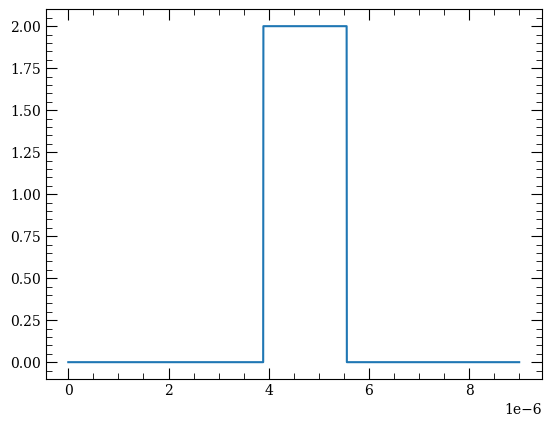

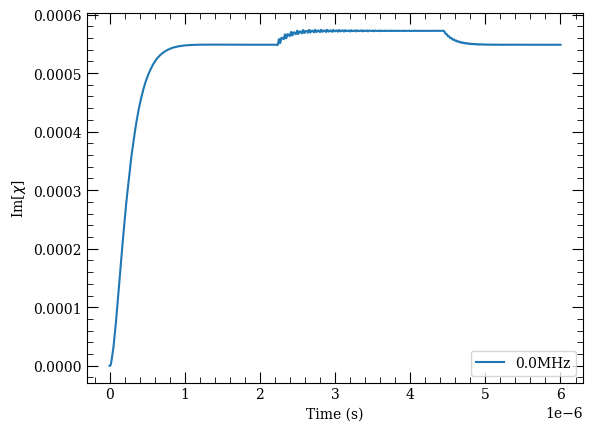

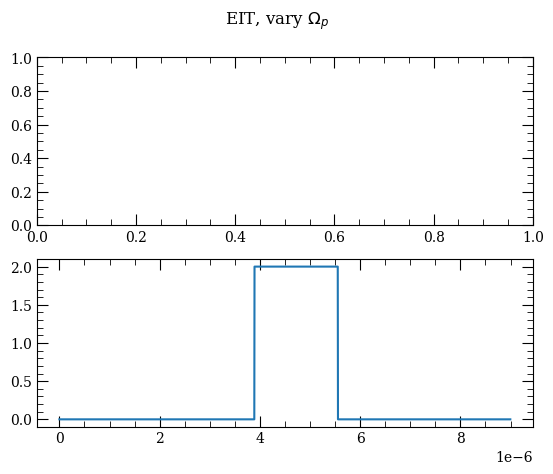

In [35]:
def H1_coeff(tlist, args): 
    A = args['A'] 
    R = args['R']
    return A*(1-signal.square(2*pi*0.45*0.5E6 * tlist , duty=R)) 


rabi12 = 0.5e6 
rabi23 = 10e6 
rabi34 = 0 
rabi34_value = 20e6 
dp = np.linspace(-100.e6, 100.e6, 201)
dc = np.linspace(-200.e6, 200.e6, 201)
# for rabi23 in Rabi23:
# for rabi34 in Rabi34:
Rabifreq = [rabi12,rabi23,rabi34]
    #print(Rabifreq)
res_split = [] 
chi_list = []
    #for delta12 in dp:
for delta23 in dc:    
    delta = [delta12,delta23,delta34]
    H0 = 1/2*Qobj(Hdiag(delta) + Hoff(Rabifreq))  
    H1 = (rho[2][3].dag() + rho[2][3])
    #H = [H0,[H1,H1_coeff]]  
    H = [H0, [H1, lambda t, args: H1_coeff(t, args)]]
    print(H)
        
    # result = steadystate(H, c_op_list)
    result = mesolve(H, psi0, tlist, c_op_list,rho[0][1].dag(),args={'A': rabi34_value ,'R':0.50})
        
    res_split.append(result.expect)
    # print(H)   
    # print(c_op_list)
    # print(rabi34)
    print(res_split[0][0])
    # print(np.imag(res))
    Efield = E_from_Rabi(rabi12,abs(dipmat12))
    # print()
    #chi = [susceptibility(N_0,np.abs(dipmat12),Efield,rho) for rho in res[0]]
    # # print(np.imag(chi))
    # transmittance = [transmission(L,np.imag(i),lambda12) for i in chi]
    # refraction = np.real(chi)
    # absorption = 2*pi*np.imag(chi)/lambda12
    # print(np.imag(chi)[0])
    # # print(absorption)
    # # ax.plot(dp, res) 
    # # ax.plot(dp,res, label=omegaRF*1e-6)
    # # ax.plot(dp,transmission, label=rabi34*1e-6)
    # # ax.plot(dp,transmission, label=rabi12*1e-6)
    # # ax.plot(dp,transmittance, label=str(round(rabi12*1e-6,0))+'MHz')

    # # ax.plot(dp,refraction, label=rabi23*1e-6)
ax.plot(tlist,res_split[2][0], label=str(round(rabi12*1e-6,0))+'MHz') # for rho[0][1]
    # ax.plot(tlist,np.real(res[0][0]), label=str(round(rabi12*1e-6,0))+'MHz') # for rho[0][0]
    #print(res)

# ax.plot(times, result.expect[1]) 
ax.set_xlabel('Time (s)') 
ax.set_ylabel('Im[$\chi$]') 
# ax.legend(("Sigma-Z", "Sigma-Y"))  
ax.legend()
# plt.suptitle('EIT, vary $\Omega_{RF}$')
plt.suptitle('EIT, vary $\Omega_{p}$')
# plt.ylim(-0.0007,-0.0006)
plt.show()
#print(H) 
#print(Rabifreq)
#print(delta)
#print(res[0])

In [36]:
Efield = E_from_Rabi(rabi12,abs(dipmat12)) 
chi_list = []
for i in range(len(dc)):  
    chi = [susceptibility(N_0,np.abs(dipmat12),Efield,rho) for rho in res_split[i][0]] 
    chi_list.append(chi)
    plt.plot(np.imag(chi))

In [37]:
fig, axs = plt.subplots(2)
fig.suptitle("32S EIT- Im[$\chi$]"+"-tlist")
axs[0].plot(tlist, -1*np.imag(chi_list[100]))
axs[1].plot(tlist, -1*np.imag(chi_list[88]))

<>:2: SyntaxWarning: invalid escape sequence '\c'
<>:2: SyntaxWarning: invalid escape sequence '\c'
C:\Users\beam_\AppData\Local\Temp\ipykernel_33468\1387449530.py:2: SyntaxWarning: invalid escape sequence '\c'
  fig.suptitle("32S EIT- Im[$\chi$]"+"-tlist")


In [38]:
peak_split =np.array([[chi_list[i][j] for i in range(len(dc))] for j in range(len(tlist)-1,-1,-1)])

In [39]:
print(-1*np.imag(peak_split))

[[-6.77293167e-04 -6.77284287e-04 -6.77281387e-04 ... -6.77281387e-04
  -6.77284287e-04 -6.77293167e-04]
 [-6.77293219e-04 -6.77284160e-04 -6.77281352e-04 ... -6.77281352e-04
  -6.77284160e-04 -6.77293219e-04]
 [-6.77292660e-04 -6.77284590e-04 -6.77280827e-04 ... -6.77280827e-04
  -6.77284590e-04 -6.77292660e-04]
 ...
 [-3.04729080e-05 -3.04729018e-05 -3.04728957e-05 ... -3.04728957e-05
  -3.04729018e-05 -3.04729080e-05]
 [-1.54113019e-05 -1.54113018e-05 -1.54113016e-05 ... -1.54113016e-05
  -1.54113018e-05 -1.54113019e-05]
 [-0.00000000e+00 -0.00000000e+00 -0.00000000e+00 ... -0.00000000e+00
  -0.00000000e+00 -0.00000000e+00]]


In [40]:
np.savetxt("data_rabi12_"+str(rabi12/1e6)+"_rabi23_"+str(rabi23/1e6)+"_rabi34_"+str(rabi34_value/1e6)+".csv", -1*np.imag(peak_split), delimiter=",")

In [41]:
df = pd.DataFrame(-1*np.imag(peak_split))

In [51]:
df.to_csv("data_rabi12_"+str(rabi12/1e6)+"_rabi23_"+str(rabi23/1e6)+"_rabi34_"+str(rabi34_value/1e6)+".csv", index=True)

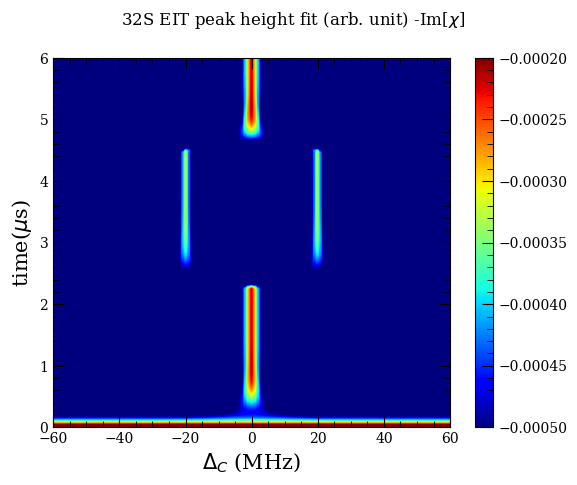

In [70]:
plt.imshow(-1*np.imag(peak_split),vmin=-0.0005,origin='upper', extent=[-100,100,0,tlist[-1]*1e6], vmax=-0.0002, cmap='jet', aspect='auto')  
font1 = {'family':'serif','color':'black','size':20}
font2 = {'family':'serif','color':'black','size':15}
plt.suptitle('32S EIT peak height fit (arb. unit) '+"-Im[$\chi$]", fontdict = font1)
plt.xlabel("$\Delta_C$"+" (MHz)", fontdict = font2) 
plt.xlim(-60,60)
plt.ylabel("time"+"($\mu$s)", fontdict = font2)
plt.colorbar()

In [ ]:
E:\EIT\Time-dependent-EIT\data_rabi12_0.5_rabi23_10.0_rabi34_20.0.csv

In [53]:
data_sim = pd.read_csv('data_rabi12_0.5_rabi23_10.0_rabi34_20.0.csv', sep=',', header=None)

In [54]:

print(df.values)
data_sim_array = np.flip(df.values)
print(data_sim_array.shape) 

[[-6.77293163e-04 -6.77284554e-04 -6.77281508e-04 ... -6.77281508e-04
  -6.77284554e-04 -6.77293163e-04]
 [-6.77293230e-04 -6.77284361e-04 -6.77281448e-04 ... -6.77281448e-04
  -6.77284361e-04 -6.77293230e-04]
 [-6.77292711e-04 -6.77284684e-04 -6.77280890e-04 ... -6.77280890e-04
  -6.77284684e-04 -6.77292711e-04]
 ...
 [-3.04731507e-05 -3.04731444e-05 -3.04731382e-05 ... -3.04731382e-05
  -3.04731444e-05 -3.04731507e-05]
 [-1.54115432e-05 -1.54115430e-05 -1.54115428e-05 ... -1.54115428e-05
  -1.54115430e-05 -1.54115432e-05]
 [-0.00000000e+00 -0.00000000e+00 -0.00000000e+00 ... -0.00000000e+00
  -0.00000000e+00 -0.00000000e+00]]
(2000, 201)


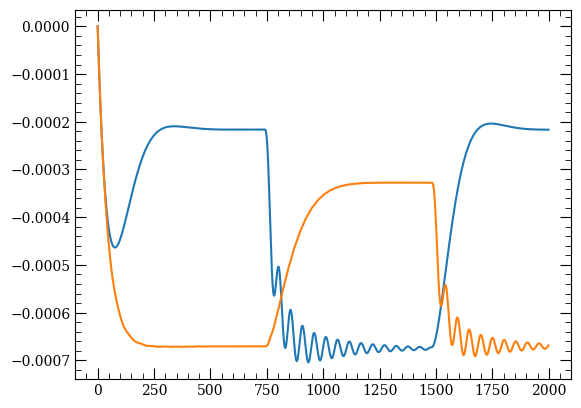

In [58]:
plt.plot(data_sim_array[:,100]) 
plt.plot(data_sim_array[:,120])

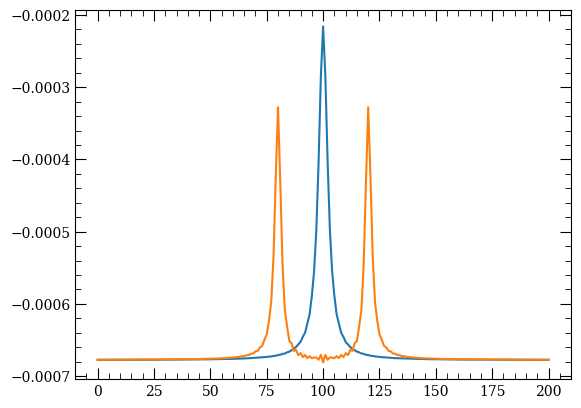

In [62]:
plt.plot(data_sim_array[500,:]) 
plt.plot(data_sim_array[1300,:])

In [22]:
data_sim_high_bandwidth = pd.read_csv('data_rabi12_0.5_rabi23_50.0_rabi34_20.0.csv', sep=',', header=None)

In [23]:
print(data_sim_high_bandwidth.values)
data_sim_array = np.flip(data_sim_high_bandwidth.values)
print(data_sim_array.shape) 

[[            nan  0.00000000e+00  1.00000000e+00 ...  1.98000000e+02
   1.99000000e+02  2.00000000e+02]
 [ 0.00000000e+00 -5.78581187e-04 -5.76889442e-04 ... -5.75135487e-04
  -5.76889442e-04 -5.78581187e-04]
 [ 1.00000000e+00 -5.78566522e-04 -5.76907050e-04 ... -5.75116674e-04
  -5.76907050e-04 -5.78566522e-04]
 ...
 [ 1.99700000e+03 -3.03713735e-05 -3.03712199e-05 ... -3.03710676e-05
  -3.03712199e-05 -3.03713735e-05]
 [ 1.99800000e+03 -1.53979143e-05 -1.53979091e-05 ... -1.53979040e-05
  -1.53979091e-05 -1.53979143e-05]
 [ 1.99900000e+03 -0.00000000e+00 -0.00000000e+00 ... -0.00000000e+00
  -0.00000000e+00 -0.00000000e+00]]
(2001, 202)


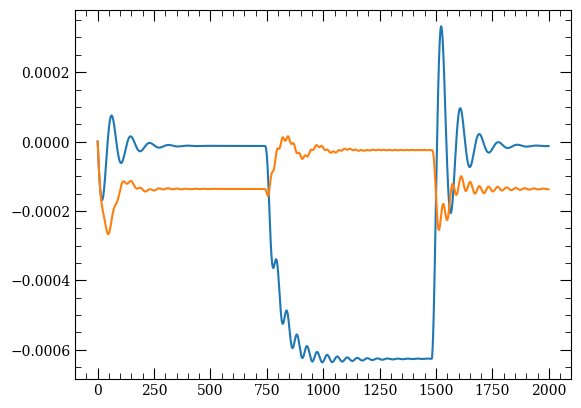

In [146]:
plt.plot(data_sim_array[:,100]) 
plt.plot(data_sim_array[:,120])

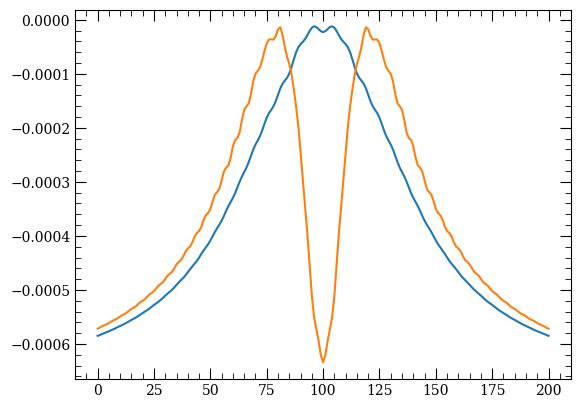

In [147]:
plt.plot(data_sim_array[200,:]) 
plt.plot(data_sim_array[1000,:])

In [171]:
def plot_square(npts=2000):
    """Plot a real sqaure wave

    Parameters
    ----------
    npts : int, optional
      Number of points at which to sample the function.
    """
    # create the square wave
    t, y = square(npts)
    # use the basic plt api
    plt.plot(t, y, label="True Wave")
    plt.grid()
    plt.legend()

    plt.xlabel("t")
    plt.ylabel("y")
    plt.title('True Square Wave')

In [170]:
def square(npts=2000):
    """Create a real square wave.

    Parameters
    ----------
    npts : int, optional
      Number of points at which to sample the function.

    Returns
    -------
    t : array
      The t values where the wave was sampled.
    y : array
      The square wave approximation (the final sum of all terms).
    """

    # get time points
    t = np.linspace(-pi, 2*pi, npts)

    # create the square wave
    y = np.sign(np.sin(t))

    return t, y

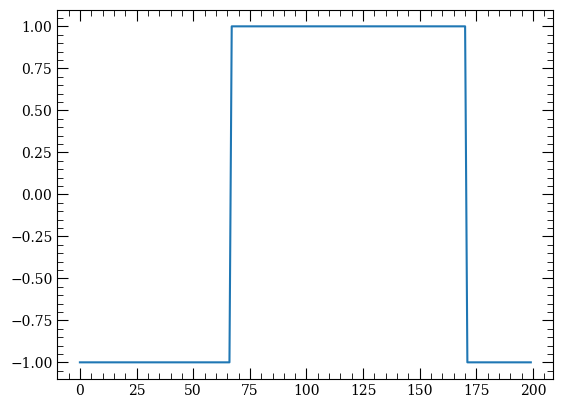

In [177]:
t = np.linspace(0, 6, 200)

# create the square wave
y = np.sign(np.sin(t-2)) 
plt.plot(y)

In [26]:
#check steady state 
#check limit ของ Rabi freq และ pulse ที่สั้นที่สุดเหมาะ 
# ผลรวม doppler effect  
# กำหนดตัวแปรให้ชัดเจน 
# check limit ของการ split 
# check line width

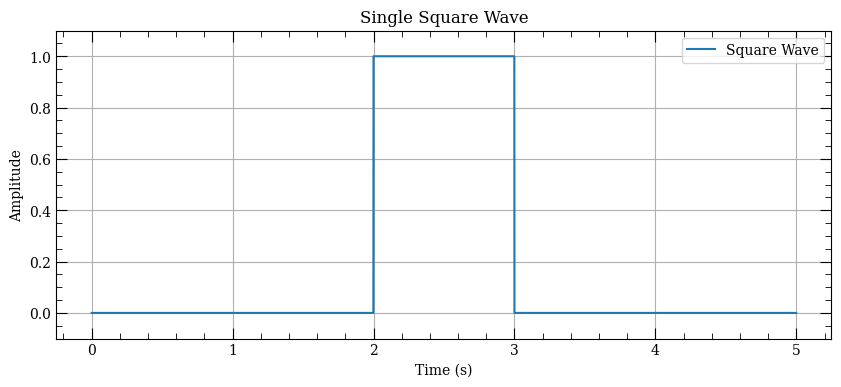

In [178]:
import numpy as np
import matplotlib.pyplot as plt

def generate_square_wave(start_time, duration, total_time, sample_rate):
    """
    Generate a single square wave using numpy.

    Parameters:
    - start_time: The time at which the square wave starts (in seconds).
    - duration: The duration of the square wave (in seconds).
    - total_time: The total time for the signal (in seconds).
    - sample_rate: The number of samples per second.

    Returns:
    - t: The time array.
    - signal: The square wave signal array.
    """
    t = np.arange(0, total_time, 1/sample_rate)
    signal = np.zeros_like(t)
    
    start_index = int(start_time * sample_rate)
    end_index = int((start_time + duration) * sample_rate)
    
    signal[start_index:end_index] = 1
    
    return t, signal

# Parameters
start_time = 2  # in seconds
duration = 1    # in seconds
total_time = 5  # in seconds
sample_rate = 1000  # in Hz

# Generate square wave
t, signal = generate_square_wave(start_time, duration, total_time, sample_rate)

# Plot the square wave
plt.figure(figsize=(10, 4))
plt.plot(t, signal, label='Square Wave')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.title('Single Square Wave')
plt.ylim(-0.1, 1.1)
plt.grid(True)
plt.legend()
plt.show()


In [182]:
#generate single square pulse with np.zeros
def H1_coeff_list(tlist, args):  
    A = args['A'] 
    R = args['R']   
    begin = int(2000/4)
    pulse = np.zeros(2000) 
    pulse[begin:begin + int(R*2000)] = 1
    return A*pulse

# 24/5/2024 test the time dependent with loop

In [42]:
tlist = np.linspace(0.0, 6E-6 , 4000) 
font1 = {'family':'serif','color':'black','size':20}
font2 = {'family':'serif','color':'black','size':15}

In [43]:
t_start = 2e-6 
t_stop = 4e-6

In [44]:
def hamiltonian_time(tlist, args): 
    A = args['A']   
    if tlist < t_start:
        return 0 
    elif t_start <= tlist < t_stop: 
        return A
    elif t_stop <= tlist: 
        return 0 
    else: 
        return

In [45]:
def hamiltonian_time_interval(tlist, args): 
    A = args['A']   
    t_start = args['start']  
    t_stop = args['stop'] 
    if tlist < t_start:
        return 0 
    elif t_start <= tlist < t_stop: 
        return A
    elif t_stop <= tlist: 
        return 0 
    else: 
        return

<>:47: SyntaxWarning: invalid escape sequence '\c'
<>:51: SyntaxWarning: invalid escape sequence '\O'
<>:47: SyntaxWarning: invalid escape sequence '\c'
<>:51: SyntaxWarning: invalid escape sequence '\O'
C:\Users\beam_\AppData\Local\Temp\ipykernel_33468\874623038.py:47: SyntaxWarning: invalid escape sequence '\c'
  ax.set_ylabel('Im[$\chi$]')
C:\Users\beam_\AppData\Local\Temp\ipykernel_33468\874623038.py:51: SyntaxWarning: invalid escape sequence '\O'
  plt.suptitle('EIT, vary $\Omega_{p}$')


[Quantum object: dims=[[4], [4]], shape=(4, 4), type='oper', dtype=Dense, isherm=True
Qobj data =
[[       0.   250000.        0.        0.]
 [  250000.        0.  5000000.        0.]
 [       0.  5000000. 50000000.        0.]
 [       0.        0.        0. 50000000.]], [Quantum object: dims=[[4], [4]], shape=(4, 4), type='oper', dtype=Dense, isherm=True
Qobj data =
[[0.  0.  0.  0. ]
 [0.  0.  0.  0. ]
 [0.  0.  0.  0.5]
 [0.  0.  0.5 0. ]], <function <lambda> at 0x00000269BF7434C0>]]
[0.00000000e+00+0.j         1.00671342e-10+0.00037296j
 1.16517534e-09+0.00074169j ... 2.13010453e-03+0.03240027j
 2.13030480e-03+0.03240028j 2.13050335e-03+0.0324003j ]
[Quantum object: dims=[[4], [4]], shape=(4, 4), type='oper', dtype=Dense, isherm=True
Qobj data =
[[       0.   250000.        0.        0.]
 [  250000.        0.  5000000.        0.]
 [       0.  5000000. 49500000.        0.]
 [       0.        0.        0. 49500000.]], [Quantum object: dims=[[4], [4]], shape=(4, 4), type='oper', dtype

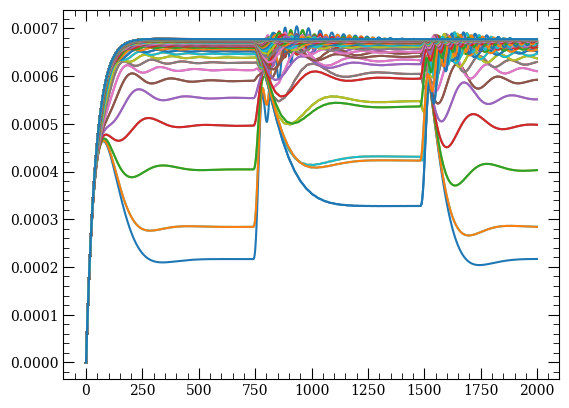

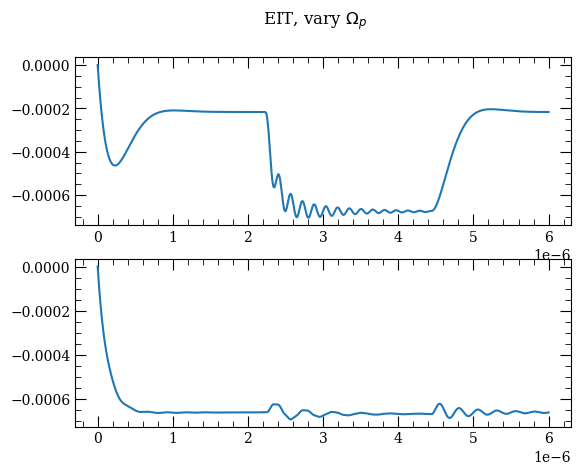

In [47]:
rabi12 = 0.5e6 
rabi23 = 10e6 
rabi34 = 0 
rabi34_value = 20e6 
dp = np.linspace(-100.e6, 100.e6, 201)
dc = np.linspace(-50.e6, 50.e6, 201)
# for rabi23 in Rabi23:
# for rabi34 in Rabi34:
Rabifreq = [rabi12,rabi23,rabi34]
    #print(Rabifreq)
res_split = [] 
chi_list = []
    #for delta12 in dp:
for delta23 in dc:    
    delta = [delta12,delta23,delta34]
    H0 = 1/2*Qobj(Hdiag(delta) + Hoff(Rabifreq))  
    H1 = 1/2*(rho[2][3].dag() + rho[2][3])
    H = [H0,[H1, lambda t, args: hamiltonian_time_interval(t, args)]] 
    print(H)
        
    # result = steadystate(H, c_op_list)
    result = mesolve(H, psi0, tlist, c_op_list,rho[0][1].dag(),args={'A': rabi34_value ,'start' : 2e-6,'stop' :  5e-6})
        
    res_split.append(result.expect)
    # print(H)   
    # print(c_op_list)
    # print(rabi34)
    print(res_split[0][0])
    # print(np.imag(res))
    Efield = E_from_Rabi(rabi12,abs(dipmat12))
    # print()
    #chi = [susceptibility(N_0,np.abs(dipmat12),Efield,rho) for rho in res[0]]
    # # print(np.imag(chi))
    # transmittance = [transmission(L,np.imag(i),lambda12) for i in chi]
    # refraction = np.real(chi)
    # absorption = 2*pi*np.imag(chi)/lambda12
    # print(np.imag(chi)[0])
    # # print(absorption)
    
    # # ax.plot(dp,refraction, label=rabi23*1e-6)
ax.plot(tlist,res_split[2][0], label=str(round(rabi12*1e-6,0))+'MHz') # for rho[0][1]
    # ax.plot(tlist,np.real(res[0][0]), label=str(round(rabi12*1e-6,0))+'MHz') # for rho[0][0]
    #print(res)

# ax.plot(times, result.expect[1]) 
ax.set_xlabel('Time (s)') 
ax.set_ylabel('Im[$\chi$]') 
# ax.legend(("Sigma-Z", "Sigma-Y"))  
ax.legend()
# plt.suptitle('EIT, vary $\Omega_{RF}$')
plt.suptitle('EIT, vary $\Omega_{p}$')
# plt.ylim(-0.0007,-0.0006) 
plt.show()

In [48]:
Efield = E_from_Rabi(rabi12,abs(dipmat12)) 
chi_list = []
for i in range(len(dc)):  
    chi = [susceptibility(N_0,np.abs(dipmat12),Efield,rho) for rho in res_split[i][0]] 
    chi_list.append(chi)
    plt.plot(np.imag(chi))

In [49]:
fig, axs = plt.subplots(2)
fig.suptitle("32S EIT- Im[$\chi$]"+"-tlist")
axs[0].plot(tlist, -1*np.imag(chi_list[100]))
axs[1].plot(tlist, -1*np.imag(chi_list[88]))

<>:2: SyntaxWarning: invalid escape sequence '\c'
<>:2: SyntaxWarning: invalid escape sequence '\c'
C:\Users\beam_\AppData\Local\Temp\ipykernel_33468\1387449530.py:2: SyntaxWarning: invalid escape sequence '\c'
  fig.suptitle("32S EIT- Im[$\chi$]"+"-tlist")


<>:2: SyntaxWarning: invalid escape sequence '\c'
<>:3: SyntaxWarning: invalid escape sequence '\m'
<>:4: SyntaxWarning: invalid escape sequence '\c'
<>:2: SyntaxWarning: invalid escape sequence '\c'
<>:3: SyntaxWarning: invalid escape sequence '\m'
<>:4: SyntaxWarning: invalid escape sequence '\c'
C:\Users\beam_\AppData\Local\Temp\ipykernel_33468\2716504491.py:2: SyntaxWarning: invalid escape sequence '\c'
  plt.suptitle('32S EIT peak height fit (arb. unit) '+"-Im[$\chi$]", fontsize=font1['size'], family=font1['family'], color=font1['color'])
C:\Users\beam_\AppData\Local\Temp\ipykernel_33468\2716504491.py:3: SyntaxWarning: invalid escape sequence '\m'
  plt.xlabel("time"+"($\mu$s)", fontsize=font2['size'], family=font2['family'], color=font2['color'])
C:\Users\beam_\AppData\Local\Temp\ipykernel_33468\2716504491.py:4: SyntaxWarning: invalid escape sequence '\c'
  plt.ylabel("-Im[$\chi$]", fontsize=font2['size'], family=font2['family'], color=font2['color'])


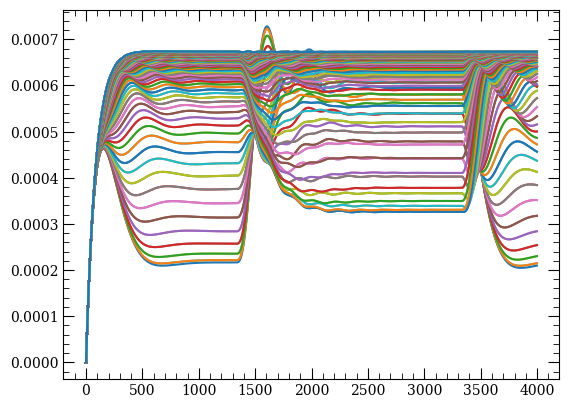

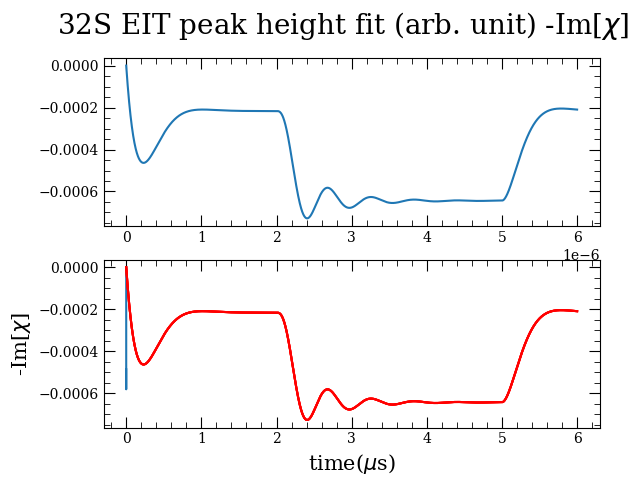

In [53]:
plt.plot(tlist*1e6, -1*np.imag(chi_list[100]),'r') 
plt.suptitle('32S EIT peak height fit (arb. unit) '+"-Im[$\chi$]", fontsize=font1['size'], family=font1['family'], color=font1['color'])
plt.xlabel("time"+"($\mu$s)", fontsize=font2['size'], family=font2['family'], color=font2['color'])
plt.ylabel("-Im[$\chi$]", fontsize=font2['size'], family=font2['family'], color=font2['color'])
plt.show()

<>:2: SyntaxWarning: invalid escape sequence '\c'
<>:3: SyntaxWarning: invalid escape sequence '\m'
<>:4: SyntaxWarning: invalid escape sequence '\c'
<>:2: SyntaxWarning: invalid escape sequence '\c'
<>:3: SyntaxWarning: invalid escape sequence '\m'
<>:4: SyntaxWarning: invalid escape sequence '\c'
C:\Users\beam_\AppData\Local\Temp\ipykernel_33468\54222017.py:2: SyntaxWarning: invalid escape sequence '\c'
  plt.suptitle('32S EIT peak height fit (arb. unit) '+"-Im[$\chi$]", fontsize=font1['size'], family=font1['family'], color=font1['color'])
C:\Users\beam_\AppData\Local\Temp\ipykernel_33468\54222017.py:3: SyntaxWarning: invalid escape sequence '\m'
  plt.xlabel("time"+"($\mu$s)", fontsize=font2['size'], family=font2['family'], color=font2['color'])
C:\Users\beam_\AppData\Local\Temp\ipykernel_33468\54222017.py:4: SyntaxWarning: invalid escape sequence '\c'
  plt.ylabel("-Im[$\chi$]", fontsize=font2['size'], family=font2['family'], color=font2['color'])


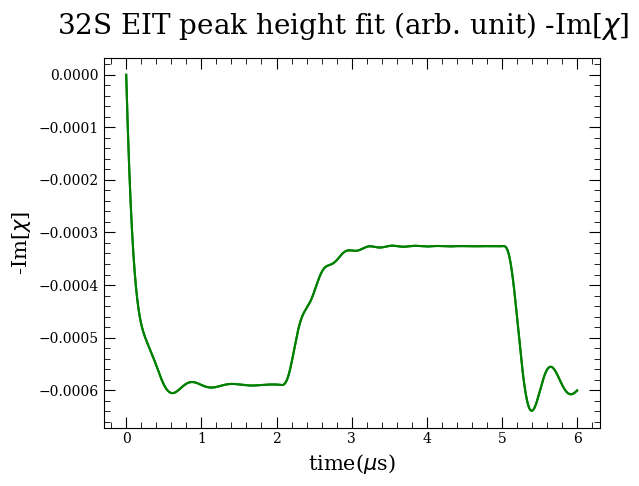

In [55]:
plt.plot(tlist*1e6, -1*np.imag(chi_list[120]),'g') 
plt.suptitle('32S EIT peak height fit (arb. unit) '+"-Im[$\chi$]", fontsize=font1['size'], family=font1['family'], color=font1['color'])
plt.xlabel("time"+"($\mu$s)", fontsize=font2['size'], family=font2['family'], color=font2['color'])
plt.ylabel("-Im[$\chi$]", fontsize=font2['size'], family=font2['family'], color=font2['color'])
plt.show()

In [56]:
peak_split =np.array([[chi_list[i][j] for i in range(len(dc))] for j in range(len(tlist)-1,-1,-1)])

<>:16: SyntaxWarning: invalid escape sequence '\m'
<>:16: SyntaxWarning: invalid escape sequence '\m'
C:\Users\beam_\AppData\Local\Temp\ipykernel_33468\2700563121.py:16: SyntaxWarning: invalid escape sequence '\m'
  ax.set_ylabel("time ($\mu$s)", fontsize=font2['fontsize'], family=font2['family'], color=font2['color'])


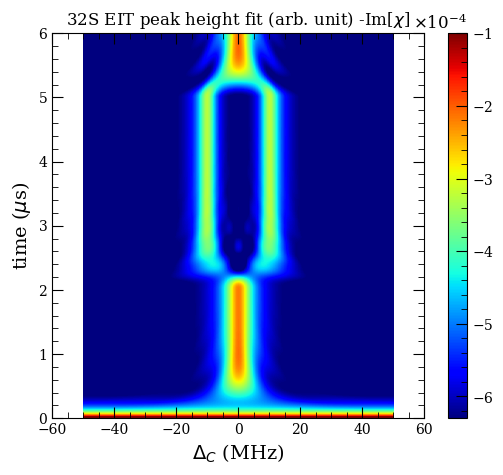

In [76]:
# Plot the heatmap
fig, ax = plt.subplots(figsize=(6, 5))  # Ensure a single figure and axis
img = ax.imshow(-1 * np.imag(peak_split), vmin=-0.00063, vmax=-0.0001, 
                origin='upper', extent=[dc[0]/1e6, dc[-1]/1e6, 0, tlist[-1]*1e6], 
                cmap='jet', aspect='auto')

# Font settings
font1 = {'family': 'serif', 'color': 'black', 'fontsize': 12}
font2 = {'family': 'serif', 'color': 'black', 'fontsize': 14}

# Titles and Labels
ax.set_title(r"32S EIT peak height fit (arb. unit) " + r"-Im[$\chi$]", 
             fontsize=font1['fontsize'], family=font1['family'], color=font1['color'])
ax.set_xlabel(r"$\Delta_C$ (MHz)", fontsize=font2['fontsize'], family=font2['family'], color=font2['color'])
ax.set_xlim(-60, 60)
ax.set_ylabel("time ($\mu$s)", fontsize=font2['fontsize'], family=font2['family'], color=font2['color'])

# **Ensure Only One Color Bar**
cbar = fig.colorbar(img, ax=ax)  # Attach the colorbar to the main axis

# Format Color Bar in Scientific Notation
cbar.ax.yaxis.set_major_formatter(ticker.ScalarFormatter(useMathText=True))  # Use scientific notation
cbar.ax.ticklabel_format(style='sci', axis='y', scilimits=(0, 0))  # Force scientific scale
cbar.ax.yaxis.get_offset_text().set_fontsize(12)  # Adjust exponent font size

# Show the plot
plt.show()

In [41]:
tlist = np.linspace(0.0, 12E-6 , 4000)

In [42]:
rabi12 = 0.5e6 
rabi23 = 10e6 
rabi34 = 0 
rabi34_value = 20e6 
dp = np.linspace(-100.e6, 100.e6, 201)
dc = np.linspace(-50.e6, 50.e6, 201)
# for rabi23 in Rabi23:
# for rabi34 in Rabi34:
Rabifreq = [rabi12,rabi23,rabi34]
    #print(Rabifreq)
res_split = [] 
chi_list = []
    #for delta12 in dp:
for delta23 in dc:    
    delta = [delta12,delta23,delta34]
    H0 = 1/2*Qobj(Hdiag(delta) + Hoff(Rabifreq))  
    H1 =  1/2*(rho[2][3].dag() + rho[2][3])
    H = [H0,[H1,hamiltonian_time]] 
    print(H)
        
    # result = steadystate(H, c_op_list)
    result = mesolve(H, psi0, tlist, c_op_list,rho[0][1].dag(),args={'A': rabi34_value })
        
    res_split.append(result.expect)
    # print(H)   
    # print(c_op_list)
    # print(rabi34)
    print(res_split[0][0])
    # print(np.imag(res))
    Efield = E_from_Rabi(rabi12,abs(dipmat12))
    # print()
    #chi = [susceptibility(N_0,np.abs(dipmat12),Efield,rho) for rho in res[0]]
    # # print(np.imag(chi))
    # transmittance = [transmission(L,np.imag(i),lambda12) for i in chi]
    # refraction = np.real(chi)
    # absorption = 2*pi*np.imag(chi)/lambda12
    # print(np.imag(chi)[0])
    # # print(absorption)
    
    # # ax.plot(dp,refraction, label=rabi23*1e-6)
ax.plot(tlist,res_split[2][0], label=str(round(rabi12*1e-6,0))+'MHz') # for rho[0][1]
    # ax.plot(tlist,np.real(res[0][0]), label=str(round(rabi12*1e-6,0))+'MHz') # for rho[0][0]
    #print(res)

# ax.plot(times, result.expect[1]) 
ax.set_xlabel('Time (s)') 
ax.set_ylabel('Im[$\chi$]') 
# ax.legend(("Sigma-Z", "Sigma-Y"))  
ax.legend()
# plt.suptitle('EIT, vary $\Omega_{RF}$')
plt.suptitle('EIT, vary $\Omega_{p}$')
# plt.ylim(-0.0007,-0.0006) 
plt.show()

[Quantum object: dims = [[4], [4]], shape = (4, 4), type = oper, isherm = True
Qobj data =
[[       0.   250000.        0.        0.]
 [  250000.        0.  5000000.        0.]
 [       0.  5000000. 50000000.        0.]
 [       0.        0.        0. 50000000.]], [Quantum object: dims = [[4], [4]], shape = (4, 4), type = oper, isherm = True
Qobj data =
[[0.  0.  0.  0. ]
 [0.  0.  0.  0. ]
 [0.  0.  0.  0.5]
 [0.  0.  0.5 0. ]], <function hamiltonian_time at 0x00000192B9EFC0D0>]]
[0.00000000e+00+0.j         1.11920083e-09+0.00074169j
 1.69637473e-08+0.00146653j ... 2.13016947e-03+0.03240343j
 2.13016943e-03+0.03240343j 2.13016940e-03+0.03240343j]
[Quantum object: dims = [[4], [4]], shape = (4, 4), type = oper, isherm = True
Qobj data =
[[       0.   250000.        0.        0.]
 [  250000.        0.  5000000.        0.]
 [       0.  5000000. 49500000.        0.]
 [       0.        0.        0. 49500000.]], [Quantum object: dims = [[4], [4]], shape = (4, 4), type = oper, isherm = True


<Figure size 640x480 with 0 Axes>

In [43]:
print(dc[140])

20000000.0


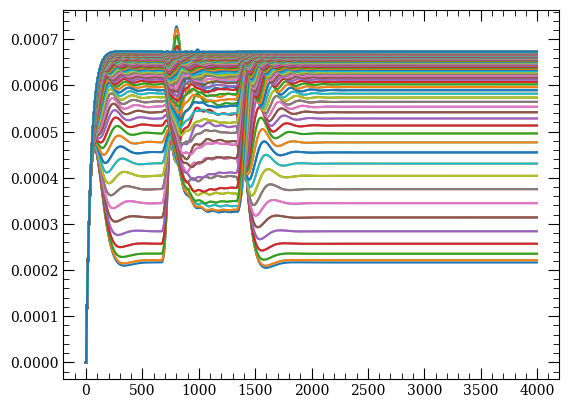

In [44]:
Efield = E_from_Rabi(rabi12,abs(dipmat12)) 
chi_list = []
for i in range(len(dc)):  
    chi = [susceptibility(N_0,np.abs(dipmat12),Efield,rho) for rho in res_split[i][0]] 
    chi_list.append(chi)
    plt.plot(np.imag(chi))

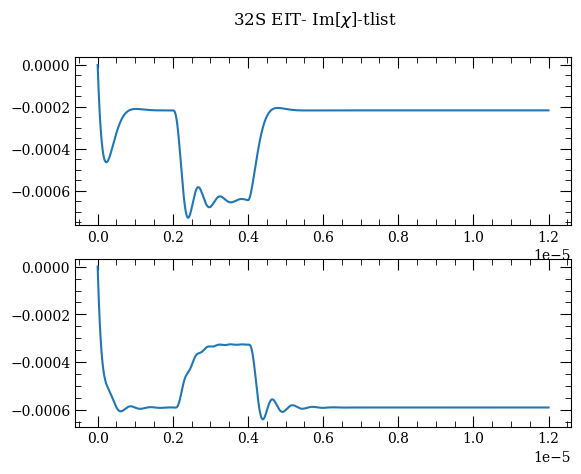

In [45]:
fig, axs = plt.subplots(2)
fig.suptitle("32S EIT- Im[$\chi$]"+"-tlist")
axs[0].plot(tlist, -1*np.imag(chi_list[100]))
axs[1].plot(tlist, -1*np.imag(chi_list[120]))

In [ ]:
peak_split =np.array([[chi_list[i][j] for i in range(len(dc))] for j in range(len(tlist)-1,-1,-1)])

In [ ]:
df = pd.DataFrame(-1*np.imag(peak_split)) 

In [ ]:
print(df)

           0         1         2         3         4         5         6    \
0    -0.000673 -0.000673 -0.000673 -0.000673 -0.000673 -0.000673 -0.000673   
1    -0.000673 -0.000673 -0.000673 -0.000673 -0.000673 -0.000673 -0.000673   
2    -0.000673 -0.000673 -0.000673 -0.000673 -0.000673 -0.000673 -0.000673   
3    -0.000673 -0.000673 -0.000673 -0.000673 -0.000673 -0.000673 -0.000673   
4    -0.000673 -0.000673 -0.000673 -0.000673 -0.000673 -0.000673 -0.000673   
...        ...       ...       ...       ...       ...       ...       ...   
3995 -0.000060 -0.000060 -0.000060 -0.000060 -0.000060 -0.000060 -0.000060   
3996 -0.000045 -0.000045 -0.000045 -0.000045 -0.000045 -0.000045 -0.000045   
3997 -0.000030 -0.000030 -0.000030 -0.000030 -0.000030 -0.000030 -0.000030   
3998 -0.000015 -0.000015 -0.000015 -0.000015 -0.000015 -0.000015 -0.000015   
3999 -0.000000 -0.000000 -0.000000 -0.000000 -0.000000 -0.000000 -0.000000   

           7         8         9    ...       191       192    

In [ ]:
df.to_csv("data_rabi12_"+str(rabi12/1e6)+"_rabi23_"+str(rabi23/1e6)+"_rabi34_"+str(rabi34_value/1e6)+".csv", index=False, header=False)

In [ ]:
data_sim = pd.read_csv('data_rabi12_0.5_rabi23_10.0_rabi34_20.0.csv', sep=',', header=None)

In [ ]:
print(data_sim.values)
data_sim_array = np.flip(data_sim.values)
print(data_sim_array.shape) 

[[-6.73142854e-04 -6.73054141e-04 -6.72962755e-04 ... -6.72962755e-04
  -6.73054141e-04 -6.73142854e-04]
 [-6.73142851e-04 -6.73054146e-04 -6.72962756e-04 ... -6.72962756e-04
  -6.73054146e-04 -6.73142851e-04]
 [-6.73142848e-04 -6.73054151e-04 -6.72962756e-04 ... -6.72962756e-04
  -6.73054151e-04 -6.73142848e-04]
 ...
 [-3.04653986e-05 -3.04653982e-05 -3.04653978e-05 ... -3.04653978e-05
  -3.04653982e-05 -3.04653986e-05]
 [-1.54077228e-05 -1.54077227e-05 -1.54077227e-05 ... -1.54077227e-05
  -1.54077227e-05 -1.54077228e-05]
 [-0.00000000e+00 -0.00000000e+00 -0.00000000e+00 ... -0.00000000e+00
  -0.00000000e+00 -0.00000000e+00]]
(4000, 201)


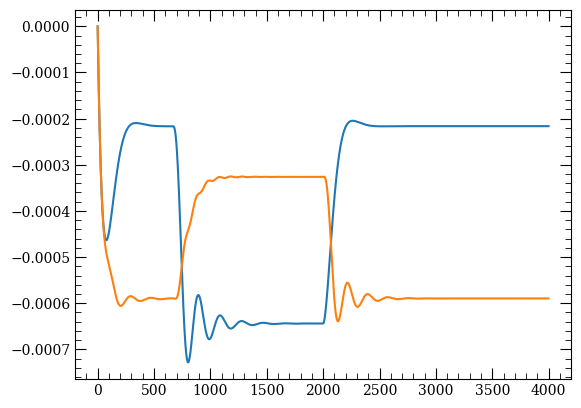

In [ ]:
plt.plot(data_sim_array[:,100]) 
plt.plot(data_sim_array[:,120])

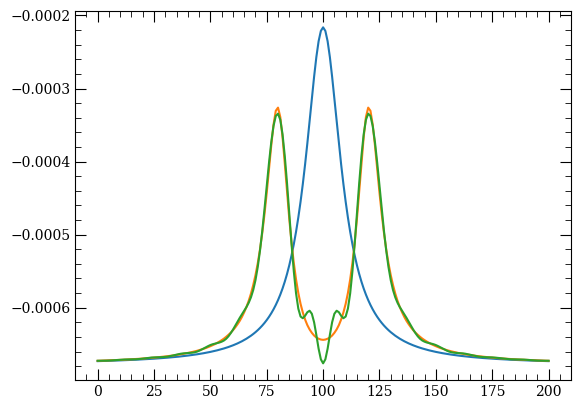

In [ ]:
plt.plot(data_sim_array[3500,:]) 
plt.plot(data_sim_array[1800,:])
plt.plot(data_sim_array[1000,:])

# measure time duration from graph --
# vary time duration for SPC --
# Measure the line width --
# Extract Rabii frequency of oscillation

# 25/5/2024 vary time duration 

In [46]:
t_start = 2e-6 
t_stop = 6e-6

In [121]:
tlist = np.linspace(0.0, 12E-6 , 2401) 
print(tlist)

[0.0000e+00 5.0000e-09 1.0000e-08 ... 1.1990e-05 1.1995e-05 1.2000e-05]


In [48]:
t_array = np.linspace(1,5,5)*1e-6 
print(t_array)

[1.e-06 2.e-06 3.e-06 4.e-06 5.e-06]


In [49]:
t_sim = np.insert(t_array, 0, 0.1e-6) 
print(t_sim)

[1.e-07 1.e-06 2.e-06 3.e-06 4.e-06 5.e-06]


In [50]:
rabi12 = 0.5e6 
rabi23 = 10e6 
rabi34 = 0 
rabi34_value = 20e6 
dp = np.linspace(-100.e6, 100.e6, 201)
dc = np.linspace(-50.e6, 50.e6, 101) 
t_array = np.linspace(1,5,5)*1e-6 
# for rabi23 in Rabi23:
# for rabi34 in Rabi34:
Rabifreq = [rabi12,rabi23,rabi34]
    #print(Rabifreq)

res_split_time = []
    #for delta12 in dp: 
for interval in t_sim: 
    res_split = [] 
    for delta23 in dc:    
        delta = [delta12,delta23,delta34]
        H0 = 1/2*Qobj(Hdiag(delta) + Hoff(Rabifreq))  
        H1 = 1/2*(rho[2][3].dag() + rho[2][3])
        H = [H0,[H1,hamiltonian_time_interval]] 
    #    print(H)
        
    # result = steadystate(H, c_op_list)
        result = mesolve(H, psi0, tlist, c_op_list,rho[0][1].dag(),args={'A': rabi34_value ,'start' : t_start,'stop' : t_start + interval})
        print(t_start + interval)
        res_split.append(result.expect)
    # print(H)   
    # print(c_op_list)
    # print(rabi34)
    #    print(res_split[0][0])
    # print(np.imag(res))
        Efield = E_from_Rabi(rabi12,abs(dipmat12)) 
    res_split_time.append(res_split)
    # print()
    #chi = [susceptibility(N_0,np.abs(dipmat12),Efield,rho) for rho in res[0]]
    # # print(np.imag(chi))
    # transmittance = [transmission(L,np.imag(i),lambda12) for i in chi]
    # refraction = np.real(chi)
    # absorption = 2*pi*np.imag(chi)/lambda12
    # print(np.imag(chi)[0])
    # # print(absorption)
    
    # # ax.plot(dp,refraction, label=rabi23*1e-6)
    ax.plot(tlist,res_split[2][0], label=str(round(rabi12*1e-6,0))+'MHz') # for rho[0][1]
    # ax.plot(tlist,np.real(res[0][0]), label=str(round(rabi12*1e-6,0))+'MHz') # for rho[0][0]
    #print(res)

# ax.plot(times, result.expect[1]) 
ax.set_xlabel('Time (s)') 
ax.set_ylabel('Im[$\chi$]') 
# ax.legend(("Sigma-Z", "Sigma-Y"))  
ax.legend()
# plt.suptitle('EIT, vary $\Omega_{RF}$')
plt.suptitle('EIT, vary $\Omega_{p}$')
# plt.ylim(-0.0007,-0.0006) 
plt.show()

2.1e-06
2.1e-06
2.1e-06
2.1e-06
2.1e-06
2.1e-06
2.1e-06
2.1e-06
2.1e-06
2.1e-06
2.1e-06
2.1e-06
2.1e-06
2.1e-06
2.1e-06
2.1e-06
2.1e-06
2.1e-06
2.1e-06
2.1e-06
2.1e-06
2.1e-06
2.1e-06
2.1e-06
2.1e-06
2.1e-06
2.1e-06
2.1e-06
2.1e-06
2.1e-06
2.1e-06
2.1e-06
2.1e-06
2.1e-06
2.1e-06
2.1e-06
2.1e-06
2.1e-06
2.1e-06
2.1e-06
2.1e-06
2.1e-06
2.1e-06
2.1e-06
2.1e-06
2.1e-06
2.1e-06
2.1e-06
2.1e-06
2.1e-06
2.1e-06
2.1e-06
2.1e-06
2.1e-06
2.1e-06
2.1e-06
2.1e-06
2.1e-06
2.1e-06
2.1e-06
2.1e-06
2.1e-06
2.1e-06
2.1e-06
2.1e-06
2.1e-06
2.1e-06
2.1e-06
2.1e-06
2.1e-06
2.1e-06
2.1e-06
2.1e-06
2.1e-06
2.1e-06
2.1e-06
2.1e-06
2.1e-06
2.1e-06
2.1e-06
2.1e-06
2.1e-06
2.1e-06
2.1e-06
2.1e-06
2.1e-06
2.1e-06
2.1e-06
2.1e-06
2.1e-06
2.1e-06
2.1e-06
2.1e-06
2.1e-06
2.1e-06
2.1e-06
2.1e-06
2.1e-06
2.1e-06
2.1e-06
2.1e-06
3e-06
3e-06
3e-06
3e-06
3e-06
3e-06
3e-06
3e-06
3e-06
3e-06
3e-06
3e-06
3e-06
3e-06
3e-06
3e-06
3e-06
3e-06
3e-06
3e-06
3e-06
3e-06
3e-06
3e-06
3e-06
3e-06
3e-06
3e-06
3e-06
3e-06
3e-06
3e-06


<Figure size 640x480 with 0 Axes>

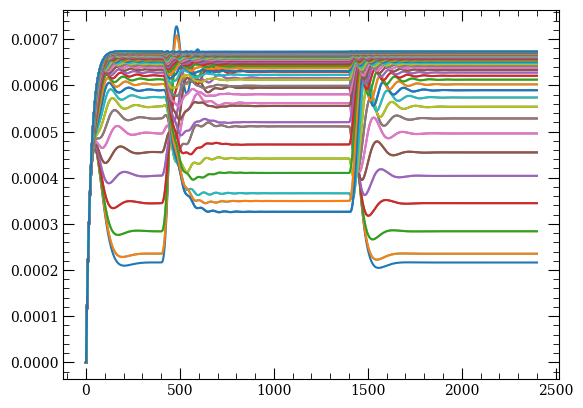

In [51]:
Efield = E_from_Rabi(rabi12,abs(dipmat12)) 
chi_list = []
for i in range(len(dc)):  
    chi = [susceptibility(N_0,np.abs(dipmat12),Efield,rho) for rho in res_split[i][0]] 
    chi_list.append(chi)
    plt.plot(np.imag(chi))

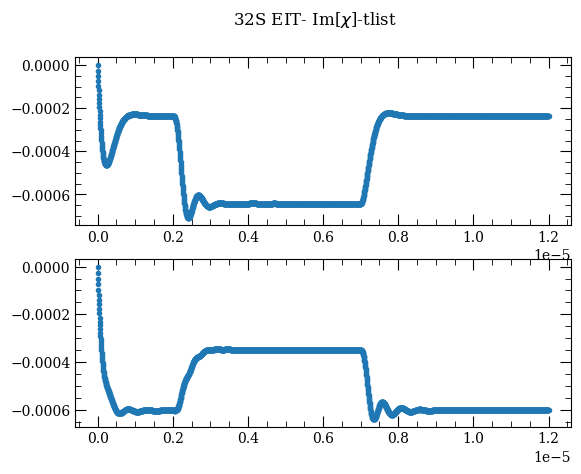

In [52]:
fig, axs = plt.subplots(2)
fig.suptitle("32S EIT- Im[$\chi$]"+"-tlist")
axs[0].plot(tlist, -1*np.imag(chi_list[51]),'.')
axs[1].plot(tlist, -1*np.imag(chi_list[61]),'.')

In [53]:
len(res_split_time) 
print(t_sim[0])

1e-07


In [54]:
Efield = E_from_Rabi(rabi12,abs(dipmat12))  
chi_list_time = []
for time in range(len(t_sim)):  
    chi_list = [] 
    print(t_sim[time])
    for i in range(len(dc)):   
        res_split = res_split_time[time] 
        chi = [susceptibility(N_0,np.abs(dipmat12),Efield,rho) for rho in res_split[i][0]] 
        chi_list.append(chi)
    chi_list_time.append(chi_list)

1e-07
1e-06
2e-06
3e-06
4e-06
4.9999999999999996e-06


In [55]:
print(chi_list_time[0][100]) 


[0j, (-1.714746747873109e-10+2.547853484994715e-05j), (-2.6040124583070357e-09+4.999375184959311e-05j), (-1.2730319482686168e-08+7.356766644771344e-05j), (-3.887883020236974e-08+9.622392887148429e-05j), (-9.141340560627566e-08+0.00011798841795745116j), (-1.8180400612692453e-07+0.00013888960301404932j), (-3.2164732693380995e-07+0.00015895865341469272j), (-5.217182128035608e-07+0.0001782293115464212j), (-7.910974079854896e-07+0.00019673753558703064j), (-1.1364292633306357e-06+0.0002145209417281359j), (-1.5613604838441269e-06+0.00023161809019407305j), (-2.066183325026925e-06+0.0002480676607335615j), (-2.6477065043005035e-06+0.0002639075741129692j), (-3.2993574072711203e-06+0.00027917411856488884j), (-4.011504850819534e-06+0.0002939011379582858j), (-4.7719781185956385e-06+0.00030811933384877554j), (-5.566746075228114e-06+0.0003218557254963826j), (-6.380710924778073e-06+0.0003351333012334479j), (-7.198565282419932e-06+0.0003479708825428988j), (-8.005651691644953e-06+0.0003603832073267586j),

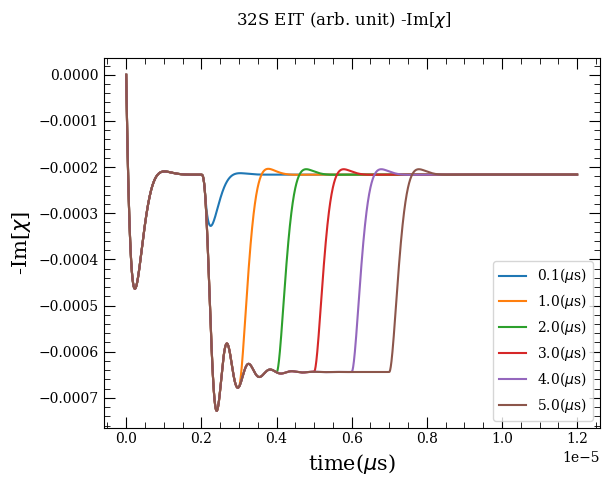

In [56]:
frame_time = []
for i in range(len(t_sim)):   
    t = t_sim[i]*1e6
    plt.plot(tlist,-1*np.imag(chi_list_time[i][50]),label =str("%.1f"%t) +  "($\mu$s)")  
    frame_time.append(-1*np.imag(chi_list_time[i][50])) 

plt.suptitle('32S EIT (arb. unit) '+"-Im[$\chi$]", fontdict = font1) 
plt.xlabel("time"+"($\mu$s)", fontdict = font2) 
plt.ylabel("-Im[$\chi$]", fontdict = font2)
plt.legend()  
plt.show() 

Text(0, 0.5, '-Im[$\\chi$]')

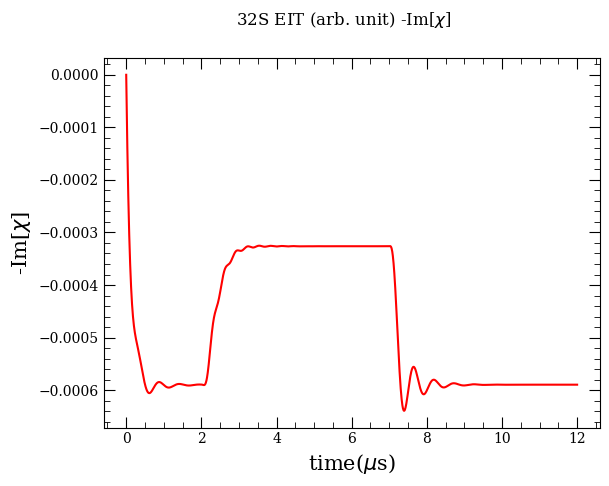

In [57]:
plt.plot(tlist*1e6, -1*np.imag(chi_list[60]),'r') 
plt.suptitle('32S EIT (arb. unit) '+"-Im[$\chi$]", fontdict = font1) 
plt.xlabel("time"+"($\mu$s)", fontdict = font2) 
plt.ylabel("-Im[$\chi$]", fontdict = font2)

In [58]:
dc[60]

10000000.0

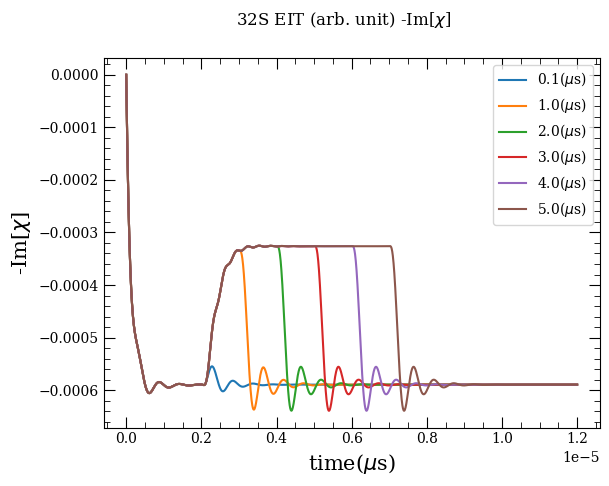

In [59]:
frame_time_off = []
for i in range(len(t_sim)):  
    t = t_sim[i]*1e6
    plt.plot(tlist,-1*np.imag(chi_list_time[i][60]),label =str("%.1f"%t) +  "($\mu$s)")  
    frame_time_off.append(-1*np.imag(chi_list_time[i][60]))

plt.suptitle('32S EIT (arb. unit) '+"-Im[$\chi$]", fontdict = font1) 
plt.xlabel("time"+"($\mu$s)", fontdict = font2) 
plt.ylabel("-Im[$\chi$]", fontdict = font2)
plt.legend()  
plt.show() 

In [1221]:
df_time = pd.DataFrame(frame_time) 

In [1222]:
df_time.to_csv("data_rabi12_"+str(rabi12/1e6)+"_rabi23_"+str(rabi23/1e6)+"_rabi34_"+str(rabi34_value/1e6)
               +"vary_time_from"+str(t_array[0]/1e-6)+"_to_"+str(t_array[-1]/1e-6)+"micro.csv", index=False, header=False)

# Measuring linewidth

In [648]:
tlist_40 = np.linspace(0.0, 12E-6 , 4000)

In [910]:
rabi12 = 0.5e6 
rabi23 = 10e6 
rabi34 = 0 
rabi34_value = 20e6 
dp = np.linspace(-100.e6, 100.e6, 201)
dc = np.linspace(-50.e6, 50.e6, 201)

In [115]:
data_sim = pd.read_csv('data_rabi12_0.5_rabi23_10.0_rabi34_20.0.csv', sep=',', header=None)

In [116]:
print(data_sim.values)
data_sim_array = np.flip(data_sim.values)
print(data_sim_array.shape)

[[-6.77293163e-04 -6.77284554e-04 -6.77281508e-04 ... -6.77281508e-04
  -6.77284554e-04 -6.77293163e-04]
 [-6.77293230e-04 -6.77284361e-04 -6.77281448e-04 ... -6.77281448e-04
  -6.77284361e-04 -6.77293230e-04]
 [-6.77292711e-04 -6.77284684e-04 -6.77280890e-04 ... -6.77280890e-04
  -6.77284684e-04 -6.77292711e-04]
 ...
 [-3.04731507e-05 -3.04731444e-05 -3.04731382e-05 ... -3.04731382e-05
  -3.04731444e-05 -3.04731507e-05]
 [-1.54115432e-05 -1.54115430e-05 -1.54115428e-05 ... -1.54115428e-05
  -1.54115430e-05 -1.54115432e-05]
 [-0.00000000e+00 -0.00000000e+00 -0.00000000e+00 ... -0.00000000e+00
  -0.00000000e+00 -0.00000000e+00]]
(2000, 201)


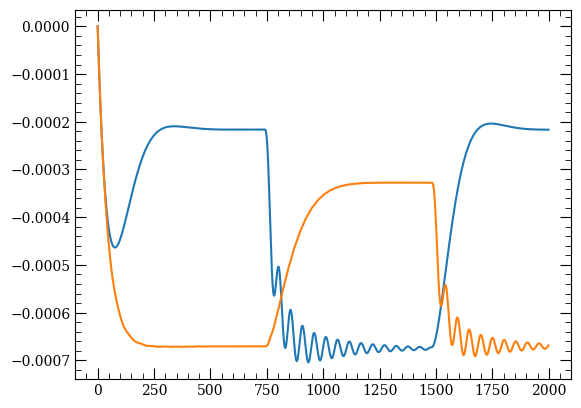

In [117]:
plt.plot(data_sim_array[:,100]) 
plt.plot(data_sim_array[:,120])

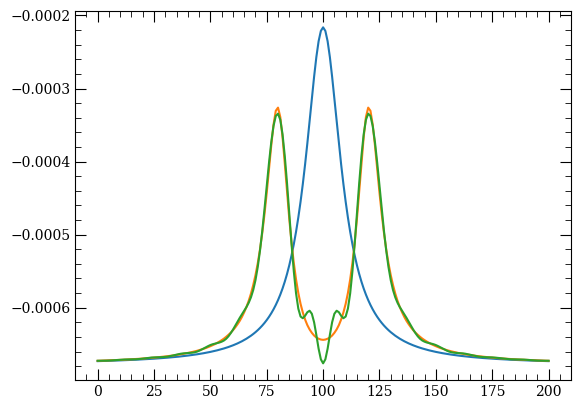

In [979]:
plt.plot(data_sim_array[3500,:]) 
plt.plot(data_sim_array[1800,:])
plt.plot(data_sim_array[1000,:])

[[Model]]
    (Model(lorentzian) + Model(constant))
[[Fit Statistics]]
    # fitting method   = leastsq
    # function evals   = 47
    # data points      = 201
    # variables        = 4
    chi-square         = 19.2937936
    reduced chi-square = 0.09793804
    Akaike info crit   = -463.047809
    Bayesian info crit = -449.834589
    R-squared          = 0.91834129
[[Variables]]
    c:         -6.77221038 +/- 2.3715e-04 (0.00%) (init = -6.604948)
    amplitude:  69.9638434 +/- 0.01471441 (0.02%) (init = -5)
    center:     0.00386801 +/- 7.8622e-04 (20.33%) (init = 0)
    sigma:      4.83444245 +/- 8.8609e-04 (0.02%) (init = 4.5)
    fwhm:       9.66888491 +/- 0.00177219 (0.02%) == '2.0000000*sigma'
    height:     4.60656719 +/- 7.2215e-04 (0.02%) == '0.3183099*amplitude/max(1e-15, sigma)'
[[Correlations]] (unreported correlations are < 0.100)
    C(amplitude, center) = +0.8477
    C(amplitude, sigma)  = +0.6907
    C(c, amplitude)      = -0.6435
    C(c, sigma)          = -0.5125
 

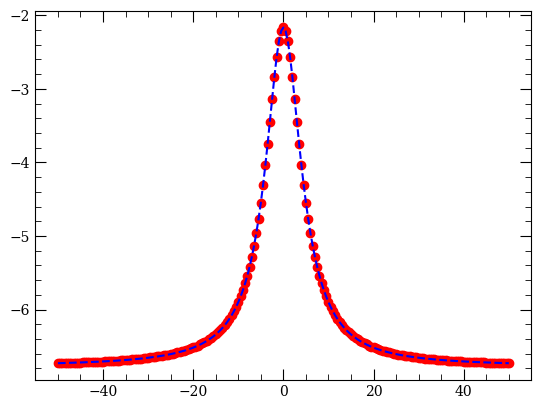

In [915]:
from lmfit import Model
from lmfit.models import GaussianModel, ConstantModel ,LorentzianModel ,LinearModel
import matplotlib.pyplot as plt

xval = dc/1e6
yval = data_sim_array[3500,:]*1e4
err = 5E-2*np.random.standard_normal(dc.shape[0])
#yval = yval+err

peak = LorentzianModel()
offset = ConstantModel()
model = peak + offset

pars = offset.make_params(c=np.median(yval))
pars += peak.guess(yval, x=xval, amplitude=-5)

result = model.fit(yval, pars, x=xval, weights=1/err)
print(result.fit_report())

plt.plot(xval, yval, 'ro', ms=6)
plt.plot(xval, result.best_fit, 'b--')




[[Model]]
    ((Model(linear, prefix='bkg') + Model(lorentzian, prefix='l1_')) + Model(lorentzian, prefix='l2_'))
[[Fit Statistics]]
    # fitting method   = leastsq
    # function evals   = 86
    # data points      = 201
    # variables        = 8
    chi-square         = 1.64698437
    reduced chi-square = 0.00853360
    Akaike info crit   = -949.676149
    Bayesian info crit = -923.249709
    R-squared          = 0.98996500
[[Variables]]
    bkgslope:     -3.6263e-09 +/- 2.3625e-04 (6514970.85%) (init = 1)
    bkgintercept: -6.73191679 +/- 0.00925451 (0.14%) (init = 0)
    l1_amplitude:  32.1243598 +/- 0.49678281 (1.55%) (init = 70)
    l1_center:    -10.3829120 +/- 0.03690566 (0.36%) (init = -5)
    l1_sigma:      2.96390521 +/- 0.05819977 (1.96%) (init = 5)
    l2_amplitude:  32.1243629 +/- 0.49678308 (1.55%) (init = 70)
    l2_center:     10.3829155 +/- 0.03690569 (0.36%) (init = 5)
    l2_sigma:      2.96390563 +/- 0.05819980 (1.96%) (init = 5)
    l1_fwhm:       5.92781042 +/-

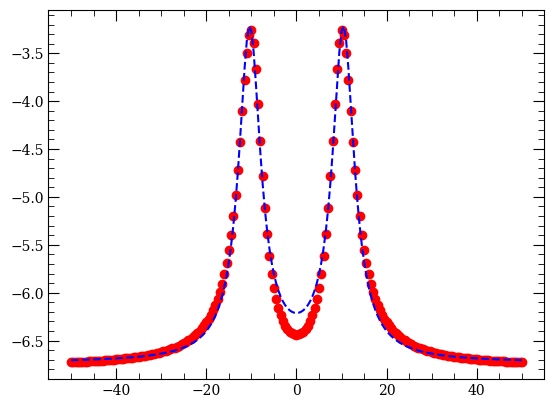

In [916]:
xval = dc/1e6
yval = data_sim_array[1800,:]*1e4
model = LinearModel(prefix='bkg')+LorentzianModel(prefix='l1_')+LorentzianModel(prefix='l2_') 
params = model.make_params(bkg_offset=-7, bkg_slope=0,
                           l1_amplitude=70,
                           l1_center=-5,
                           l1_sigma=5,
                           l2_amplitude=70,
                           l2_center=5,
                           l2_sigma=5)

result = model.fit(yval, params, x=xval)
print(result.fit_report(min_correl=0.5))

#comps = result.eval_components(x=x)
#dely = result.eval_uncertainty(sigma=3)

plt.plot(xval, yval, 'ro', ms=6)
plt.plot(xval, result.best_fit, 'b--')

# Measuring the interval time 

In [76]:
data_sim_time = pd.read_csv('data_rabi12_0.5_rabi23_10.0_rabi34_20.0vary_time_from1.0_to_5.0micro.csv', sep=',', header=None)

In [77]:
print(data_sim_time.values)
data_sim_time_array = np.array(data_sim_time.values)
print(data_sim_time_array.shape)

[[-0.00000000e+00 -2.54785266e-05 -4.99934812e-05 ... -2.16278886e-04
  -2.16278886e-04 -2.16278885e-04]
 [-0.00000000e+00 -2.54785266e-05 -4.99934812e-05 ... -2.16278875e-04
  -2.16278873e-04 -2.16278870e-04]
 [-0.00000000e+00 -2.54785266e-05 -4.99934812e-05 ... -2.16278882e-04
  -2.16278881e-04 -2.16278879e-04]
 [-0.00000000e+00 -2.54785266e-05 -4.99934812e-05 ... -2.16278896e-04
  -2.16278896e-04 -2.16278896e-04]
 [-0.00000000e+00 -2.54785266e-05 -4.99934812e-05 ... -2.16278935e-04
  -2.16278935e-04 -2.16278934e-04]
 [-0.00000000e+00 -2.54785266e-05 -4.99934812e-05 ... -2.16279101e-04
  -2.16279102e-04 -2.16279102e-04]]
(6, 2401)


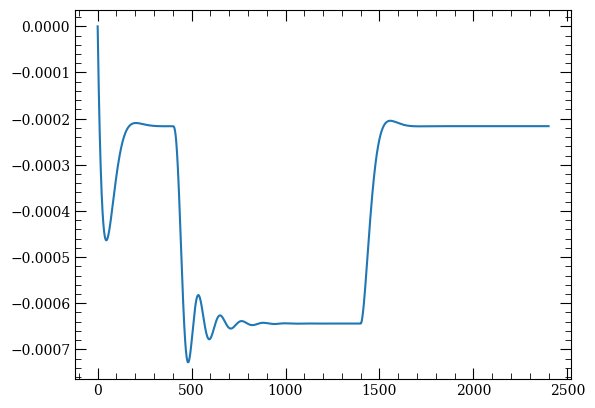

In [78]:
plt.plot(data_sim_time_array[-1])  

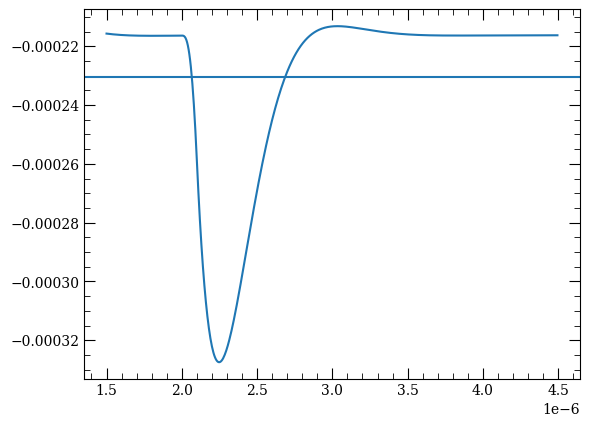

In [79]:
plt.plot(tlist[300:900],data_sim_time_array[0][300:900])  
#add horizontal line at mean value of y
plt.axhline(y=np.nanmean(data_sim_time_array[0][300:900]))

In [ ]:
# วัด width on resonance ง่ายๆ ตีเส้น max ส่วน off resonance ตีจากฐาน

In [80]:
xval = tlist[150:450]
yval = data_sim_time_array[0][150:450]*1e4
err = 5E-2*np.random.standard_normal(xval.shape[0])
#yval = yval+err 

print(xval) 
print(yval)

    # make Model from the super_gaussian function
model = LinearModel(prefix='bkg') + Model(super_lorentzian,prefix='sl1_') 
params = model.make_params(bkg_offset=-7, bkg_slope=0,
                           sl1_x0=-2,
                           sl1_gamma = 4,
                           sl1_amplitude = 2e5)

result = model.fit(yval, params, x=xval)
print(result.fit_report(min_correl=0.5))

#comps = result.eval_components(x=x)
#dely = result.eval_uncertainty(sigma=3)

plt.plot(xval, yval, 'ro', ms=6)
plt.plot(xval, result.best_fit, 'b--')

[7.500e-07 7.550e-07 7.600e-07 7.650e-07 7.700e-07 7.750e-07 7.800e-07
 7.850e-07 7.900e-07 7.950e-07 8.000e-07 8.050e-07 8.100e-07 8.150e-07
 8.200e-07 8.250e-07 8.300e-07 8.350e-07 8.400e-07 8.450e-07 8.500e-07
 8.550e-07 8.600e-07 8.650e-07 8.700e-07 8.750e-07 8.800e-07 8.850e-07
 8.900e-07 8.950e-07 9.000e-07 9.050e-07 9.100e-07 9.150e-07 9.200e-07
 9.250e-07 9.300e-07 9.350e-07 9.400e-07 9.450e-07 9.500e-07 9.550e-07
 9.600e-07 9.650e-07 9.700e-07 9.750e-07 9.800e-07 9.850e-07 9.900e-07
 9.950e-07 1.000e-06 1.005e-06 1.010e-06 1.015e-06 1.020e-06 1.025e-06
 1.030e-06 1.035e-06 1.040e-06 1.045e-06 1.050e-06 1.055e-06 1.060e-06
 1.065e-06 1.070e-06 1.075e-06 1.080e-06 1.085e-06 1.090e-06 1.095e-06
 1.100e-06 1.105e-06 1.110e-06 1.115e-06 1.120e-06 1.125e-06 1.130e-06
 1.135e-06 1.140e-06 1.145e-06 1.150e-06 1.155e-06 1.160e-06 1.165e-06
 1.170e-06 1.175e-06 1.180e-06 1.185e-06 1.190e-06 1.195e-06 1.200e-06
 1.205e-06 1.210e-06 1.215e-06 1.220e-06 1.225e-06 1.230e-06 1.235e-06
 1.240

NameError: name 'LinearModel' is not defined

In [ ]:
# จาก การที่ pulse ที่สั้นเกินไป  ทำให้บางที่จะมีความคาดเคลื่อน จากการที่ pulse ยังไม่เข้า หteady state 
# show graph 1/10 1 micro sec ให้เห็นการ ไม่ steady state 
# check off resonance oscillation compare with on resonance --

# 28/5/ measure line width for on resonance

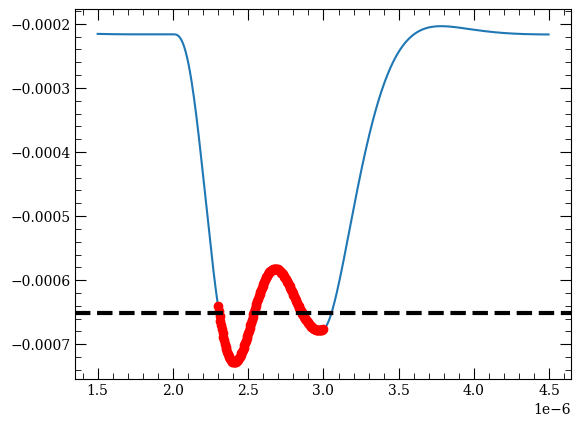

In [81]:
data_pulse_1s = data_sim_time_array[1][300:900]
plt.plot(tlist[300:900],data_sim_time_array[1][300:900])  
#add horizontal line at mean value of y  
start = 460
stop = 600
plt.plot(tlist[start:stop ],data_sim_time_array[1][start:stop],'or')  
plt.axhline(np.nanmean(data_sim_time_array[1][start:stop]),color='black', linestyle='--', linewidth=3, label='Avg') 
plt.show()

In [82]:
print(data_sim_time_array[1].shape)

(2401,)


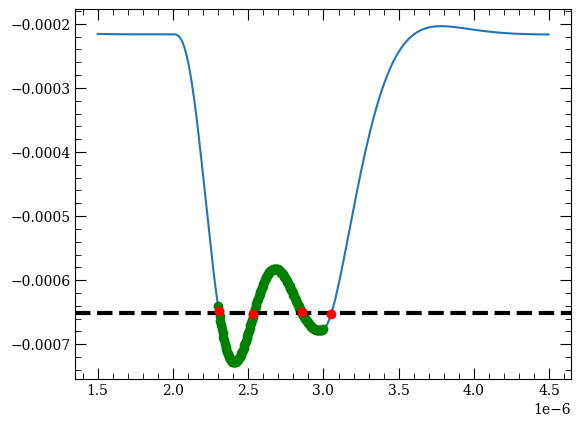

In [83]:
# find the intersection point of 2 graph  
time_duration = tlist[300:900]
data_pulse_1s = data_sim_time_array[1][300:900]
plt.plot(time_duration,data_pulse_1s)  
#add horizontal line at mean value of y  
start = 460
stop = 600 

plt.plot(tlist[start:stop ],data_sim_time_array[1][start:stop],'og')   
horizontal_line = np.nanmean(data_sim_time_array[1][start:stop])
plt.axhline(horizontal_line,color='black', linestyle='--', linewidth=3, label='Avg') 
idx = np.argwhere(np.diff(np.sign(data_pulse_1s - horizontal_line))).flatten()
plt.plot(time_duration[idx], data_pulse_1s[idx], 'ro')
plt.show()

In [120]:
len(tlist)

2401

half_max =  -0.00043373272686162144
full width at half_max =  1.0500000000000001e-06


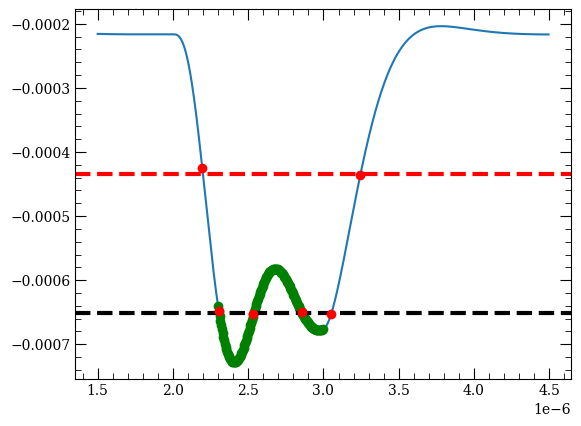

In [85]:
# find the intersection point of 2 graph and full width at half max  
time_duration = tlist[300:900]
data_pulse_1s = data_sim_time_array[1][300:900]
plt.plot(time_duration,data_pulse_1s)  
#add horizontal line at mean value of y  
start = 460
stop = 600 

plt.plot(tlist[start:stop ],data_sim_time_array[1][start:stop],'og')   
horizontal_line = np.nanmean(data_sim_time_array[1][start:stop])
plt.axhline(horizontal_line,color='black', linestyle='--', linewidth=3, label='Avg') 
idx = np.argwhere(np.diff(np.sign(data_pulse_1s - horizontal_line))).flatten()
plt.plot(time_duration[idx], data_pulse_1s[idx], 'ro') 
plt.axhline((np.mean(data_pulse_1s[idx]+data_pulse_1s[0])/2),color='red', linestyle='--', linewidth=3, label='Avg') 
half_max = (horizontal_line+data_pulse_1s[0])/2  
#plt.axhline(half_max,color='yellow', linestyle='--', linewidth=3, label='Avg')  
idx_half = np.argwhere(np.diff(np.sign(data_pulse_1s - half_max))).flatten()  
plt.plot(time_duration[idx_half], data_pulse_1s[idx_half], 'ro') 
print('half_max = ',half_max)  
# ใช้ได้เฉพาะตอนที่มีจุดตัดแค่ 2 จุด
print('full width at half_max = ',time_duration[idx_half][1] - time_duration[idx_half][0]) 
plt.show() 

# จุดที่ 2 ไม่ได้แสดงจุดแดงที่จุดตัดจริง -> step size ใหญ่ไป เป็น error 
# 1. -> ทำ spine ระหว่าง 2 จุด 2. -> ทำให้ step size ละเอียดขึ้น

In [86]:
# create the measuring full width at half max function 
def measure_FWM(num_file,start_crop,end_crop,start_peak,stop_peak): 
    # find the intersection point of 2 graph and full width at half max   
    if end_crop > len(tlist): 
        end_crop = len(tlist)
    time_duration = tlist[start_crop:end_crop]
    data_pulse = data_sim_time_array[int(num_file)][start_crop:end_crop]
    plt.plot(time_duration,data_pulse,label = "Raw crop data")  
    #add horizontal line at mean value of y  

    plt.plot(tlist[start_peak:stop_peak],data_sim_time_array[int(num_file)][start_peak:stop_peak],'og',label = "data for calculation max")   
    horizontal_line = np.nanmean(data_sim_time_array[int(num_file)][start_peak:stop_peak])
    plt.axhline(horizontal_line,color='black', linestyle='--', linewidth=3,label = "Max line") 
    idx = np.argwhere(np.diff(np.sign(data_pulse - horizontal_line))).flatten()
    plt.plot(time_duration[idx], data_pulse[idx], 'ro') 
    plt.axhline((np.mean(data_pulse[idx]+data_pulse[0])/2),color='red', linestyle='--', linewidth=3,label = "Half max line") 
    half_max = (horizontal_line+data_pulse[0])/2  
    #plt.axhline(half_max,color='yellow', linestyle='--', linewidth=3, label='Avg')  
    idx_half = np.argwhere(np.diff(np.sign(data_pulse - half_max))).flatten()  
    plt.plot(time_duration[idx_half], data_pulse[idx_half], 'yo',label = "Intersection points") 
    print('half_max = ',half_max)  
    # ใช้ได้เฉพาะตอนที่มีจุดตัดแค่ 2 จุด
    print('full width at half_max = ',time_duration[idx_half][1] - time_duration[idx_half][0])  
    plt.gca().legend(loc='center left', bbox_to_anchor=(1, 0.5))
    plt.show()  
    return time_duration[idx_half][1] - time_duration[idx_half][0]

half_max =  -0.00043373272686162144
full width at half_max =  1.0500000000000001e-06


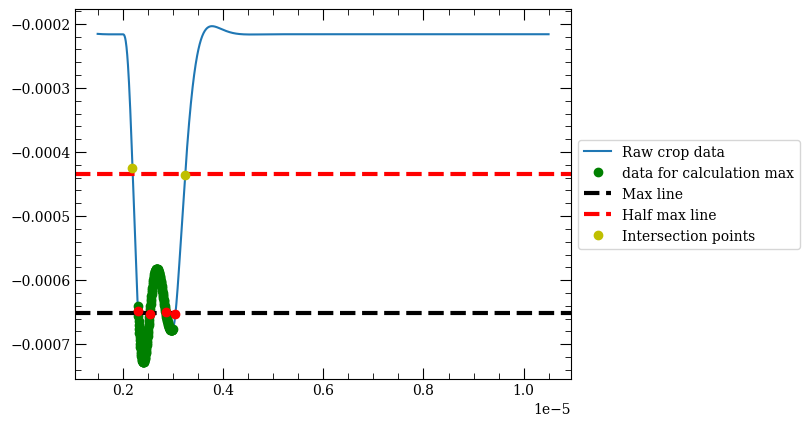

1.0500000000000001e-06

In [87]:
measure_FWM(1,300,2100,460,600)

half_max =  -0.00043373272686162144
full width at half_max =  1.0500000000000001e-06


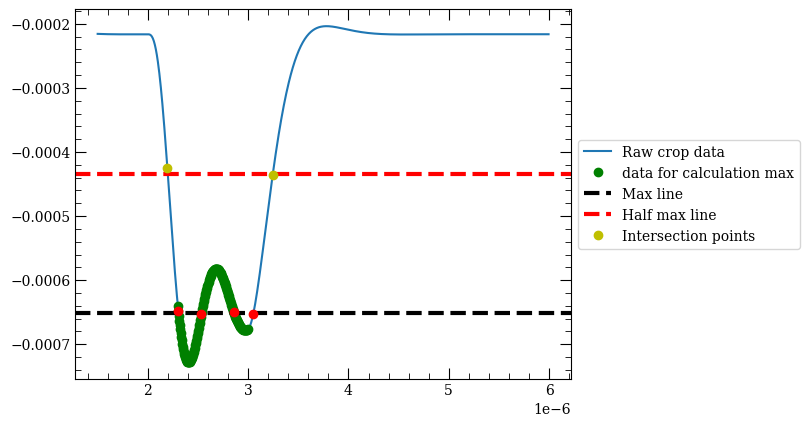

half_max =  -0.00043373272686162144
full width at half_max =  1.0500000000000001e-06


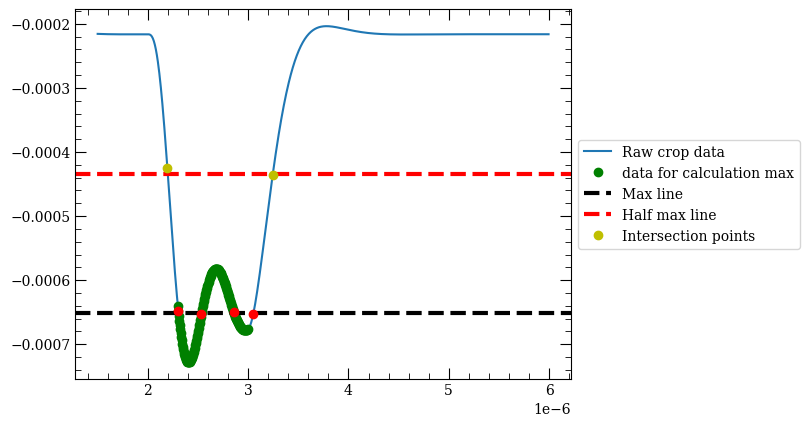

half_max =  -0.0004315565578002335
full width at half_max =  2.045e-06


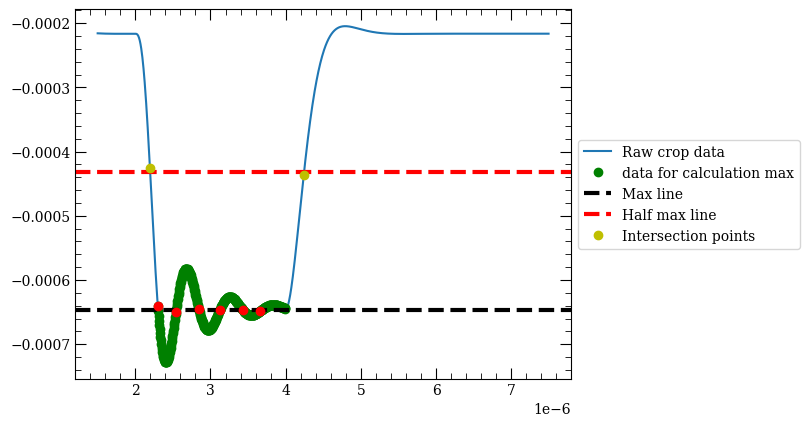

half_max =  -0.0004315565578002335
full width at half_max =  2.045e-06


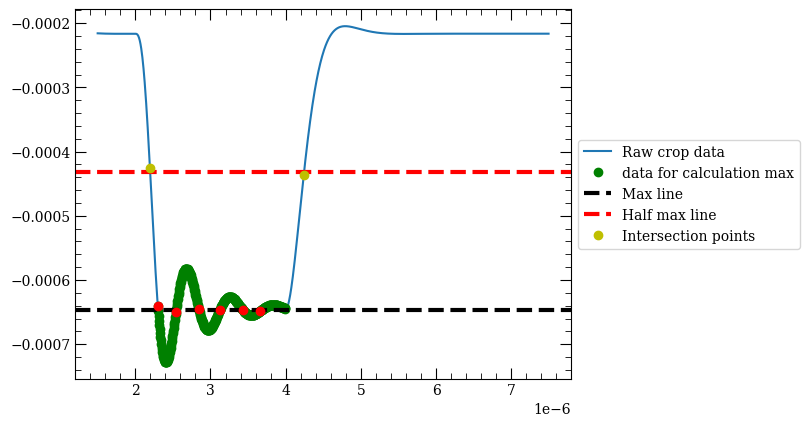

half_max =  -0.00043100971162750334
full width at half_max =  3.0449999999999996e-06


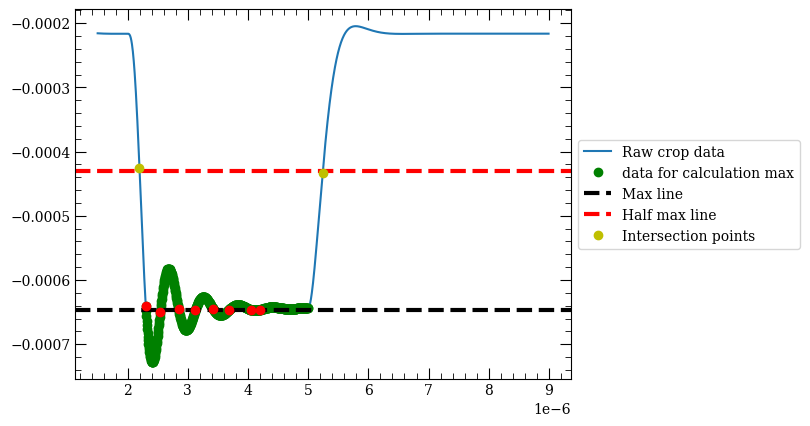

half_max =  -0.00043100971162750334
full width at half_max =  3.0449999999999996e-06


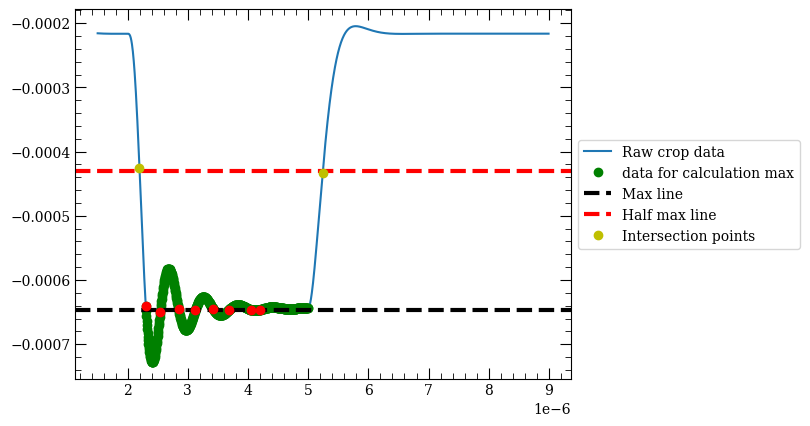

half_max =  -0.0004306910408874878
full width at half_max =  4.045e-06


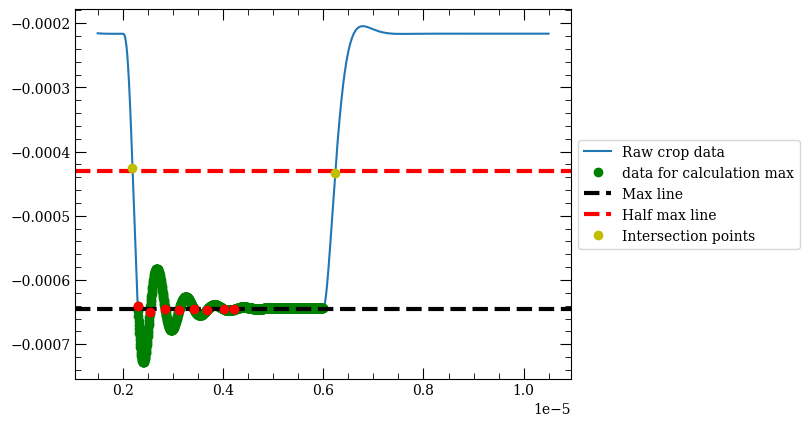

half_max =  -0.0004306910408874878
full width at half_max =  4.045e-06


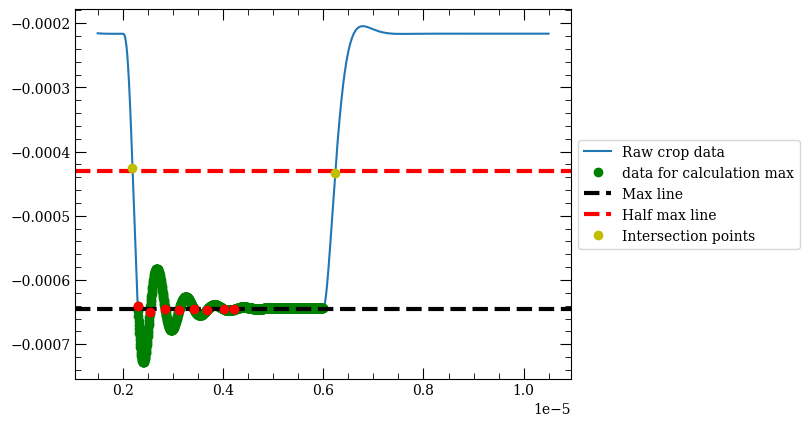

half_max =  -0.0004305049082328962
full width at half_max =  5.045e-06


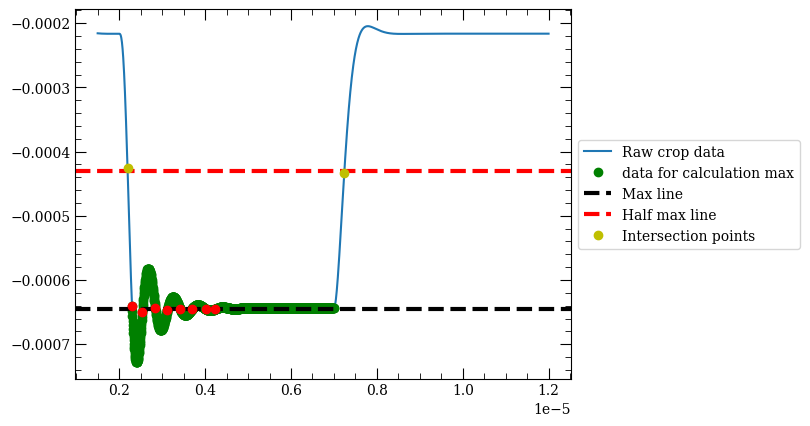

half_max =  -0.0004305049082328962
full width at half_max =  5.045e-06


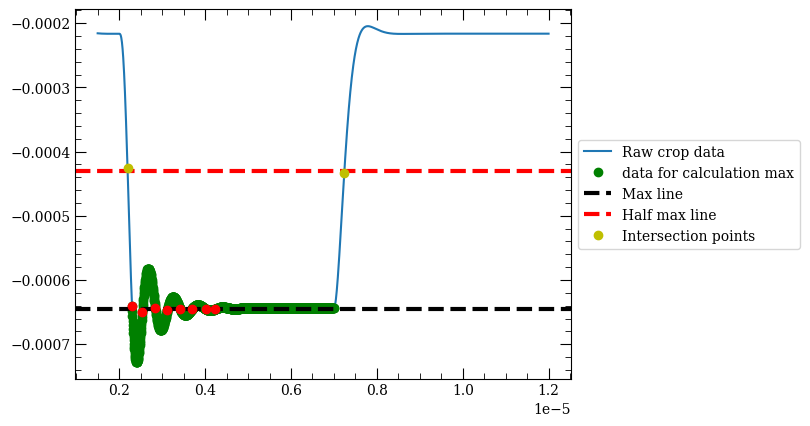

In [88]:
on_resonance_result = []
for i in range(1,len(data_sim_time_array)):  
    measure_FWM(i,300,900 + i*300,460,600 + 200*(i-1)) 
    on_resonance_result.append(measure_FWM(i,300,900 + i*300,460,600 + 200*(i-1)))

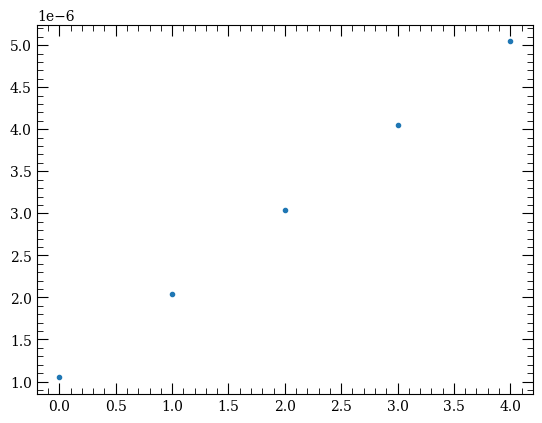

In [89]:
plt.plot(on_resonance_result,'.')

# 28/5/ measure line width for off resonance

# off resonance 10 MHz  
tlist_40 = np.linspace(0.0, 12E-6 , 4000) 
tlist = np.linspace(0.0, 12E-6 , 2401) 
rabi12 = 0.5e6 
rabi23 = 10e6 
rabi34 = 0 
rabi34_value = 20e6 
dp = np.linspace(-100.e6, 100.e6, 201)
dc = np.linspace(-50.e6, 50.e6, 101)

In [90]:
print(dc[60])

10000000.0


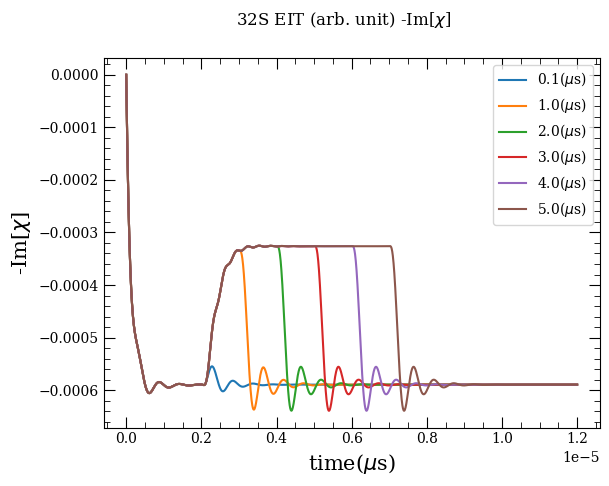

In [122]:
frame_time_off = []
for i in range(len(t_sim)):  
    t = t_sim[i]*1e6
    plt.plot(tlist,-1*np.imag(chi_list_time[i][60]),label =str("%.1f"%t) +  "($\mu$s)")  
    frame_time_off.append(-1*np.imag(chi_list_time[i][60]))

plt.suptitle('32S EIT (arb. unit) '+"-Im[$\chi$]", fontdict = font1) 
plt.xlabel("time"+"($\mu$s)", fontdict = font2) 
plt.ylabel("-Im[$\chi$]", fontdict = font2)
plt.legend()  
plt.show() 

In [1259]:
df_time_off = pd.DataFrame(frame_time_off) 

In [1260]:
df_time_off.to_csv("data_rabi12_"+str(rabi12/1e6)+"_rabi23_"+str(rabi23/1e6)+"_rabi34_"+str(rabi34_value/1e6)
               +"vary_time_from"+str(t_array[0]/1e-6)+"_to_"+str(t_array[-1]/1e-6)+"micro_off_resonance.csv", index=False, header=False)

In [92]:
data_sim_time_off = pd.read_csv('data_rabi12_0.5_rabi23_10.0_rabi34_20.0vary_time_from1.0_to_5.0micro_off_resonance.csv', sep=',', header=None)

In [93]:
print(data_sim_time_off.values)
data_sim_time_off_array = np.array(data_sim_time_off.values)
print(data_sim_time_off_array.shape)

[[-0.00000000e+00 -2.54785269e-05 -4.99934936e-05 ... -5.89609040e-04
  -5.89609038e-04 -5.89609037e-04]
 [-0.00000000e+00 -2.54785269e-05 -4.99934936e-05 ... -5.89609038e-04
  -5.89609036e-04 -5.89609035e-04]
 [-0.00000000e+00 -2.54785269e-05 -4.99934936e-05 ... -5.89609039e-04
  -5.89609039e-04 -5.89609039e-04]
 [-0.00000000e+00 -2.54785269e-05 -4.99934936e-05 ... -5.89609028e-04
  -5.89609026e-04 -5.89609025e-04]
 [-0.00000000e+00 -2.54785269e-05 -4.99934936e-05 ... -5.89608906e-04
  -5.89608906e-04 -5.89608907e-04]
 [-0.00000000e+00 -2.54785269e-05 -4.99934936e-05 ... -5.89607950e-04
  -5.89608011e-04 -5.89608074e-04]]
(6, 2401)


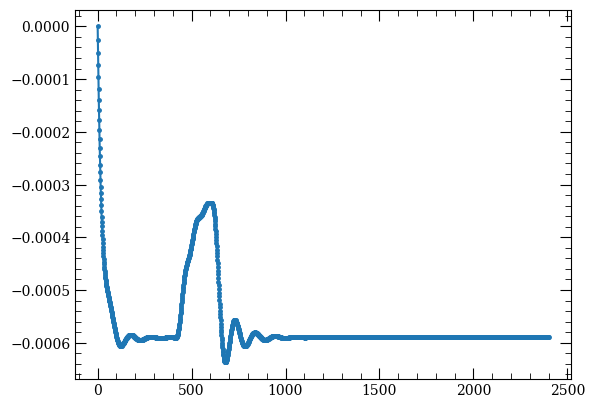

In [94]:
plt.plot(data_sim_time_off_array[1], marker=".", markersize=5)  

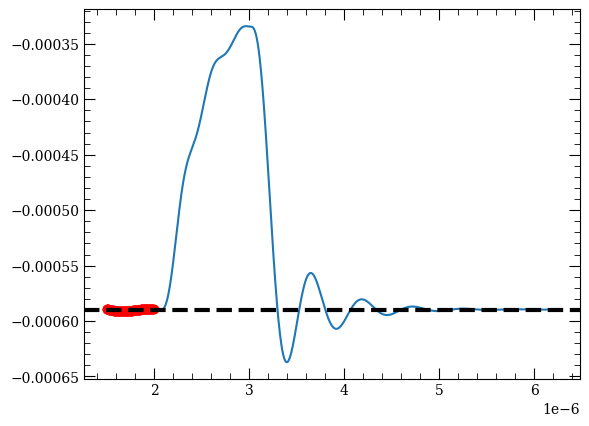

In [95]:
data_pulse_1s_off = data_sim_time_off_array[1][300:1200]
plt.plot(tlist[300:1250],data_sim_time_off_array[1][300:1250])  
#add horizontal line at mean value of y  
start = 300
stop = 400
plt.plot(tlist[start:stop ],data_sim_time_off_array[1][start:stop],'or')  
plt.axhline(np.nanmean(data_sim_time_off_array[1][start:stop]),color='black', linestyle='--', linewidth=3, label='Avg') 
plt.show()

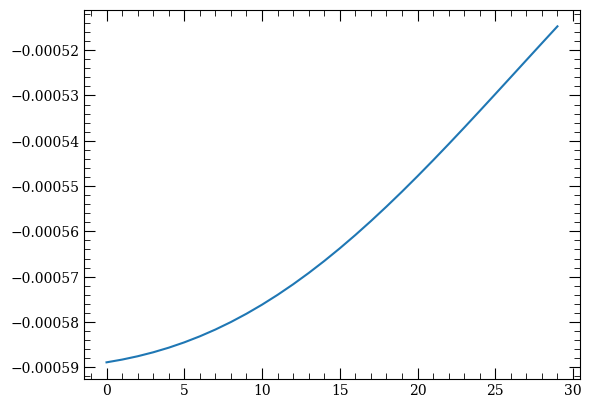

In [96]:
plt.plot(data_sim_time_off_array[1][420:450])

[ 5.27940192e+02 -1.70711157e-03]


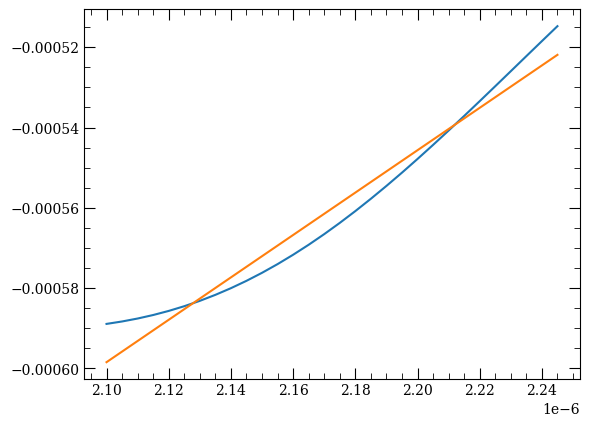

In [97]:

def f(x, A, B): # this is your 'straight line' y=f(x)
    return (A*x) + B

popt, pcov = curve_fit(f, tlist[420:450], data_sim_time_off_array[1][420:450]) # your data x, y to fit 
print(popt) 
plt.plot(tlist[420:450],data_sim_time_off_array[1][420:450]) 
plt.plot(tlist[420:450],f(tlist[420:450],popt[0],popt[1]))

In [99]:
print(time_duration)

[1.500e-06 1.505e-06 1.510e-06 1.515e-06 1.520e-06 1.525e-06 1.530e-06
 1.535e-06 1.540e-06 1.545e-06 1.550e-06 1.555e-06 1.560e-06 1.565e-06
 1.570e-06 1.575e-06 1.580e-06 1.585e-06 1.590e-06 1.595e-06 1.600e-06
 1.605e-06 1.610e-06 1.615e-06 1.620e-06 1.625e-06 1.630e-06 1.635e-06
 1.640e-06 1.645e-06 1.650e-06 1.655e-06 1.660e-06 1.665e-06 1.670e-06
 1.675e-06 1.680e-06 1.685e-06 1.690e-06 1.695e-06 1.700e-06 1.705e-06
 1.710e-06 1.715e-06 1.720e-06 1.725e-06 1.730e-06 1.735e-06 1.740e-06
 1.745e-06 1.750e-06 1.755e-06 1.760e-06 1.765e-06 1.770e-06 1.775e-06
 1.780e-06 1.785e-06 1.790e-06 1.795e-06 1.800e-06 1.805e-06 1.810e-06
 1.815e-06 1.820e-06 1.825e-06 1.830e-06 1.835e-06 1.840e-06 1.845e-06
 1.850e-06 1.855e-06 1.860e-06 1.865e-06 1.870e-06 1.875e-06 1.880e-06
 1.885e-06 1.890e-06 1.895e-06 1.900e-06 1.905e-06 1.910e-06 1.915e-06
 1.920e-06 1.925e-06 1.930e-06 1.935e-06 1.940e-06 1.945e-06 1.950e-06
 1.955e-06 1.960e-06 1.965e-06 1.970e-06 1.975e-06 1.980e-06 1.985e-06
 1.990

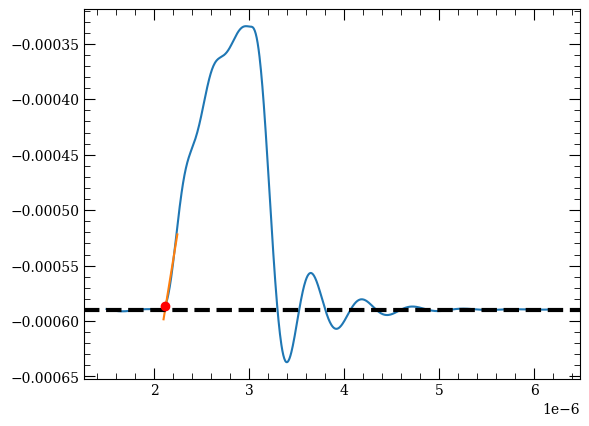

In [100]:
data_pulse_1s_off = data_sim_time_off_array[1][300:1200]
plt.plot(tlist[300:1250],data_sim_time_off_array[1][300:1250])   
plt.plot(tlist[420:450],f(tlist[420:450],popt[0],popt[1]))  
plt.axhline(np.nanmean(data_sim_time_off_array[1][start:stop]),color='black', linestyle='--', linewidth=3, label='Avg')  
idx = np.argwhere(np.diff(np.sign(f(tlist[300:1250],popt[0],popt[1]) - np.nanmean(data_sim_time_off_array[1][start:stop])))).flatten()
plt.plot(time_duration[idx], data_pulse_1s_off[idx], 'ro')
plt.show()

# Code from someone to find the intersection of random graph
https://github.com/sukhbinder/intersection

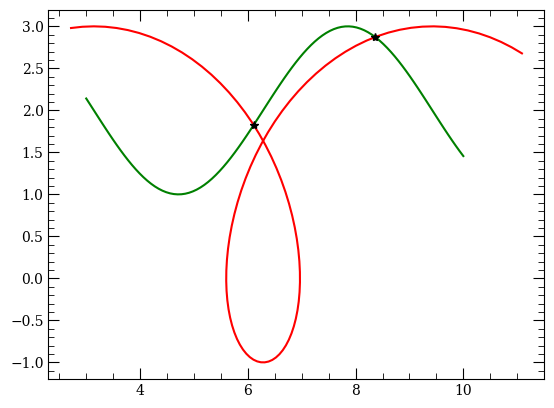

In [787]:
# find the intersection point of 2 graph  
from intersect import intersection

a, b = 1, 2
phi = np.linspace(3, 10, 100)
x1 = a*phi - b*np.sin(phi)
y1 = a - b*np.cos(phi)

x2 = phi
y2 = np.sin(phi)+2
x, y = intersection(x1, y1, x2, y2)

plt.plot(x1, y1, c="r")
plt.plot(x2, y2, c="g")
plt.plot(x, y, "*k")
plt.show()

[ 5.27940192e+02 -1.70711157e-03]


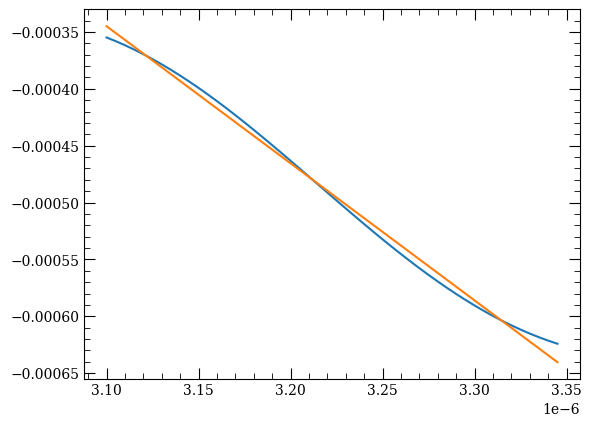

In [101]:
start = 620
stop = 670 
time_duration = tlist[300:900]
popt2, pcov2 = curve_fit(f, tlist[start:stop], data_sim_time_off_array[1][start:stop]) # your data x, y to fit 
print(popt) 
plt.plot(tlist[start:stop],data_sim_time_off_array[1][start:stop]) 
plt.plot(tlist[start:stop],f(tlist[start:stop],popt2[0],popt2[1]))

In [102]:
print(time_duration.shape)

(600,)


-0.0005901858324601849
[-0.00059053]


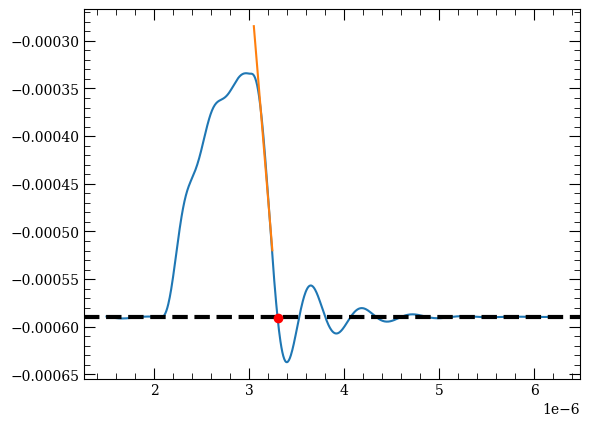

In [103]:
data_pulse_1s_off = data_sim_time_off_array[1][300:1200]
plt.plot(tlist[300:1250],data_sim_time_off_array[1][300:1250])   
plt.plot(tlist[610:650],f(tlist[610:650],popt2[0],popt2[1]))  
plt.axhline(np.nanmean(data_sim_time_off_array[1][300:400]),color='black', linestyle='--', linewidth=3, label='Avg')  
idx = np.argwhere(np.diff(np.sign(f(tlist[300:1250],popt2[0],popt2[1]) - np.nanmean(data_sim_time_off_array[0][300:400])))).flatten() 
print(np.nanmean(data_sim_time_off_array[1][300:400])) 
print(data_pulse_1s_off[idx])
plt.plot(time_duration[idx], data_pulse_1s_off[idx], 'ro')
plt.show()

[1.185e-06]


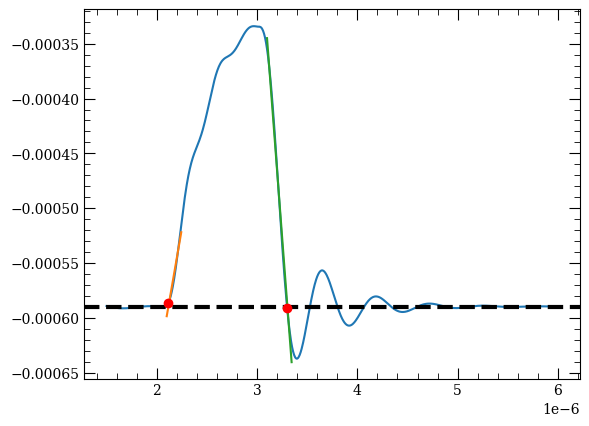

In [104]:
start_interval = 300 
end_interval = 1200 
start1 = 420 
stop1 = 450 
start2 = 620 
stop2 = 670 
plt.plot(tlist[start_interval:end_interval],data_sim_time_off_array[1][start_interval:end_interval])   
horizontal_line_off = np.nanmean(data_sim_time_off_array[1][start_interval:start_interval+100])
plt.axhline(horizontal_line_off,color='black', linestyle='--', linewidth=3, label='Avg')   
popt, pcov = curve_fit(f, tlist[start1:stop1], data_sim_time_off_array[1][start1:stop1]) 
popt2, pcov2 = curve_fit(f, tlist[start2:stop2], data_sim_time_off_array[1][start2:stop2])  

 
plt.plot(tlist[start1:stop1],f(tlist[start1:stop1],popt[0],popt[1])) 
idx1 = np.argwhere(np.diff(np.sign(f(tlist[start_interval:end_interval],popt[0],popt[1]) - horizontal_line_off))).flatten()
plt.plot(time_duration[idx1], data_pulse_1s_off[idx1], 'ro')
plt.plot(tlist[start2:stop2],f(tlist[start2:stop2],popt2[0],popt2[1]))  
 
idx2 = np.argwhere(np.diff(np.sign(f(tlist[start_interval:end_interval],popt2[0],popt2[1]) - horizontal_line_off))).flatten() 
plt.plot(time_duration[idx2], data_pulse_1s_off[idx2], 'ro') 

print(time_duration[idx2] - time_duration[idx1])

In [105]:
def measure_time(num_file,start_interval,end_interval,start1,stop1,start2,stop2):  
    if end_interval > len(tlist): 
        end_interval = len(tlist)

    data_pulse_off = data_sim_time_off_array[num_file][start_interval:end_interval]
    plt.plot(tlist[start_interval:end_interval],data_sim_time_off_array[num_file][start_interval:end_interval])   
    horizontal_line_off = np.nanmean(data_sim_time_off_array[num_file][start_interval:start_interval+100])
    plt.axhline(horizontal_line_off,color='black', linestyle='--', linewidth=3, label='Avg')   
    popt, pcov = curve_fit(f, tlist[start1:stop1], data_sim_time_off_array[num_file][start1:stop1]) 
    popt2, pcov2 = curve_fit(f, tlist[start2:stop2], data_sim_time_off_array[num_file][start2:stop2])  

 
    plt.plot(tlist[start1:stop1],f(tlist[start1:stop1],popt[0],popt[1])) 
    idx1 = np.argwhere(np.diff(np.sign(f(tlist[start_interval:end_interval],popt[0],popt[1]) - horizontal_line_off))).flatten()
    plt.plot(tlist[idx1+start_interval], data_pulse_off[idx1], 'ro')
    plt.plot(tlist[start2:stop2],f(tlist[start2:stop2],popt2[0],popt2[1]))  
 
    idx2 = np.argwhere(np.diff(np.sign(f(tlist[start_interval:end_interval],popt2[0],popt2[1]) - horizontal_line_off))).flatten() 
    plt.plot(tlist[idx2+start_interval], data_pulse_off[idx2], 'ro') 
    print('RF activated time (s) = ',tlist[idx2] - tlist[idx1])
    return tlist[idx2] - tlist[idx1]

RF activated time (s) =  [1.185e-06]


array([1.185e-06])

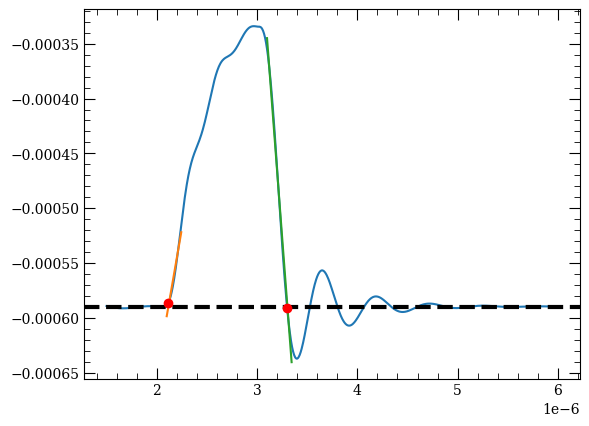

In [106]:
measure_time(1,300,1200,420,450,620,670)

In [108]:
print(tlist[1160])

5.8e-06


RF activated time (s) =  [5.325e-06]


array([5.325e-06])

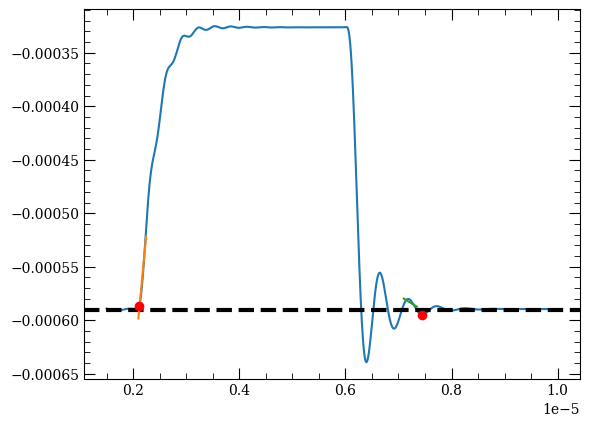

In [109]:
measure_time(4,300,2000,420,450,1420,1470)

RF activated time (s) =  [1.185e-06]
RF activated time (s) =  [1.185e-06]
RF activated time (s) =  [2.185e-06]
RF activated time (s) =  [2.185e-06]
RF activated time (s) =  [3.185e-06]
RF activated time (s) =  [3.185e-06]
RF activated time (s) =  [4.185e-06]
RF activated time (s) =  [4.185e-06]
RF activated time (s) =  [5.185e-06]
RF activated time (s) =  [5.185e-06]


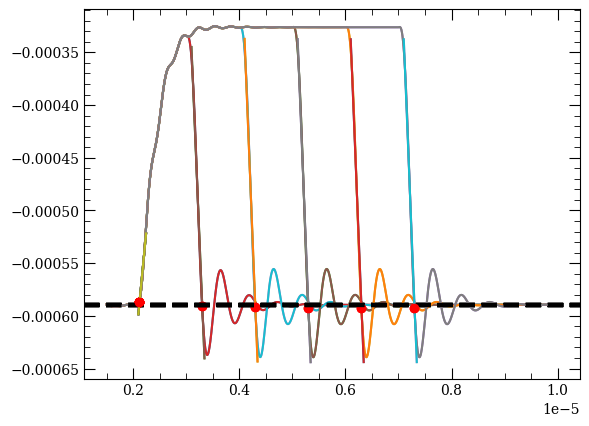

In [110]:
off_resonance_result = []
for i in range(1,len(data_sim_time_array)): 
    measure_time(i,300,2000,420,450,620 + 200*(i-1),670 + 200*(i-1))  
    off_resonance_result.append(measure_time(i,300,2000,420,450,620 + 200*(i-1),670 + 200*(i-1))[0]) 
    #plt.show()

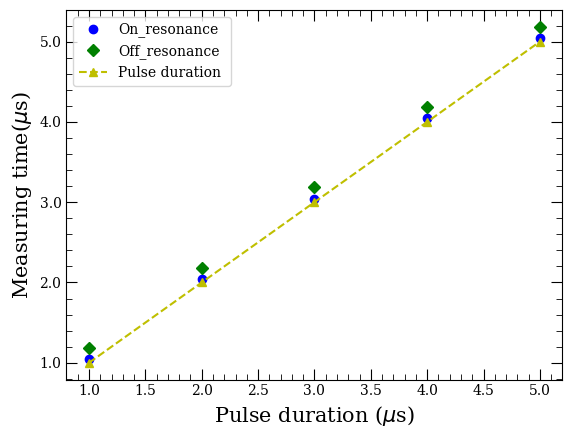

In [113]:
plt.plot(np.array(t_sim[1:6])*1e6,np.array(on_resonance_result)*1e6,'bo',label= 'On_resonance')  
y =  np.array(t_sim[1:6])*1e6
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: '{:.1f}'.format(y)))
plt.plot(np.array(t_sim[1:6])*1e6,np.array(off_resonance_result)*1e6,'gD',label= 'Off_resonance')  
plt.plot(np.array(t_sim[1:6])*1e6,np.array(t_sim[1:6])*1e6,'--y^',label= 'Pulse duration ') 
plt.xlabel("Pulse duration "+"($\mu$s)", fontdict = font2) 
plt.ylabel("Measuring time"+"($\mu$s)", fontdict = font2)
plt.legend()  
plt.show() 

# Measure off - resonance with full width at half max

In [123]:
# create the measuring full width at half max function 
def measure_FWM_array(data_sim_time_array,num_file,start_crop,end_crop,start_peak,stop_peak): 
    # find the intersection point of 2 graph and full width at half max   
    if end_crop > len(tlist): 
        end_crop = len(tlist)
    time_duration = tlist[start_crop:end_crop]
    data_pulse = data_sim_time_array[int(num_file)][start_crop:end_crop]
    plt.plot(time_duration,data_pulse,label = "Raw crop data")  
    #add horizontal line at mean value of y  

    plt.plot(tlist[start_peak:stop_peak],data_sim_time_array[int(num_file)][start_peak:stop_peak],'og',label = "data for calculation max")   
    horizontal_line = np.nanmean(data_sim_time_array[int(num_file)][start_peak:stop_peak])
    plt.axhline(horizontal_line,color='black', linestyle='--', linewidth=3,label = "Max line") 
    idx = np.argwhere(np.diff(np.sign(data_pulse - horizontal_line))).flatten()
    plt.plot(time_duration[idx], data_pulse[idx], 'ro') 
    plt.axhline((np.mean(data_pulse[idx]+data_pulse[0])/2),color='red', linestyle='--', linewidth=3,label = "Half max line") 
    half_max = (horizontal_line+data_pulse[0])/2  
    #plt.axhline(half_max,color='yellow', linestyle='--', linewidth=3, label='Avg')  
    idx_half = np.argwhere(np.diff(np.sign(data_pulse - half_max))).flatten()  
    plt.plot(time_duration[idx_half], data_pulse[idx_half], 'yo',label = "Intersection points") 
    print('half_max = ',half_max)  
    # ใช้ได้เฉพาะตอนที่มีจุดตัดแค่ 2 จุด
    print('full width at half_max = ',time_duration[idx_half][1] - time_duration[idx_half][0])  
    plt.gca().legend(loc='center left', bbox_to_anchor=(1, 0.5))
    plt.show()  
    return time_duration[idx_half][1] - time_duration[idx_half][0]

half_max =  -0.00046165035897708
full width at half_max =  8.599999999999998e-07


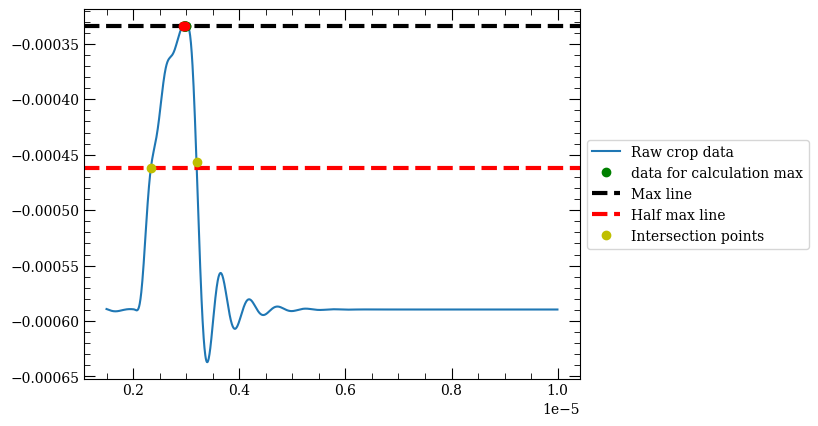

8.599999999999998e-07

In [133]:
measure_FWM_array(data_sim_time_off_array,1,300,2000,590,600)

half_max =  -0.0004586243755275081
full width at half_max =  1.8500000000000005e-06


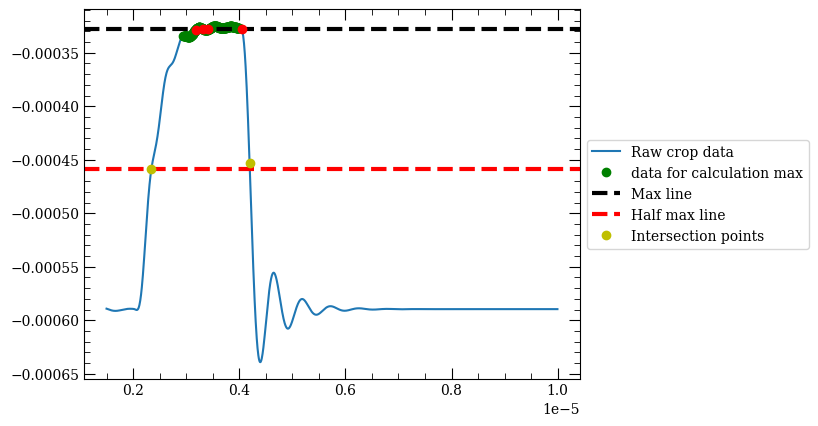

1.8500000000000005e-06

In [135]:
measure_FWM_array(data_sim_time_off_array,2,300,2000,590,800)

half_max =  -0.00045816525153639183
full width at half_max =  2.8500000000000002e-06


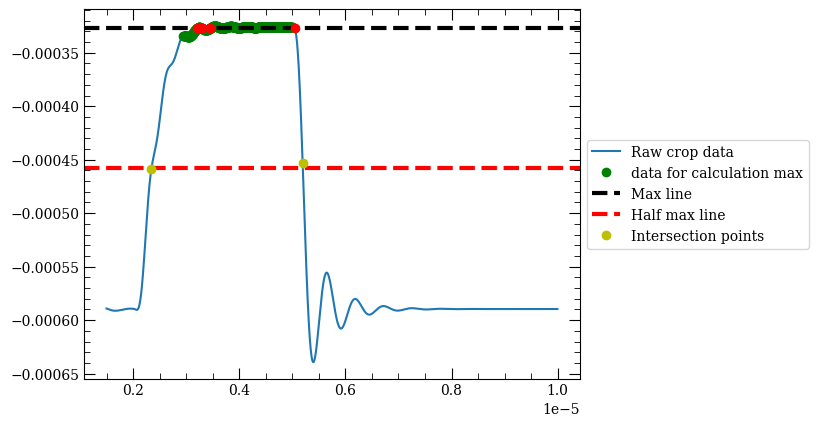

2.8500000000000002e-06

In [138]:
measure_FWM_array(data_sim_time_off_array,3,300,2000,590,1000)

half_max =  -0.00046165035897708
full width at half_max =  8.599999999999998e-07


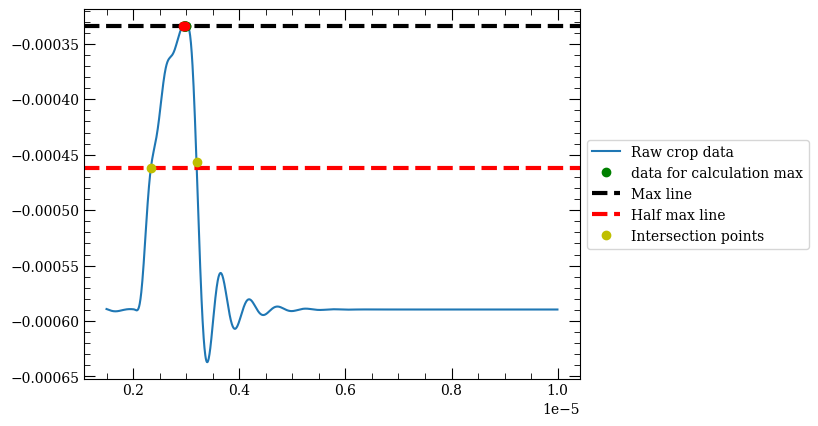

half_max =  -0.00046165035897708
full width at half_max =  8.599999999999998e-07


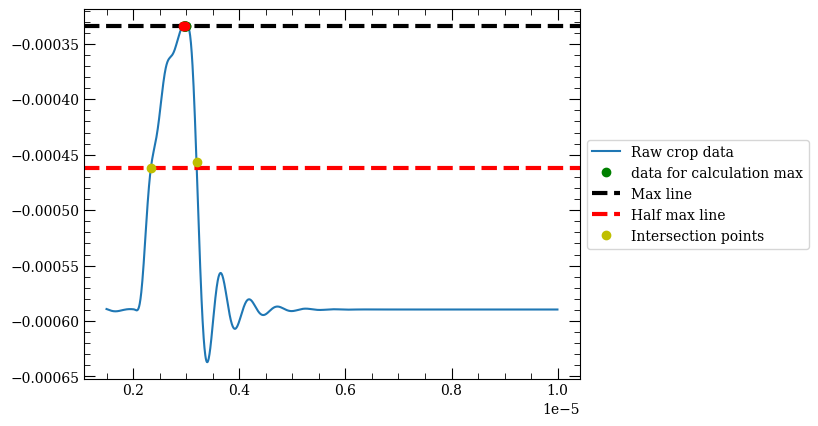

half_max =  -0.0004586243755275081
full width at half_max =  1.8500000000000005e-06


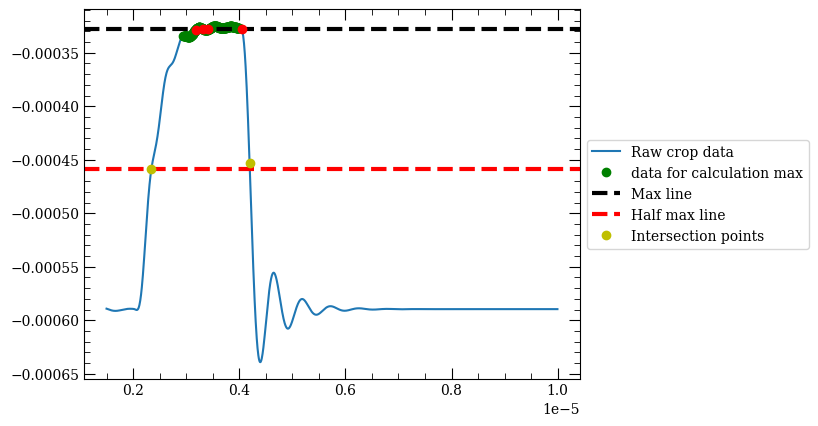

half_max =  -0.0004586243755275081
full width at half_max =  1.8500000000000005e-06


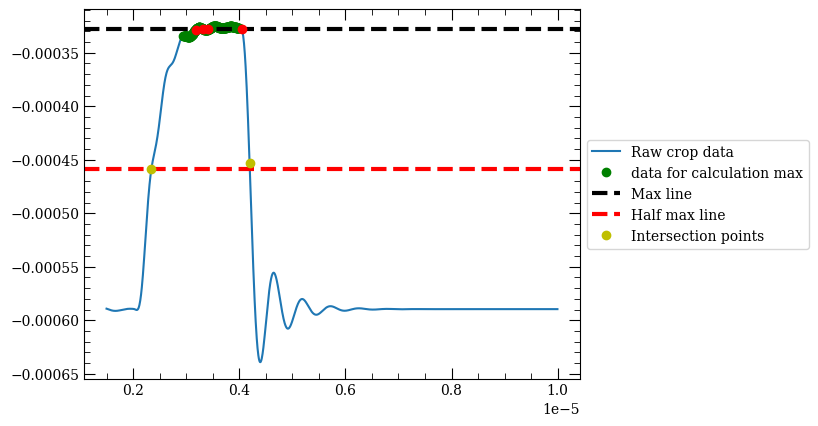

half_max =  -0.00045816525153639183
full width at half_max =  2.8500000000000002e-06


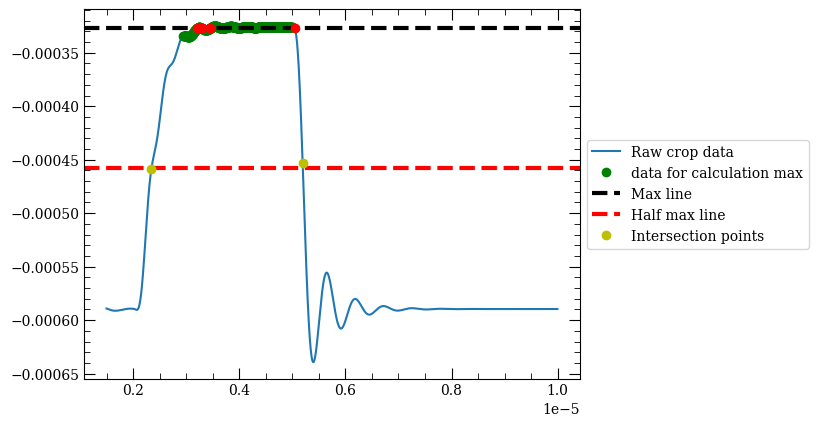

half_max =  -0.00045816525153639183
full width at half_max =  2.8500000000000002e-06


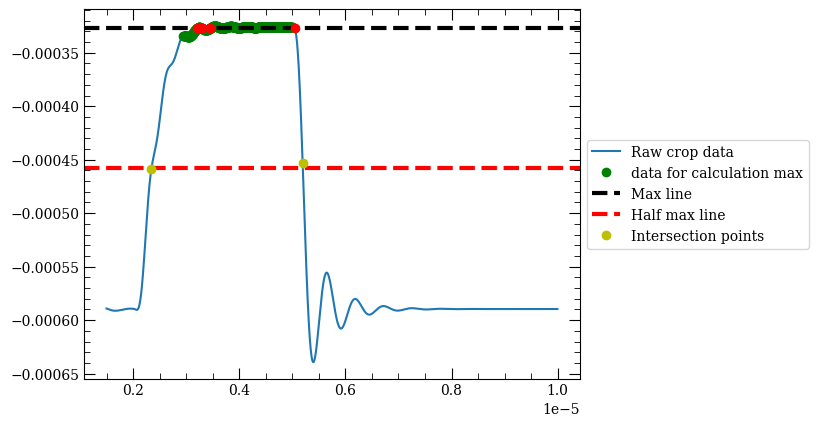

half_max =  -0.0004580084057627108
full width at half_max =  3.85e-06


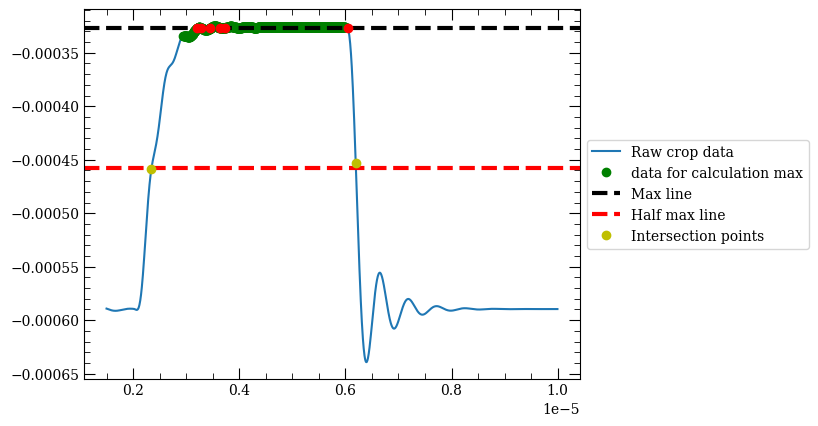

half_max =  -0.0004580084057627108
full width at half_max =  3.85e-06


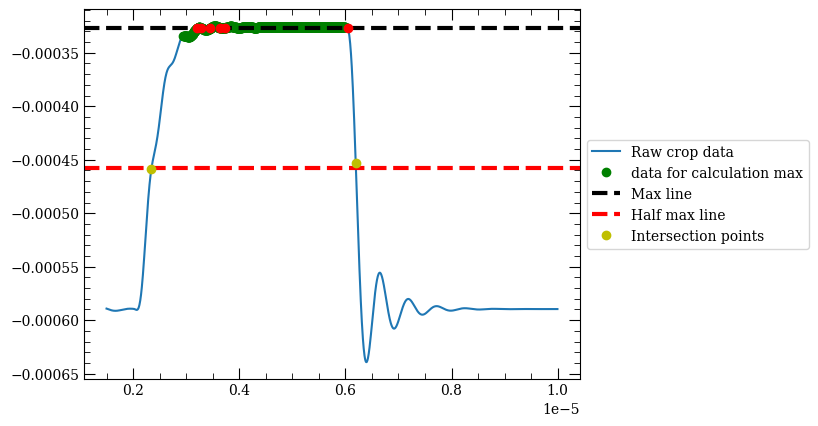

half_max =  -0.0004579294952848893
full width at half_max =  4.850000000000001e-06


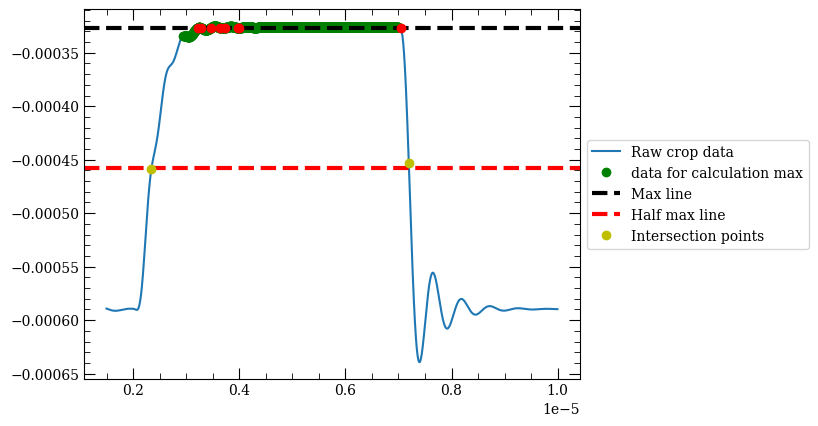

half_max =  -0.0004579294952848893
full width at half_max =  4.850000000000001e-06


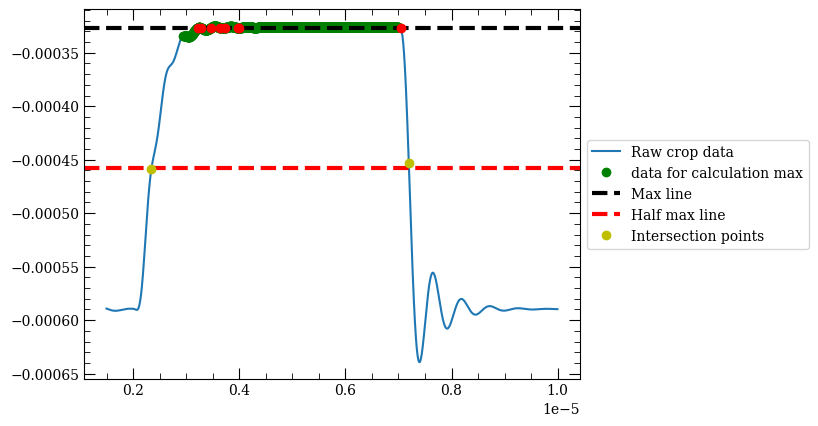

In [139]:
off_resonance_result_FWM = []
for i in range(1,len(data_sim_time_off_array)):   
    measure_FWM_array(data_sim_time_off_array,i,300,2000,590,600+200*(i-1))
    off_resonance_result_FWM.append(measure_FWM_array(data_sim_time_off_array,i,300,2000,590,600+200*(i-1)))

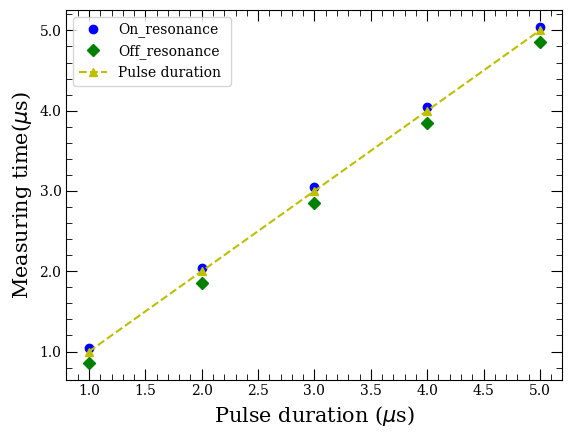

In [141]:
plt.plot(np.array(t_sim[1:6])*1e6,np.array(on_resonance_result)*1e6,'bo',label= 'On_resonance')  
y =  np.array(t_sim[1:6])*1e6
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: '{:.1f}'.format(y)))
plt.plot(np.array(t_sim[1:6])*1e6,np.array(off_resonance_result_FWM)*1e6,'gD',label= 'Off_resonance')  
plt.plot(np.array(t_sim[1:6])*1e6,np.array(t_sim[1:6])*1e6,'--y^',label= 'Pulse duration ') 
plt.xlabel("Pulse duration "+"($\mu$s)", fontdict = font2) 
plt.ylabel("Measuring time"+"($\mu$s)", fontdict = font2)
plt.legend()  
plt.show() 

# 28/5/ compare rabi oscillation of on resonance and off resonance

In [118]:
print("probing at (MHz) ",dc[60]/1e6)

probing at (MHz)  10.0


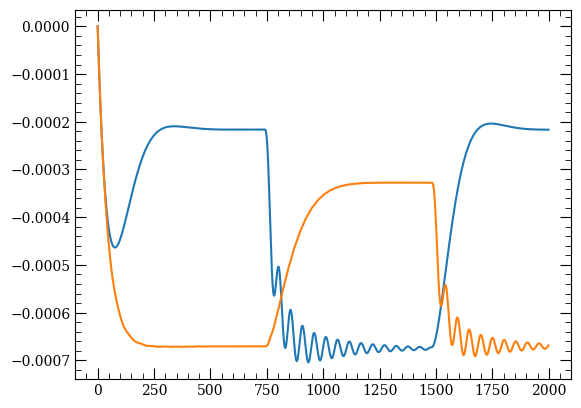

NameError: name 'tlist_40' is not defined

In [119]:
plt.plot(data_sim_array[:,100]) 
plt.plot(data_sim_array[:,120]) 
plt.show() 
plt.plot(tlist_40,data_sim_array[:,100]) 
plt.plot(tlist_40,data_sim_array[:,120]) 

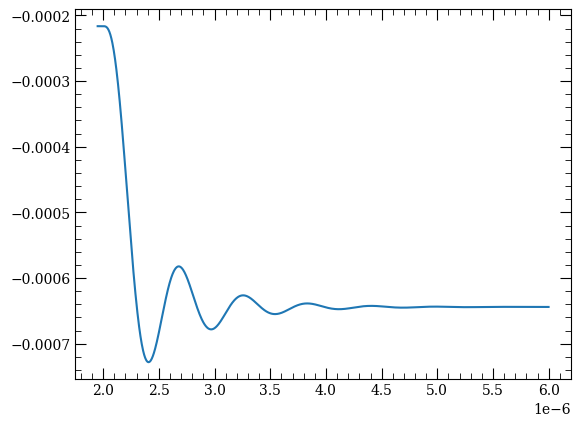

In [981]:
data_on_reso = data_sim_array[:,100][650:2000]

plt.plot(tlist_40[650:2000],data_sim_array[:,100][650:2000])  

[[Model]]
    (Model(linear, prefix='bkg') + Model(damped_oscillator, prefix='do1_'))
[[Fit Statistics]]
    # fitting method   = leastsq
    # function evals   = 388
    # data points      = 950
    # variables        = 6
    chi-square         = 2.23458609
    reduced chi-square = 0.00236715
    Akaike info crit   = -5737.78567
    Bayesian info crit = -5708.64690
    R-squared          = 0.96305022
[[Variables]]
    bkgslope:     -0.03425803 +/- 0.00203961 (5.95%) (init = 1)
    bkgintercept: -6.29709271 +/- 0.00777888 (0.12%) (init = 0)
    do1_a0:       -100.221508 +/- 6.49337622 (6.48%) (init = 3)
    do1_tau:       0.51707067 +/- 0.00671160 (1.30%) (init = 5)
    do1_omega:     11.5112583 +/- 0.02131226 (0.19%) (init = 30)
    do1_phi:       42.7082966 +/- 0.05315080 (0.12%) (init = 0)
[[Correlations]] (unreported correlations are < 0.100)
    C(do1_a0, do1_tau)         = +0.9951
    C(do1_omega, do1_phi)      = -0.9948
    C(bkgslope, bkgintercept)  = -0.9783
    C(bkgintercept

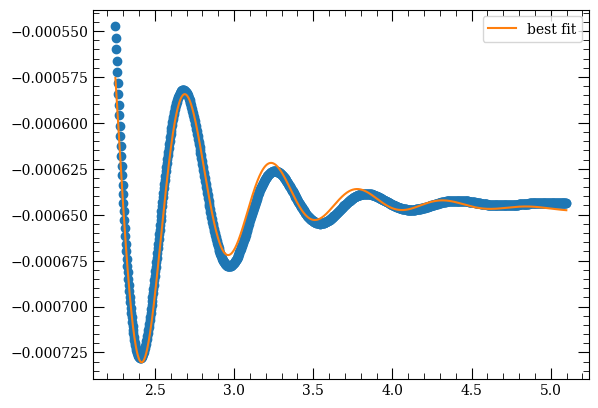

On - resonance rabi - freq (MHz) 11.511258298279651
error rabi - freq (MHz) 0.021312263051288503


In [982]:
# This code will fit the oscilation of subtraced curve 
def damped_oscillator(x, a0, tau, omega, phi):
    return a0 * np.exp(-x/tau) * np.sin(omega*x + phi) 

t_fit = tlist_40[750:1700]*1e6  
data_on_reso = data_sim_array[:,100][750:1700]
yval = data_on_reso*1e4
damped_model =LinearModel(prefix='bkg') + Model(damped_oscillator,prefix='do1_') 
params = damped_model.make_params(bkg_offset=-7, bkg_slope=0,
                           do1_a0 =3,
                           do1_tau = 5,
                           do1_omega = 30,
                           do1_phi = 0 )
damp_result = damped_model.fit(yval, params, x=t_fit)  
# the multiply value of 1e4 in cropped_dat and 10 in t_fit are used to scale the x and y axis for optimize the base , amp and tau of function 
print(damp_result.fit_report())

plt.plot(t_fit, data_on_reso, 'o')
#plt.plot(t_fit, damp_result.init_fit/1e4, '--', label='initial fit')
plt.plot(t_fit, damp_result.best_fit/1e4, '-', label='best fit')
plt.legend()
plt.show() 
print("On - resonance rabi - freq (MHz)",damp_result.params['do1_omega'].value) 
print("error rabi - freq (MHz)",damp_result.params['do1_omega'].stderr)

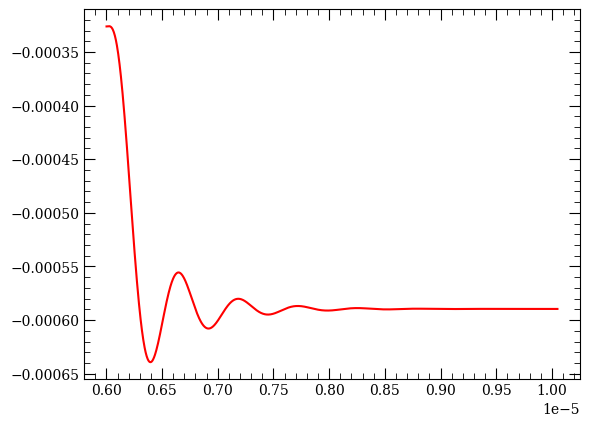

In [983]:
data_off_reso = data_sim_array[:,120][2000:3350]

plt.plot(tlist_40[2000:3350],data_sim_array[:,120][2000:3350],'r')  

[[Model]]
    (Model(linear, prefix='bkg') + Model(damped_oscillator, prefix='do1_'))
[[Fit Statistics]]
    # fitting method   = leastsq
    # function evals   = 464
    # data points      = 800
    # variables        = 6
    chi-square         = 1.4737e-04
    reduced chi-square = 1.8560e-07
    Akaike info crit   = -12393.7673
    Bayesian info crit = -12365.6596
    R-squared          = 0.99993021
[[Variables]]
    bkgslope:      0.00103028 +/- 2.3992e-05 (2.33%) (init = 1)
    bkgintercept: -5.90494934 +/- 1.9295e-04 (0.00%) (init = 0)
    do1_a0:        2081596.21 +/- 21174.2375 (1.02%) (init = 3)
    do1_tau:       0.42594938 +/- 2.6256e-04 (0.06%) (init = 5)
    do1_omega:     11.7563380 +/- 0.00121168 (0.01%) (init = 30)
    do1_phi:       124.260698 +/- 0.00841494 (0.01%) (init = 0)
[[Correlations]] (unreported correlations are < 0.100)
    C(do1_omega, do1_phi)      = -0.9996
    C(do1_a0, do1_tau)         = -0.9996
    C(bkgslope, bkgintercept)  = -0.9967
    C(bkgintercept

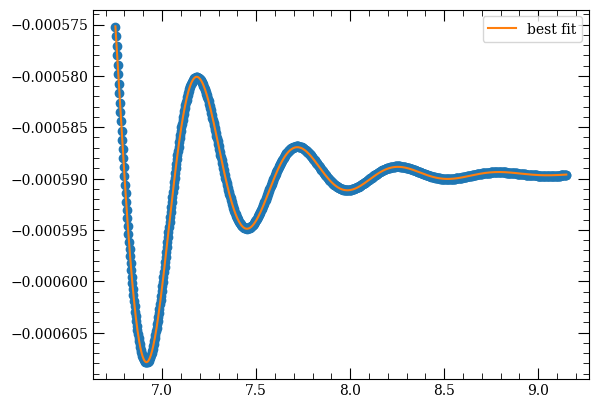

Off - resonance rabi - freq (MHz) 11.756338006682178
error rabi - freq (MHz) 0.0012116833257890484


In [984]:
# This code will fit the oscilation of subtraced curve 
def damped_oscillator(x, a0, tau, omega, phi):
    return a0 * np.exp(-x/tau) * np.sin(omega*x + phi) 

t_fit = tlist_40[2250:3050]*1e6  
data_off_reso = data_sim_array[:,120][2250:3050]
yval = data_off_reso*1e4
damped_model =LinearModel(prefix='bkg') + Model(damped_oscillator,prefix='do1_') 
params = damped_model.make_params(bkg_offset=-7, bkg_slope=0,
                           do1_a0 =3,
                           do1_tau = 5,
                           do1_omega = 30,
                           do1_phi = 0 )
damp_result = damped_model.fit(yval, params, x=t_fit)  
# the multiply value of 1e4 in cropped_dat and 10 in t_fit are used to scale the x and y axis for optimize the base , amp and tau of function 
print(damp_result.fit_report())

plt.plot(t_fit, data_off_reso, 'o')
#plt.plot(t_fit, damp_result.init_fit/1e4, '--', label='initial fit')
plt.plot(t_fit, damp_result.best_fit/1e4, '-', label='best fit')
plt.legend()
plt.show() 
print("Off - resonance rabi - freq (MHz)",damp_result.params['do1_omega'].value) 
print("error rabi - freq (MHz)",damp_result.params['do1_omega'].stderr)

# Parameter adjust

# vary Omega_RF

In [27]:
def H1_coeff(tlist, args): 
    A = args['A'] 
    R = args['R']
    return A*(1-signal.square(2*pi*0.45*0.4E6 * tlist , duty=R)) 
    #return 9*1e6

TypeError: only length-1 arrays can be converted to Python scalars

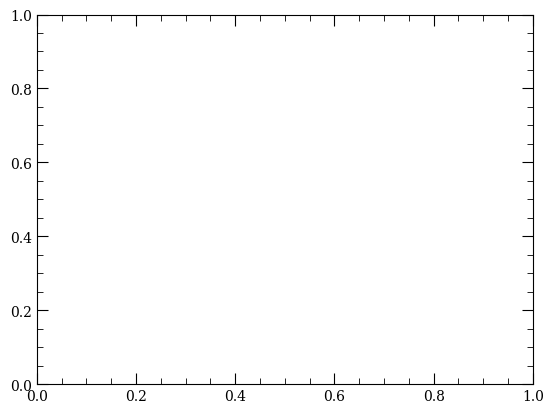

In [183]:

psi0=basis(4,0)

pressure = pressure_Rb85(temperature)
N_0 = atomdensity(pressure, temperature)
dp = np.linspace(-100.e6, 100.e6, 201)
dc = np.linspace(-200.e6, 200.e6, 201)
dp = np.array([0])
# print(dp)
rabi12 = 0.3e6 
rabi23 = 30e6 
#rabi34 = 0

delta12=0
delta23=0
delta34=0

Rabi12 = np.linspace(0, 50.e6, 6)
Rabi23 = np.linspace(0, 100.e6, 5)
Rabi34 = np.linspace(0, 20.e6, 5)

fig, ax = plt.subplots()
for rabi34 in Rabi34:
# for rabi23 in Rabi23:
# for rabi34 in Rabi34:
    Rabifreq = [rabi12,rabi23,rabi34]
    #print(Rabifreq)
    res = []
    for delta23 in dc[95:105]:
    # for delta23 in dc:    
        delta = [delta12,delta23,delta34]
        H0 = 1/2*Qobj(Hdiag(delta) + Hoff(Rabifreq))  
        H1 = (rho[2][3].dag() + rho[2][3])
        H = [H0,[H1,H1_coeff_list]]  
        #print(rabi34)
        #print(H)
        # result = steadystate(H, c_op_list)
        result = mesolve(H, psi0, tlist, c_op_list,rho[0][1].dag(), args={'A': rabi34 ,'R':0.50})
        
        res.append(result.expect)
    # print(H)   
    # print(c_op_list)
    # print(rabi34)
    # print(res)
    # print(np.imag(res))
    Efield = E_from_Rabi(rabi12,abs(dipmat12))
    # print()
    # chi = [susceptibility(N_0,np.abs(dipmat12),Efield,rho) for rho in res]

    # # print(np.imag(chi))
    # transmittance = [transmission(L,np.imag(i),lambda12) for i in chi]
    # refraction = np.real(chi)
    # absorption = 2*pi*np.imag(chi)/lambda12
    # print(np.imag(chi)[0])
    # # print(absorption)
    # # ax.plot(dp, res) 
    # # ax.plot(dp,res, label=omegaRF*1e-6)
    # # ax.plot(dp,transmission, label=rabi34*1e-6)
    # # ax.plot(dp,transmission, label=rabi12*1e-6)
    # # ax.plot(dp,transmittance, label=str(round(rabi12*1e-6,0))+'MHz')

    # # ax.plot(dp,refraction, label=rabi23*1e-6)
    ax.plot(tlist,-1*np.imag(res[0][0]), label=str(round(rabi34*1e-6,0))+'MHz') # for rho[0][1]
    # ax.plot(tlist,np.real(res[0][0]), label=str(round(rabi12*1e-6,0))+'MHz') # for rho[0][0]
    #print(res)

    # ax.plot(times, result.expect[1]) 
ax.set_xlabel('Time (s)') 
ax.set_ylabel('-Im[$\chi$]') 
# ax.legend(("Sigma-Z", "Sigma-Y"))  
ax.legend()
# plt.suptitle('EIT, vary $\Omega_{RF}$')
plt.suptitle('EIT, vary $\Omega_{RF}$')
#plt.ylim(-0.05,0.08)
plt.show()
#print(H) 
#print(Rabifreq)
#print(delta)
#print(res[0])

In [ ]:
dc[95:105]

array([-10000000.,  -8000000.,  -6000000.,  -4000000.,  -2000000.,
               0.,   2000000.,   4000000.,   6000000.,   8000000.])

(4e-06, 6e-06)

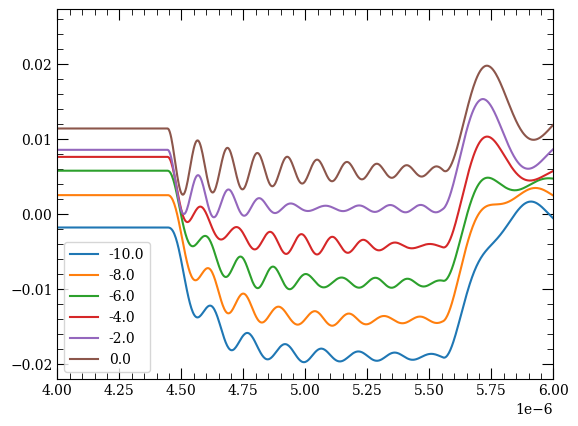

In [ ]:
for i in range(len(dc[95:101])):
    plt.plot(tlist,-1*np.imag(res[i][0])+0.005*i, label=dc[95:105][i]*1e-6) 
plt.legend()
plt.xlim(4e-6,6e-6)

# check for time steady state

In [ ]:
tlist = np.linspace(0.0, 9E-6 , 3000)

In [ ]:
rabi12 = 0.3e6 
rabi23 = 30e6 
rabi34 = 0
# for rabi23 in Rabi23:
# for rabi34 in Rabi34:
Rabifreq = [rabi12,rabi23,rabi34]
    #print(Rabifreq)
res_split = [] 
chi_list = []
    #for delta12 in dp:
for delta23 in dc:    
    delta = [delta12,delta23,delta34]
    H0 = 1/2*Qobj(Hdiag(delta) + Hoff(Rabifreq))  
    H1 = (rho[2][3].dag() + rho[2][3])
    H = [H0,[H1,H1_coeff]] 
    print(H)
        
    # result = steadystate(H, c_op_list)
    result = mesolve(H, psi0, tlist, c_op_list,rho[0][1].dag(),args={'A': 23e6 })
        
    res_split.append(result.expect)
    # print(H)   
    # print(c_op_list)
    # print(rabi34)
    print(res_split[0][0])
    # print(np.imag(res))
    Efield = E_from_Rabi(rabi12,abs(dipmat12))
    # print()
    #chi = [susceptibility(N_0,np.abs(dipmat12),Efield,rho) for rho in res[0]]
    # # print(np.imag(chi))
    # transmittance = [transmission(L,np.imag(i),lambda12) for i in chi]
    # refraction = np.real(chi)
    # absorption = 2*pi*np.imag(chi)/lambda12
    # print(np.imag(chi)[0])
    # # print(absorption)
    # # ax.plot(dp, res) 
    # # ax.plot(dp,res, label=omegaRF*1e-6)
    # # ax.plot(dp,transmission, label=rabi34*1e-6)
    # # ax.plot(dp,transmission, label=rabi12*1e-6)
    # # ax.plot(dp,transmittance, label=str(round(rabi12*1e-6,0))+'MHz')

    # # ax.plot(dp,refraction, label=rabi23*1e-6)
ax.plot(tlist,res_split[2][0], label=str(round(rabi12*1e-6,0))+'MHz') # for rho[0][1]
    # ax.plot(tlist,np.real(res[0][0]), label=str(round(rabi12*1e-6,0))+'MHz') # for rho[0][0]
    #print(res)

# ax.plot(times, result.expect[1]) 
ax.set_xlabel('Time (s)') 
ax.set_ylabel('Im[$\chi$]') 
# ax.legend(("Sigma-Z", "Sigma-Y"))  
ax.legend()
# plt.suptitle('EIT, vary $\Omega_{RF}$')
plt.suptitle('EIT, vary $\Omega_{p}$')
# plt.ylim(-0.0007,-0.0006)
plt.show()
#print(H) 
#print(Rabifreq)
#print(delta)
#print(res[0])

[Quantum object: dims = [[4], [4]], shape = (4, 4), type = oper, isherm = True
Qobj data =
[[0.0e+00 1.5e+05 0.0e+00 0.0e+00]
 [1.5e+05 0.0e+00 1.5e+07 0.0e+00]
 [0.0e+00 1.5e+07 2.0e+08 0.0e+00]
 [0.0e+00 0.0e+00 0.0e+00 2.0e+08]], [Quantum object: dims = [[4], [4]], shape = (4, 4), type = oper, isherm = True
Qobj data =
[[0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 1.]
 [0. 0. 1. 0.]], <function H1_coeff at 0x00000228A5E6D3F0>]]
[0.00000000e+00+0.j         2.29321613e-08+0.00044492j
 3.41258958e-07+0.00087902j ... 2.85432137e-03+0.01926076j
 2.85432944e-03+0.01926076j 2.85433242e-03+0.01926077j]
[Quantum object: dims = [[4], [4]], shape = (4, 4), type = oper, isherm = True
Qobj data =
[[0.00e+00 1.50e+05 0.00e+00 0.00e+00]
 [1.50e+05 0.00e+00 1.50e+07 0.00e+00]
 [0.00e+00 1.50e+07 1.98e+08 0.00e+00]
 [0.00e+00 0.00e+00 0.00e+00 1.98e+08]], [Quantum object: dims = [[4], [4]], shape = (4, 4), type = oper, isherm = True
Qobj data =
[[0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 1.]
 [0. 0. 1. 0.]]

<Figure size 640x480 with 0 Axes>

(4.5e-06, 8e-06)

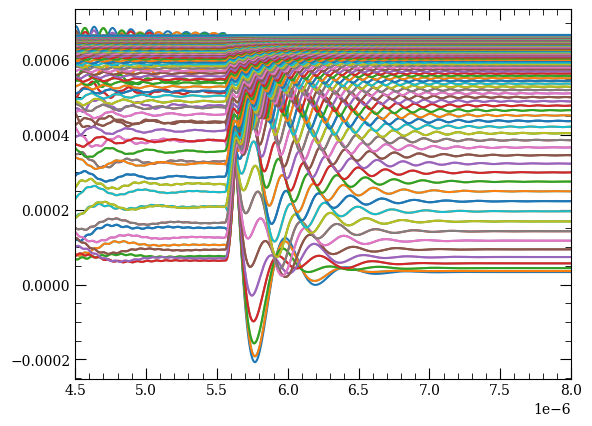

In [ ]:
Efield = E_from_Rabi(rabi12,abs(dipmat12)) 
chi_list = []
for i in range(len(dc)):  
    chi = [susceptibility(N_0,np.abs(dipmat12),Efield,rho) for rho in res_split[i][0]] 
    chi_list.append(chi)
    plt.plot(tlist,np.imag(chi)) 
plt.xlim(4.5E-6,8E-6)

In [ ]:
peak_split =np.array([[chi_list[i][j] for i in range(len(dc))] for j in range(len(tlist)-1,-1,-1)])

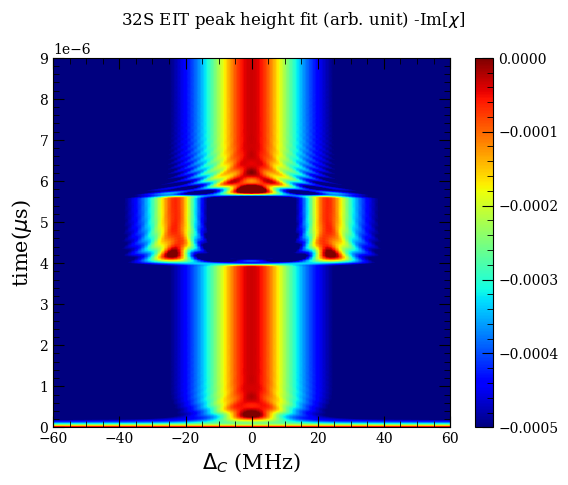

In [ ]:
plt.imshow(-1*np.imag(peak_split),vmin=-0.0005,origin='upper', extent=[-100,100,tlist[0],tlist[-1]], vmax=0.0000, cmap='jet', aspect='auto')  
font1 = {'family':'serif','color':'black','size':20}
font2 = {'family':'serif','color':'black','size':15}
plt.suptitle('32S EIT peak height fit (arb. unit) '+"-Im[$\chi$]", fontdict = font1)
plt.xlabel("$\Delta_C$"+" (MHz)", fontdict = font2) 
plt.xlim(-60,60)
plt.ylabel("time"+"($\mu$s)", fontdict = font2) 
#plt.ylim(3.8e-6,4.2e-6)
plt.colorbar()

In [ ]:
np.where( tlist > 4.00e-6)

(array([1333, 1334, 1335, ..., 2997, 2998, 2999], dtype=int64),)

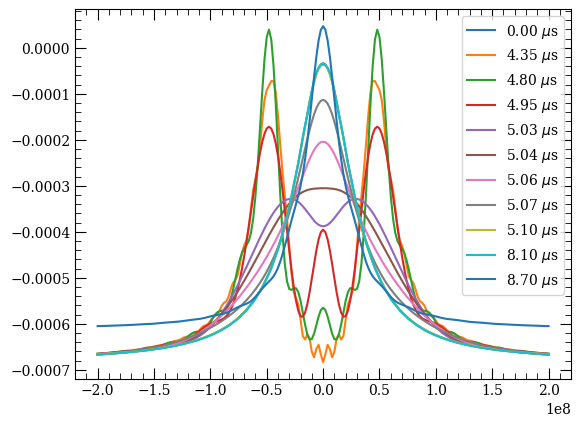

In [ ]:
t_test =np.array([0,1450,1600,1650,1675,1680,1685,1690,1700,2700,2900])  
chi_test = []
for t in t_test: 
    t_stamp = tlist[t]*1e6 
    chi_test.append(-1*np.imag(peak_split[t]))
    plt.plot(dc,-1*np.imag(peak_split[t]),label=str("%.2f" % t_stamp)+" $\mu$s")   
plt.legend()
plt.show() 

[[Model]]
    (Model(lorentzian, prefix='l1_') + Model(lorentzian, prefix='l2_'))
[[Fit Statistics]]
    # fitting method   = leastsq
    # function evals   = 245
    # data points      = 201
    # variables        = 6
    chi-square         = 30.7177429
    reduced chi-square = 0.15752689
    Akaike info crit   = -365.571359
    Bayesian info crit = -345.751530
    R-squared          = 0.94676372
[[Variables]]
    l1_amplitude:  288.099489 +/- 8.08481371 (2.81%) (init = 0.00166)
    l1_center:    -48.9184677 +/- 0.40027688 (0.82%) (init = -20)
    l1_sigma:      14.9506492 +/- 0.58451429 (3.91%) (init = 3.15)
    l2_amplitude:  288.098300 +/- 8.08492211 (2.81%) (init = 0.00166)
    l2_center:     48.9185609 +/- 0.40028698 (0.82%) (init = -20)
    l2_sigma:      14.9505479 +/- 0.58452924 (3.91%) (init = 3.15)
    l1_fwhm:       29.9012983 +/- 1.16902857 (3.91%) == '2.0000000*l1_sigma'
    l1_height:     6.13384199 +/- 0.16412717 (2.68%) == '0.3183099*l1_amplitude/max(1e-15, l1_sigma)'


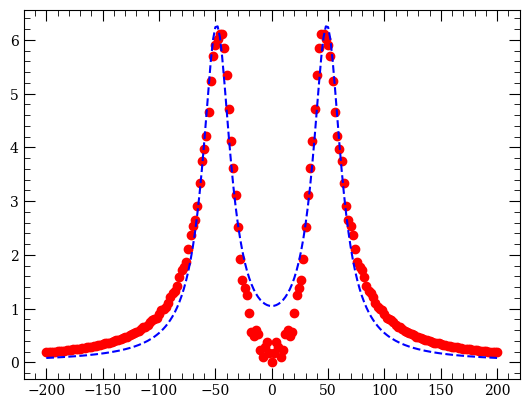

In [ ]:
from lmfit import Model
from lmfit.models import GaussianModel, ConstantModel ,LorentzianModel
import matplotlib.pyplot as plt

xval = dc/1e6
yval = (chi_test[1] -np.min(chi_test[1]))*10000
model = LorentzianModel(prefix='l1_') + LorentzianModel(prefix='l2_')
params = model.make_params() 
params.add('l1_amplitude',value=0.00166)
params.add('l1_center',value=-20)
params.add('l1_sigma',value=3.15)#,min=150,max=1500)  
params.add('l2_amplitude',value=0.00166)
params.add('l2_center',value=-20)
params.add('l2_sigma',value=3.15)#,min=150,max=1500) 
result = model.fit(yval,params=params,x=xval)

print(result.fit_report())

plt.plot(xval, yval, 'ro', ms=6)
plt.plot(xval, result.best_fit, 'b--')

In [ ]:
def split_fit(deltalist,chi): 
    xval = deltalist
    yval = (chi -np.min(chi))*10000
    model = LorentzianModel(prefix='l1_') + LorentzianModel(prefix='l2_')
    params = model.make_params() 
    params.add('l1_amplitude',value=0.00166)
    params.add('l1_center',value=-30)
    params.add('l1_sigma',value=3.15)#,min=150,max=1500)  
    params.add('l2_amplitude',value=0.00166)
    params.add('l2_center',value=30)
    params.add('l2_sigma',value=3.15)#,min=150,max=1500) 
    result = model.fit(yval,params=params,x=xval) 
    l1_cen = result.params['l1_center'].value 
    l2_cen = result.params['l2_center'].value 
    l1_sd = result.params['l1_center'].stderr 
    l2_sd = result.params['l2_center'].stderr
    return l1_cen,l2_cen,l1_sd,l2_sd

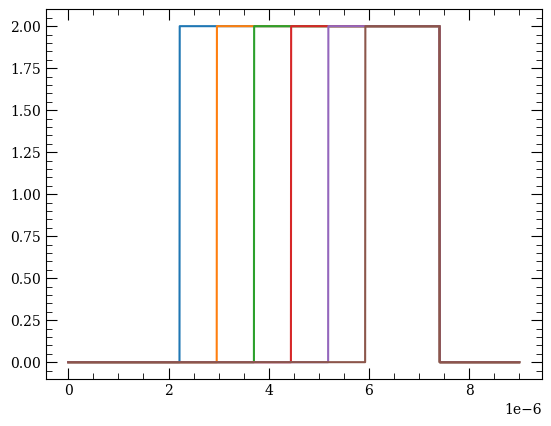

In [ ]:
#adjust code more global
duty_list = np.array([0.3,0.4,0.5,0.6,0.7,0.8])
for i in duty_list:
    t = np.linspace(0, 9E-6, 2000, endpoint=False)
    plt.plot(t,1-signal.square(2*pi*0.45*0.3E6 * t, duty=i))

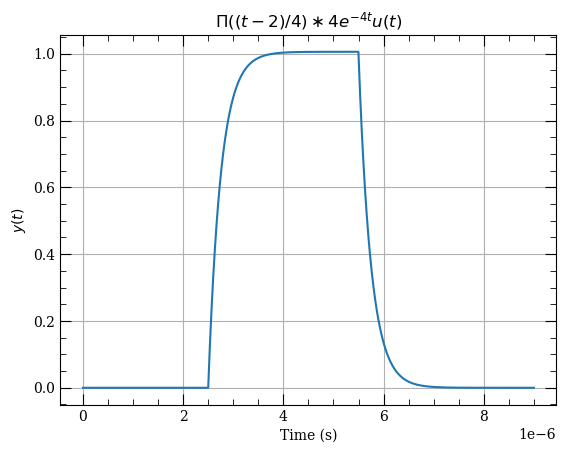

In [ ]:
# Consider a pulse convolved with an exponential ('r' type extent)
tx = np.linspace(0,9e-6,3000)
x = ss.rect(tx-4e-6,3e-6) # pulse starts at t = 0
h = 4*1e6*np.exp(-4*1e6*tx)*ss.step(tx)
y,ty = ss.conv_integral(x,tx,h,tx,extent=('f','r')) # note extents set
plt.plot(ty,y) # expect a pulse charge and discharge waveform
plt.grid()
plt.title(r'$\Pi((t-2)/4)\ast 4 e^{-4t} u(t)$')
plt.xlabel(r'Time (s)')
plt.ylabel(r'$y(t)$');

(array([0., 0., 0., ..., 0., 0., 0.]), array([0.00000000e+00, 3.00100033e-09, 6.00200067e-09, ...,
       8.99399800e-06, 8.99699900e-06, 9.00000000e-06]))
(array([-1.62178693e-17, -9.53992314e-19, -3.43437233e-17, ...,
        4.98409057e-09,  4.92461922e-09,  4.86585748e-09]), array([0.00000000e+00, 3.00100033e-09, 6.00200067e-09, ...,
       8.99399800e-06, 8.99699900e-06, 9.00000000e-06]))
(array([-6.10555081e-17, -3.05277540e-17, -1.22111016e-16, ...,
        1.53134657e-08,  1.51307417e-08,  1.49501981e-08]), array([0.00000000e+00, 3.00100033e-09, 6.00200067e-09, ...,
       8.99399800e-06, 8.99699900e-06, 9.00000000e-06]))
(array([ 3.05277540e-17, -6.10555081e-17, -3.05277540e-17, ...,
        4.21452964e-08,  4.16424085e-08,  4.11455213e-08]), array([0.00000000e+00, 3.00100033e-09, 6.00200067e-09, ...,
       8.99399800e-06, 8.99699900e-06, 9.00000000e-06]))
(array([-1.22111016e-16, -1.83166524e-16, -1.22111016e-16, ...,
        1.15769688e-07,  1.14388296e-07,  1.13023388e-07]

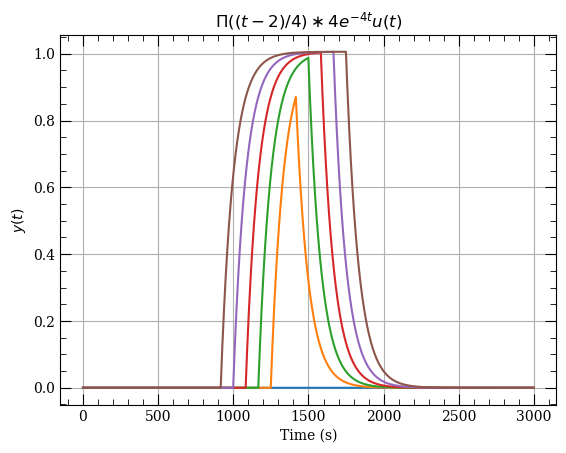

In [ ]:
step = np.array([0.5*i for i in range(6)]) 
for i in step: 
    x = ss.rect(tx-4e-6,i*1e-6) # pulse starts at t = 0
    h = 4*1e6*np.exp(-4*1e6*tx)*ss.step(tx)
    y,ty = ss.conv_integral(x,tx,h,tx,extent=('f','r')) # note extents set
    plt.plot(y) # expect a pulse charge and discharge waveform  
plt.grid()
plt.title(r'$\Pi((t-2)/4)\ast 4 e^{-4t} u(t)$')
plt.xlabel(r'Time (s)')
plt.ylabel(r'$y(t)$');

In [ ]:
def H1_time(tlist, args):  
    A = args['A']  
    R = args['R']
    x = ss.rect(tlist-4e-6,R*1e-6) # pulse starts at t = 0
    h = A*4*1e6*np.exp(-4*1e6*tlist)*ss.step(tlist)
    #y,ty = ss.conv_integral(x,tlist,h,tlist,extent=('f','r'))
    return ss.conv_integral(x,tlist,h,tlist,extent=('f','r'))

Exception: ODE integration error: Try to increase the allowed number of substeps by increasing the nsteps parameter in the Options class.

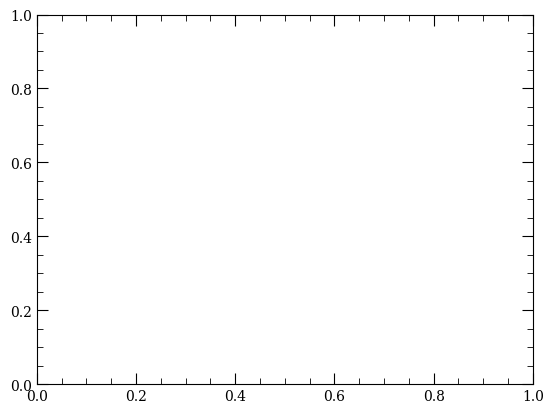

In [ ]:
dp = np.linspace(-100.e6, 100.e6, 201)
dc = np.linspace(-200.e6, 200.e6, 201)
dp = np.array([0])
# print(dp)
rabi12 = 0.3e6 
rabi23 = 30e6 
rabi34 = 20e6

delta12=0
delta23=0
delta34=0 
 
duty_list = np.array([0.3,0.4,0.5,0.6,0.7,0.8])
Rabi12 = np.linspace(0, 50.e6, 6)
Rabi23 = np.linspace(0, 100.e6, 5)
Rabi34 = np.linspace(0, 20.e6, 5)

fig, ax = plt.subplots()
for rat in duty_list:
# for rabi23 in Rabi23:
# for rabi34 in Rabi34:
    Rabifreq = [rabi12,rabi23,rabi34]
    #print(Rabifreq)
    res = []
    for delta23 in dc[95:105]:
    # for delta23 in dc:    
        delta = [delta12,delta23,delta34]
        H0 = 1/2*Qobj(Hdiag(delta) + Hoff(Rabifreq))  
        H1 = (rho[2][3].dag() + rho[2][3])
        H = [H0,[H1,H1_coeff]]  
        #print(rabi34)
        #print(H)
        # result = steadystate(H, c_op_list)
        result = mesolve(H, psi0, tlist, c_op_list,rho[0][1].dag(), args={'A': rabi34,'R' : rat})
        
        res.append(result.expect)
    # print(H)   
    # print(c_op_list)
    # print(rabi34)
    # print(res)
    # print(np.imag(res))
    Efield = E_from_Rabi(rabi12,abs(dipmat12))
    # print()
    # chi = [susceptibility(N_0,np.abs(dipmat12),Efield,rho) for rho in res]

    # # print(np.imag(chi))
    # transmittance = [transmission(L,np.imag(i),lambda12) for i in chi]
    # refraction = np.real(chi)
    # absorption = 2*pi*np.imag(chi)/lambda12
    # print(np.imag(chi)[0])
    # # print(absorption)
    # # ax.plot(dp, res) 
    # # ax.plot(dp,res, label=omegaRF*1e-6)
    # # ax.plot(dp,transmission, label=rabi34*1e-6)
    # # ax.plot(dp,transmission, label=rabi12*1e-6)
    # # ax.plot(dp,transmittance, label=str(round(rabi12*1e-6,0))+'MHz')

    # # ax.plot(dp,refraction, label=rabi23*1e-6)
    ax.plot(tlist,-1*np.imag(res[0][0]), label=str(round(rabi34*1e-6,0))+'MHz') # for rho[0][1]
    # ax.plot(tlist,np.real(res[0][0]), label=str(round(rabi12*1e-6,0))+'MHz') # for rho[0][0]
    #print(res)

    # ax.plot(times, result.expect[1]) 
ax.set_xlabel('Time (s)') 
ax.set_ylabel('Im[$\chi$]') 
# ax.legend(("Sigma-Z", "Sigma-Y"))  
ax.legend()
# plt.suptitle('EIT, vary $\Omega_{RF}$')
plt.suptitle('EIT, vary $\Omega_{RF}$')
#plt.ylim(-0.05,0.08)
plt.show()
#print(H) 
#print(Rabifreq)
#print(delta)
#print(res[0])

In [ ]:
amu = 1.66e-27
mass = 85.4678*amu
u = sqrt(2*Boltzmann*temperature/mass)
u = round(u, 0);u  
v_list = np.linspace(-u/2,u/2,245)

In [ ]:
delta12=0
delta23=0
delta34=0 
delta12 = delta12 + 2*pi*v_list/lambda_trans[0]
delta23 = delta23 - 2*pi*v_list/lambda_trans[1]  
delta34 = delta34 - 2*pi*v_list/lambda_trans[2];delta23

array([ 1.57698656e+09,  1.56406044e+09,  1.55113432e+09,  1.53820820e+09,
        1.52528208e+09,  1.51235596e+09,  1.49942984e+09,  1.48650372e+09,
        1.47357760e+09,  1.46065149e+09,  1.44772537e+09,  1.43479925e+09,
        1.42187313e+09,  1.40894701e+09,  1.39602089e+09,  1.38309477e+09,
        1.37016865e+09,  1.35724253e+09,  1.34431641e+09,  1.33139029e+09,
        1.31846417e+09,  1.30553805e+09,  1.29261193e+09,  1.27968581e+09,
        1.26675970e+09,  1.25383358e+09,  1.24090746e+09,  1.22798134e+09,
        1.21505522e+09,  1.20212910e+09,  1.18920298e+09,  1.17627686e+09,
        1.16335074e+09,  1.15042462e+09,  1.13749850e+09,  1.12457238e+09,
        1.11164626e+09,  1.09872014e+09,  1.08579402e+09,  1.07286791e+09,
        1.05994179e+09,  1.04701567e+09,  1.03408955e+09,  1.02116343e+09,
        1.00823731e+09,  9.95311189e+08,  9.82385070e+08,  9.69458950e+08,
        9.56532831e+08,  9.43606712e+08,  9.30680592e+08,  9.17754473e+08,
        9.04828354e+08,  

In [ ]:
dc[50:150]

array([-1.0e+08, -9.8e+07, -9.6e+07, -9.4e+07, -9.2e+07, -9.0e+07,
       -8.8e+07, -8.6e+07, -8.4e+07, -8.2e+07, -8.0e+07, -7.8e+07,
       -7.6e+07, -7.4e+07, -7.2e+07, -7.0e+07, -6.8e+07, -6.6e+07,
       -6.4e+07, -6.2e+07, -6.0e+07, -5.8e+07, -5.6e+07, -5.4e+07,
       -5.2e+07, -5.0e+07, -4.8e+07, -4.6e+07, -4.4e+07, -4.2e+07,
       -4.0e+07, -3.8e+07, -3.6e+07, -3.4e+07, -3.2e+07, -3.0e+07,
       -2.8e+07, -2.6e+07, -2.4e+07, -2.2e+07, -2.0e+07, -1.8e+07,
       -1.6e+07, -1.4e+07, -1.2e+07, -1.0e+07, -8.0e+06, -6.0e+06,
       -4.0e+06, -2.0e+06,  0.0e+00,  2.0e+06,  4.0e+06,  6.0e+06,
        8.0e+06,  1.0e+07,  1.2e+07,  1.4e+07,  1.6e+07,  1.8e+07,
        2.0e+07,  2.2e+07,  2.4e+07,  2.6e+07,  2.8e+07,  3.0e+07,
        3.2e+07,  3.4e+07,  3.6e+07,  3.8e+07,  4.0e+07,  4.2e+07,
        4.4e+07,  4.6e+07,  4.8e+07,  5.0e+07,  5.2e+07,  5.4e+07,
        5.6e+07,  5.8e+07,  6.0e+07,  6.2e+07,  6.4e+07,  6.6e+07,
        6.8e+07,  7.0e+07,  7.2e+07,  7.4e+07,  7.6e+07,  7.8e

  6%|▌         | 6/100 [00:05<01:29,  1.05it/s]


KeyboardInterrupt: 

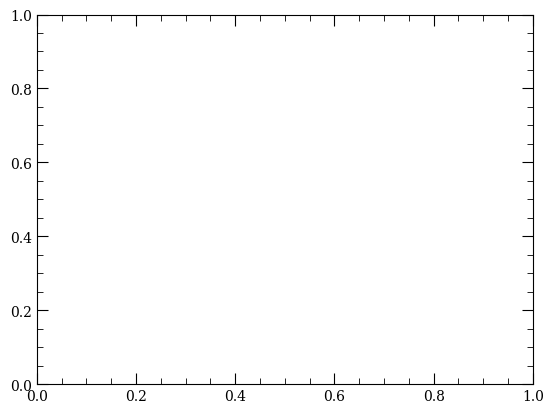

In [ ]:
psi0=basis(4,0)

pressure = pressure_Rb85(temperature)
N_0 = atomdensity(pressure, temperature)
dp = np.linspace(-100.e6, 100.e6, 201)
dc = np.linspace(-100.e6, 100.e6, 201)
dp = np.array([0])
# print(dp)
rabi12 = 0.3e6 
rabi23 = 30e6 
rabi34 = 20e6

delta12=0
delta23=0
delta34=0  
delta12 = delta12 + 2*pi*v_list/lambda_trans[0]
#delta23 = delta23 - 2*pi*v_list/lambda_trans[1]  
delta34 = delta34 - 2*pi*v_list/lambda_trans[2]
 
#duty_list = np.array([0.3,0.4,0.5,0.6,0.7,0.8])
Rabi12 = np.linspace(0, 50.e6, 6)
Rabi23 = np.linspace(0, 100.e6, 5)
Rabi34 = np.linspace(0, 20.e6, 5)

fig, ax = plt.subplots() 
res_v = []
for v in range(len(v_list)):
# for rabi23 in Rabi23:
# for rabi34 in Rabi34:
    Rabifreq = [rabi12,rabi23,rabi34]
    #print(Rabifreq)
    res = []
    for delta23 in tqdm(dc[50:150]):
    # for delta23 in dc:          
        delta23 = delta23 - 2*pi*v_list[v]/lambda_trans[1]
        delta = [delta12[v],delta12[v] + delta23,delta12[v] + delta23 + delta34[v]]
        H0 = 1/2*Qobj(Hdiag(delta) + Hoff(Rabifreq))  
        H1 = (rho[2][3].dag() + rho[2][3])
        H = [H0,[H1,H1_coeff]]  
        #print(rabi34)
        #print(H)
        # result = steadystate(H, c_op_list)
        result = mesolve(H, psi0, tlist, c_op_list,rho[0][1].dag(), args={'A': rabi34,'R' : 0.3})
        
        res.append(result.expect)
    # print(H)   
    # print(c_op_list)
    # print(rabi34)
    # print(res)
    # print(np.imag(res)) 
    res_v.append(res)

    #Efield = E_from_Rabi(rabi12,abs(dipmat12))
    # print()
    # chi = [susceptibility(N_0,np.abs(dipmat12),Efield,rho) for rho in res]

    # # print(np.imag(chi))
    # transmittance = [transmission(L,np.imag(i),lambda12) for i in chi]
    # refraction = np.real(chi)
    # absorption = 2*pi*np.imag(chi)/lambda12
    # print(np.imag(chi)[0])
    # # print(absorption)
    # # ax.plot(dp, res) 
    # # ax.plot(dp,res, label=omegaRF*1e-6)
    # # ax.plot(dp,transmission, label=rabi34*1e-6)
    # # ax.plot(dp,transmission, label=rabi12*1e-6)
    # # ax.plot(dp,transmittance, label=str(round(rabi12*1e-6,0))+'MHz')

    # # ax.plot(dp,refraction, label=rabi23*1e-6)
    #ax.plot(tlist,-1*np.imag(res[0][0]), label=str(round(rabi34*1e-6,0))+'MHz') # for rho[0][1]
    # ax.plot(tlist,np.real(res[0][0]), label=str(round(rabi12*1e-6,0))+'MHz') # for rho[0][0]
    #print(res)

    # ax.plot(times, result.expect[1]) 
ax.set_xlabel('Time (s)') 
ax.set_ylabel('Im[$\chi$]') 
# ax.legend(("Sigma-Z", "Sigma-Y"))  
ax.legend()
# plt.suptitle('EIT, vary $\Omega_{RF}$')
plt.suptitle('EIT, vary $\Omega_{RF}$')
#plt.ylim(-0.05,0.08)
plt.show()
#print(H) 
#print(Rabifreq)
#print(delta)
#print(res[0])

In [ ]:
psi0=basis(4,0)

pressure = pressure_Rb85(temperature)
N_0 = atomdensity(pressure, temperature)
dp = np.linspace(-100.e6, 100.e6, 201)
dc = np.linspace(-100.e6, 100.e6, 201)
dp = np.array([0])
# print(dp)
rabi12 = 0.3e6 
rabi23 = 30e6 
rabi34 = 20e6

delta12=0
delta23=0
delta34=0  
delta12 = delta12 + 2*pi*v_list/lambda_trans[0]
delta23_v = [dc + 2*pi*v/lambda_trans[1] for v in v_list]
delta34 = delta34 - 2*pi*v_list/lambda_trans[2]
 
#duty_list = np.array([0.3,0.4,0.5,0.6,0.7,0.8])
Rabi12 = np.linspace(0, 50.e6, 6)
Rabi23 = np.linspace(0, 100.e6, 5)
Rabi34 = np.linspace(0, 20.e6, 5)
Rabifreq = [rabi12,rabi23,rabi34]
    #print(Rabifreq)  
v = 0
res = []
for delta23 in tqdm(dc): 
    delta12=0
    delta34=0 
    # for delta23 in dc:          
    #delta23 = delta23 - 2*pi*v_list[v]/lambda_trans[1]
    #delta = [delta12[v],delta12[v] + delta23,delta12[v] + delta23 + delta34[v]]  
    delta = [delta12,delta12 + delta23,delta12 + delta23 + delta34] 
    #delta = [delta12,delta23,delta34]
    H0 = 1/2*Qobj(Hdiag(delta) + Hoff(Rabifreq))  
    H1 = (rho[2][3].dag() + rho[2][3])
    H = [H0,[H1,H1_coeff]]  
    #print(rabi34)
    #print(H)
    # result = steadystate(H, c_op_list)
    result = mesolve(H, psi0, tlist, c_op_list,rho[0][1].dag(), args={'A': rabi34,'R' : 0.8})
        
    res.append(result.expect[0])

  0%|          | 0/201 [00:00<?, ?it/s]


Exception: ODE integration error: Try to increase the allowed number of substeps by increasing the nsteps parameter in the Options class.

In [ ]:
delta23_v = [dc + 2*pi*v/lambda_trans[1] for v in v_list] ;len(delta23_v)

245

In [ ]:
test = [] 
for i in range(len(res)): 
    test.append(res[i]) 
delta12 = delta12 + 2*pi*v_list/lambda_trans[0];len(delta12)

245

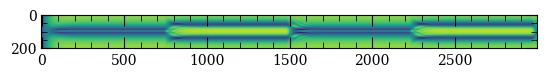

In [ ]:
plt.imshow(np.imag(test))

In [ ]:
import pandas as pd

100%|██████████| 201/201 [03:24<00:00,  1.02s/it]


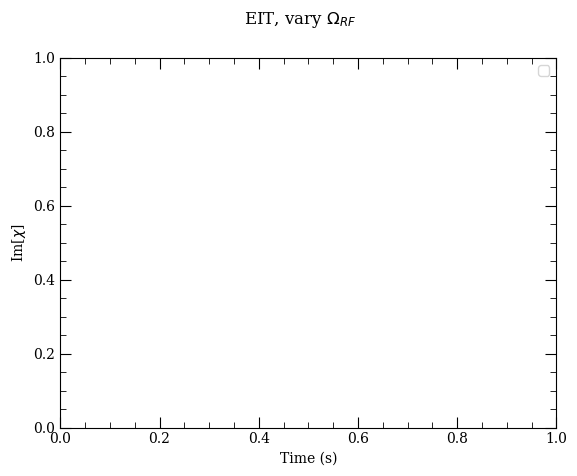

In [ ]:
psi0=basis(4,0)

pressure = pressure_Rb85(temperature)
N_0 = atomdensity(pressure, temperature)
dp = np.linspace(-100.e6, 100.e6, 201)
dc = np.linspace(-100.e6, 100.e6, 201)
dp = np.array([0])
# print(dp)
rabi12 = 0.3e6 
rabi23 = 30e6 
rabi34 = 20e6

delta12=0
delta23=0
delta34=0  
#delta12 = delta12 + 2*pi*v_list/lambda_trans[0]
#delta23_v = [dc + 2*pi*v/lambda_trans[1] for v in v_list] ;len(delta23_v)
#delta34 = delta34 - 2*pi*v_list/lambda_trans[2]
 
#duty_list = np.array([0.3,0.4,0.5,0.6,0.7,0.8])
Rabi12 = np.linspace(0, 50.e6, 6)
Rabi23 = np.linspace(0, 100.e6, 5)
Rabi34 = np.linspace(0, 20.e6, 5)

fig, ax = plt.subplots() 
res_v = []
for v in (v_list):
# for rabi23 in Rabi23:
# for rabi34 in Rabi34:
    Rabifreq = [rabi12,rabi23,rabi34]
    #print(Rabifreq) 
    delta12_p = delta12 + 2*pi*v/lambda_trans[0] 
    delta23_p = delta23 - 2*pi*v/lambda_trans[1]
    res = []
    for delta23 in tqdm(dc):
    # for delta23 in dc:          
        delta = [delta12_p,delta12_p+ delta23_p,delta12_p + delta23_p]
        H0 = 1/2*Qobj(Hdiag(delta) + Hoff(Rabifreq))  
        H1 = (rho[2][3].dag() + rho[2][3])
        H = [H0,[H1,H1_coeff]]  
        #print(rabi34)
        #print(H)
        # result = steadystate(H, c_op_list)
        result = mesolve(H, psi0, tlist, c_op_list,rho[0][1].dag(), args={'A': rabi34,'R' : 0.3})
        
        res.append(result.expect[0])
    # print(H)   
    # print(c_op_list)
    # print(rabi34)
    # print(res)
    # print(np.imag(res)) 
    res_v.append(res)

    #Efield = E_from_Rabi(rabi12,abs(dipmat12))
    # print()
    # chi = [susceptibility(N_0,np.abs(dipmat12),Efield,rho) for rho in res]

    # # print(np.imag(chi))
    # transmittance = [transmission(L,np.imag(i),lambda12) for i in chi]
    # refraction = np.real(chi)
    # absorption = 2*pi*np.imag(chi)/lambda12
    # print(np.imag(chi)[0])
    # # print(absorption)
    # # ax.plot(dp, res) 
    # # ax.plot(dp,res, label=omegaRF*1e-6)
    # # ax.plot(dp,transmission, label=rabi34*1e-6)
    # # ax.plot(dp,transmission, label=rabi12*1e-6)
    # # ax.plot(dp,transmittance, label=str(round(rabi12*1e-6,0))+'MHz')

    # # ax.plot(dp,refraction, label=rabi23*1e-6)
    #ax.plot(tlist,-1*np.imag(res[0][0]), label=str(round(rabi34*1e-6,0))+'MHz') # for rho[0][1]
    # ax.plot(tlist,np.real(res[0][0]), label=str(round(rabi12*1e-6,0))+'MHz') # for rho[0][0]
    #print(res)

    # ax.plot(times, result.expect[1]) 
ax.set_xlabel('Time (s)') 
ax.set_ylabel('Im[$\chi$]') 
# ax.legend(("Sigma-Z", "Sigma-Y"))  
ax.legend()
# plt.suptitle('EIT, vary $\Omega_{RF}$')
plt.suptitle('EIT, vary $\Omega_{RF}$')
#plt.ylim(-0.05,0.08)
plt.show()
#print(H) 
#print(Rabifreq)
#print(delta)
#print(res[0])

In [ ]:
for i in tqdm(range(len(res_v))): 
    df = pd.DataFrame(np.imag(res_v[i]))  
    df.to_csv("E:\EIT\EIT_qutip\EIT_doppler_time_depent\velocity"+str(v_list[i])+".csv", index=False)

  0%|          | 0/245 [00:00<?, ?it/s]


OSError: [Errno 22] Invalid argument: 'E:\\EIT\\EIT_qutip\\EIT_doppler_time_depent\x0belocity-121.0.csv'

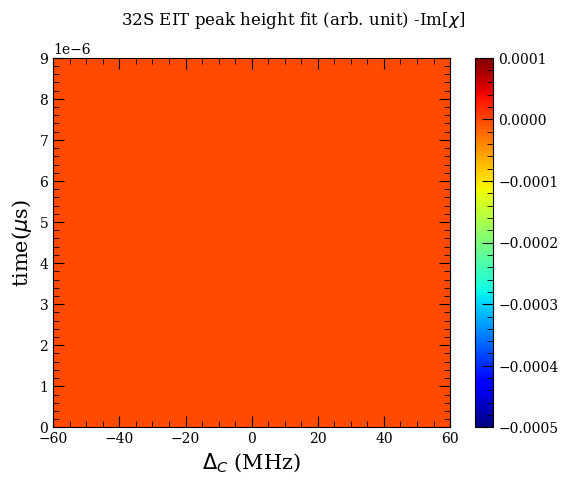

In [ ]:
plt.imshow(-1*np.imag(res_v[10]),vmin=-0.0005,origin='upper', extent=[-100,100,tlist[0],tlist[-1]], vmax=0.0001, cmap='jet', aspect='auto')  
font1 = {'family':'serif','color':'black','size':20}
font2 = {'family':'serif','color':'black','size':15}
plt.suptitle('32S EIT peak height fit (arb. unit) '+"-Im[$\chi$]", fontdict = font1)
plt.xlabel("$\Delta_C$"+" (MHz)", fontdict = font2) 
plt.xlim(-60,60)
plt.ylabel("time"+"($\mu$s)", fontdict = font2) 
#plt.ylim(3.8e-6,4.2e-6)
plt.colorbar()